In [1]:
import pandas as pd
!pip install seaborn
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.tree import plot_tree

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# original dataset
merged_df = pd.read_csv('merged_file.csv')

In [3]:
print(merged_df.shape)

(712616, 104)


MISSING VALUES IN DATASET

In [4]:
missing_values = merged_df.isna().sum()
print(missing_values.to_string())
print(merged_df.shape)

uuid_org                                   0
name_org                                   0
type_org                                   0
permalink_org                             11
cb_url_org                                11
rank_org                                   0
created_at_org                             0
updated_at_org                             0
legal_name                            285964
roles_org                                 67
domain_org                             11315
homepage_url                           11315
country_code                            2481
state_code                            316370
region                                  2481
city                                    2481
address                               167709
postal_code                           197677
status                                     0
short_description                          5
category_list                           6000
category_groups_list                    6000
num_fundin

UNIQUE VALUES IN DATASET

In [5]:
unique_values_dataset = merged_df.nunique()
print(unique_values_dataset.to_string())

uuid_org                              161190
name_org                              158674
type_org                                   1
permalink_org                         161188
cb_url_org                            161188
rank_org                              161190
created_at_org                        159798
updated_at_org                        129038
legal_name                             58266
roles_org                                 10
domain_org                            155160
homepage_url                          155699
country_code                             175
state_code                                63
region                                  1348
city                                   11453
address                               108000
postal_code                            31856
status                                     4
short_description                     161045
category_list                          91819
category_groups_list                   26060
num_fundin

Code cell below:
analyzes the empty values (NaN) in the merged_df data frame, especially in the column "raised_amount", and compares them with other columns. The goal is to find out which other columns in the same rows as raised_amount have empty values and count the number of these values.


In [6]:
# Column to compare
column_to_check = 'raised_amount'

# Get a mask (True/False) for missing values in the `raised_amount` column
na_mask = merged_df[column_to_check].isna()

# For all other columns, check where they have missing values in the same places
columns_with_matching_na = {}

for column in merged_df.columns:
    if column != column_to_check:
        matching_na = (merged_df[column].isna() & na_mask).sum()  # Number of matching NaNs
        if matching_na > 0:  # If matches exist
            columns_with_matching_na[column] = matching_na

# DataFrame for better readability
result_df = pd.DataFrame.from_dict(columns_with_matching_na, orient='index', columns=['Matching NaN Count'])

# Output
print("Number of matching missing values in other columns:")
print(result_df)


Počet shodných prázdných hodnot v jiných sloupcích:
                                    Matching NaN Count
permalink_org                                        2
cb_url_org                                           2
legal_name                                       78779
roles_org                                           26
domain_org                                        3470
...                                                ...
post_money_valuation_currency_code              141280
investor_count                                       1
org_uuid                                             1
org_name                                             1
lead_investor_uuids                              89666

[87 rows x 1 columns]


Deleting empty values by specific column and histogram of data before and after removal

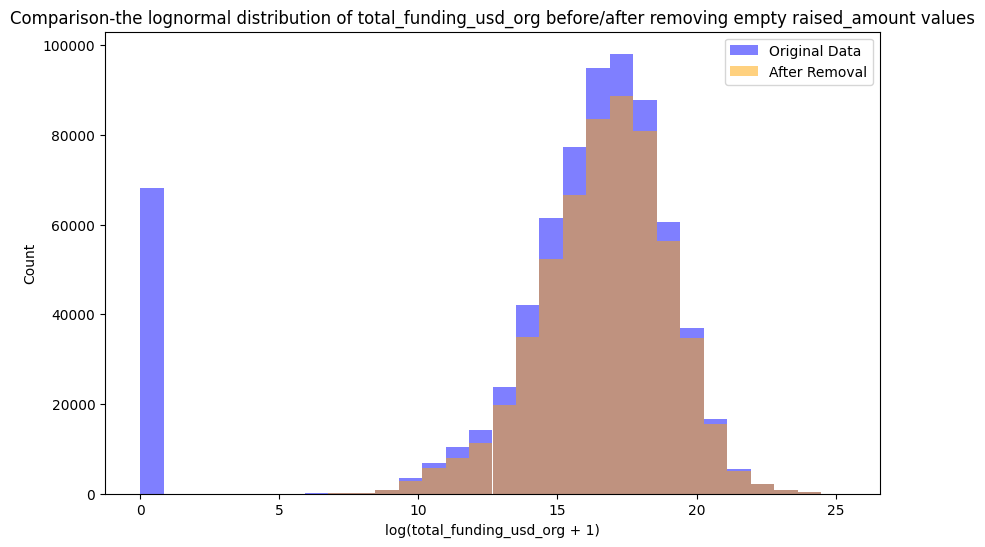

In [7]:
# Data before and after removing empty values in `raised_amount`
total_funding_original = merged_df['total_funding_usd_org'].dropna()
merged_df_cleaned = merged_df.dropna(subset=['raised_amount'])
total_funding_cleaned = merged_df_cleaned['total_funding_usd_org'].dropna()

# Logarithmic histogram for both data versions
plt.figure(figsize=(10, 6))
plt.hist(np.log1p(total_funding_original), bins=30, alpha=0.5, label='Original Data', color='blue')
plt.hist(np.log1p(total_funding_cleaned), bins=30, alpha=0.5, label='After Removal', color='orange')
plt.title("Comparison-the lognormal distribution of total_funding_usd_org before/after removing empty raised_amount values")
plt.xlabel("log(total_funding_usd_org + 1)")
plt.ylabel("Count")
plt.legend()
plt.savefig('histogram_po_raised.png')
plt.show()

In [8]:
merged_df = merged_df.dropna(subset=['raised_amount'])
print(merged_df.shape)

(569937, 104)


In [9]:
missing_values_after_raised_drop = merged_df.isna().sum()
print(missing_values_after_raised_drop.to_string())
print(merged_df.shape)

uuid_org                                   0
name_org                                   0
type_org                                   0
permalink_org                              9
cb_url_org                                 9
rank_org                                   0
created_at_org                             0
updated_at_org                             0
legal_name                            207185
roles_org                                 41
domain_org                              7845
homepage_url                            7845
country_code                            1242
state_code                            241019
region                                  1242
city                                    1242
address                               129111
postal_code                           150164
status                                     0
short_description                          1
category_list                           3699
category_groups_list                    3699
num_fundin

In [10]:
roles_unique= merged_df['roles_org'].unique()
roles_df = pd.DataFrame(roles_unique, columns=['roles_org'])


roles_df.to_excel('roles.xlsx', index=False)


DATA TRANSFORMATION
monitoring rest of missing values, which are still in data set and removing them+ transformation of values (aggregation, etc.)

In [11]:
# Replacing values containing only ";;" with "undifferentiated"
merged_df['is_lead_investor;;'] = merged_df['is_lead_investor;;'].replace(';;', 'undifferentiated')
merged_df['is_lead_investor;;'] = merged_df['is_lead_investor;;'].replace('True;;', 'True')
merged_df['is_lead_investor;;'] = merged_df['is_lead_investor;;'].replace('False;;', 'False')

# Result
print(merged_df['is_lead_investor;;'].unique)

<bound method Series.unique of 0                     True
1         undifferentiated
2         undifferentiated
3         undifferentiated
4         undifferentiated
                ...       
712610               False
712611                True
712612                True
712613               False
712614               False
Name: is_lead_investor;;, Length: 569937, dtype: object>


In [12]:
missing_values_after_filter = merged_df.isna().sum()
print(missing_values_after_filter.to_string())
print(merged_df.shape)

uuid_org                                   0
name_org                                   0
type_org                                   0
permalink_org                              9
cb_url_org                                 9
rank_org                                   0
created_at_org                             0
updated_at_org                             0
legal_name                            207185
roles_org                                 41
domain_org                              7845
homepage_url                            7845
country_code                            1242
state_code                            241019
region                                  1242
city                                    1242
address                               129111
postal_code                           150164
status                                     0
short_description                          1
category_list                           3699
category_groups_list                    3699
num_fundin

COLUMNS(ATRIBUTES) TRANSFORMATION

BUSINESS CATEGORIES

Frequency of occurrences of the word software in category_list

Using a regular expression and the str.contains() method for each row of a column and summing the results

In [13]:

word_count = merged_df['category_list'].str.contains(r'\bsoftware\b', case=False, na=False).sum()

# Printing results
print(word_count)

155247


In [14]:

word_count = merged_df['category_list'].str.contains(r'\b(?:software|technology)\b', case=False, na=False).sum()

# Printing results
print(word_count)

194287


In [15]:

word_count = merged_df['category_list'].str.contains(r'\b(?:software|machine learning)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

169172


In [16]:

word_count = merged_df['category_list'].str.contains(r'\b(?:software|artificial intelligence)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

177827


In [17]:



word_count = merged_df['category_list'].str.contains(r'\b(?:software|artificial intelligence|machine learning|technology|biotechnology)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

265843


In [18]:

word_count = merged_df['category_list'].str.contains(r'\b(?:health|medicine)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

83146


In [19]:

word_count = merged_df['category_list'].str.contains(r'\b(?:health|medicine|software)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

230270


In [20]:

word_count = merged_df['category_list'].str.contains(r'\b(?=.*health)(?=.*machine learning)\b', case=False, na=False).sum()

# Printing the results
print(word_count)

2677


Calculations for category_group_list

In [21]:

word_count = merged_df['category_groups_list'].str.contains(r'\b(?:software|artificial intelligence|machine learning|Data and Analytics|Information Technology)\b', case=False, na=False).sum()

# Print
print(word_count)

308564


In [22]:


word_count = merged_df['category_groups_list'].str.contains(r'\b(?:Hardware|Technology|Biotechnology)\b', case=False, na=False).sum()

# Print
print(word_count)


241897


In [23]:


word_count = merged_df['category_groups_list'].str.contains(r'\b(?:medicine|health|healthcare)\b', case=False, na=False).sum()

# Print
print(word_count)


108574


In [24]:

word_count = merged_df['category_groups_list'].str.contains(r'\b(?=.*software)(?:medicine|health|healthcare)\b', case=False, na=False).sum()

# Print
print(word_count)

23649


In [25]:

word_count = merged_df['category_groups_list'].str.contains(r'\b(?:Lending and Investments|Financial Services|Payments)\b', case=False, na=False).sum()

# Print
print(word_count)

78558


In [26]:

word_count = merged_df['category_groups_list'].str.contains(r'\b(?:Education)\b', case=False, na=False).sum()

# Print
print(word_count)

26162


In [27]:
# Settings to display all columns
pd.set_option('display.max_columns', None)

# number of unique values for the 'category_list' column
unique_counts = merged_df['category_list'].nunique()

# Print the results
print(unique_counts)


71805


In [28]:
# List of columns to remove
columns_to_drop = ['permalink_org', 'cb_url_org', 'legal_name', 'domain_org', 'homepage_url',
                   'address', 'postal_code', 'short_description', 'email', 'phone',
                   'logo_url_org', 'alias1', 'alias2', 'alias3', 'domain_all',
                   'lead_investor_uuids', 'permalink_x', 'cb_url_x', 'rank_x']

# Remove selected columns
df_dropped_columns = merged_df.drop(columns=columns_to_drop)

# Display the shape of the DataFrame after dropping columns
print(df_dropped_columns.shape)


(569937, 85)


In [29]:
# List of columns to remove
columns_to_drop = ['post_money_valuation', 'post_money_valuation_usd', 'post_money_valuation_currency_code',
                   'org_uuid', 'created_at_all', 'updated_at_all', 'logo_url_all', 'closed_on_all',
                   'cb_url_all', 'permalink_all', 'uuid_all', 'created_at_y', 'updated_at_y',
                   'cb_url_y', 'permalink_y', 'name_y', 'uuid_y', 'investor_uuid', 'funding_round_uuid',
                   'created_at_x', 'updated_at_x', 'name_x', 'uuid_x', 'num_exits',
                   'closed_on_org', 'updated_at_org', 'created_at_org']

# Remove selected columns
df_dropped_columns = merged_df.drop(columns=columns_to_drop)

# Remove missing values in specified columns
all_clean = df_dropped_columns.dropna(subset=[
    'founded_on_org', 'founded_on_all', 'roles_org', 'state_code', 'country_code_y',
    'founded_on_all', 'investor_types', 'city_x', 'state_code_x', 'roles_org',
    'category_list', 'city'
])

print(all_clean.shape)


(212496, 77)


In [30]:
# List of columns to remove
columns_to_drop_1 = ['lead_investor_uuids', 'rank_all', 'cb_url_x', 'permalink_x', 'short_description',
                     'domain_all', 'rank_x', 'alias1', 'alias2', 'alias3', 'logo_url_org', 'phone',
                     'email', 'postal_code', 'address', 'legal_name', 'domain_org', 'homepage_url',
                     'cb_url_org', 'permalink_org']

# Remove selected columns
cleaned_df = all_clean.drop(columns=columns_to_drop_1)

print(cleaned_df.shape)


(212496, 57)


In [31]:
# a new column that contains the count of non-null social media links per row
cleaned_df['Presence_on_social_media_organization'] = (
    cleaned_df['facebook_url_org'].notnull().astype(int) +
    cleaned_df['linkedin_url_org'].notnull().astype(int) +
    cleaned_df['twitter_url_org'].notnull().astype(int)
)

# the results
print(cleaned_df[['facebook_url_org', 'linkedin_url_org', 'twitter_url_org', 'Presence_on_social_media_organization']].head())


                    facebook_url_org linkedin_url_org  \
0  https://www.facebook.com/Wetpaint              NaN   
1  https://www.facebook.com/Wetpaint              NaN   
3  https://www.facebook.com/Wetpaint              NaN   
4  https://www.facebook.com/Wetpaint              NaN   
5  https://www.facebook.com/Wetpaint              NaN   

                  twitter_url_org  Presence_on_social_media_organization  
0  https://twitter.com/wetpainttv                                      2  
1  https://twitter.com/wetpainttv                                      2  
3  https://twitter.com/wetpainttv                                      2  
4  https://twitter.com/wetpainttv                                      2  
5  https://twitter.com/wetpainttv                                      2  


In [32]:
# A new column that contains the count of non-null social media links per row
cleaned_df['Presence_on_social_media_investors'] = (
    cleaned_df['facebook_url_all'].notnull().astype(int) +
    cleaned_df['linkedin_url_all'].notnull().astype(int) +
    cleaned_df['twitter_url_all'].notnull().astype(int)
)

# Check the results
print(cleaned_df[['facebook_url_all', 'linkedin_url_all', 'twitter_url_all', 'Presence_on_social_media_investors']].head())

                                    facebook_url_all  \
0                                                NaN   
1  http://www.facebook.com/pages/Menlo-Park-CA/Tr...   
3                                                NaN   
4  http://www.facebook.com/pages/Menlo-Park-CA/Tr...   
5                                                NaN   

                                   linkedin_url_all  \
0         https://www.linkedin.com/company/accel-vc   
1  http://www.linkedin.com/company/trinity-ventures   
3         https://www.linkedin.com/company/accel-vc   
4  http://www.linkedin.com/company/trinity-ventures   
5    https://www.linkedin.com/company/dag-ventures/   

                      twitter_url_all  Presence_on_social_media_investors  
0            http://twitter.com/accel                                   2  
1  http://twitter.com/trinityventures                                   3  
3            http://twitter.com/accel                                   2  
4  http://twitter.com/trinit

In [33]:
#Drop columns
columns_to_drop_2 = ['facebook_url_all', 'linkedin_url_all', 'twitter_url_all','facebook_url_org', 'linkedin_url_org', 'twitter_url_org','category_list']


final_df = cleaned_df.drop(columns=columns_to_drop_2)
print(final_df.shape)


(212496, 52)


In [34]:
# Check the columns
sloupce = final_df.columns.tolist()

print(sloupce)


['uuid_org', 'name_org', 'type_org', 'rank_org', 'roles_org', 'country_code', 'state_code', 'region', 'city', 'status', 'category_groups_list', 'num_funding_rounds', 'total_funding_usd_org', 'total_funding_org', 'total_funding_currency_code_org', 'founded_on_org', 'last_funding_on', 'employee_count', 'primary_role', 'type_x', 'funding_round_name', 'investor_name', 'investor_type', 'is_lead_investor;;', 'type_y', 'rank_y', 'roles_all', 'country_code_x', 'state_code_x', 'region_x', 'city_x', 'investor_types', 'investment_count', 'total_funding_usd_all', 'total_funding_all', 'total_funding_currency_code_all', 'founded_on_all', 'name_all', 'type_all', 'country_code_y', 'state_code_y', 'region_y', 'city_y', 'investment_type', 'announced_on', 'raised_amount_usd', 'raised_amount', 'raised_amount_currency_code', 'investor_count', 'org_name', 'Presence_on_social_media_organization', 'Presence_on_social_media_investors']


        Investment Type  Fraction
0                  seed  0.294124
1              series_a  0.285832
2              series_b  0.230430
3              series_c  0.143454
4              pre_seed  0.036472
5                 angel  0.008445
6   equity_crowdfunding  0.001196
7  product_crowdfunding  0.000047
0.2640660283505019


/tmp/ipykernel_2002291/394944830.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=fractions.index, x=fractions.values, palette="viridis")


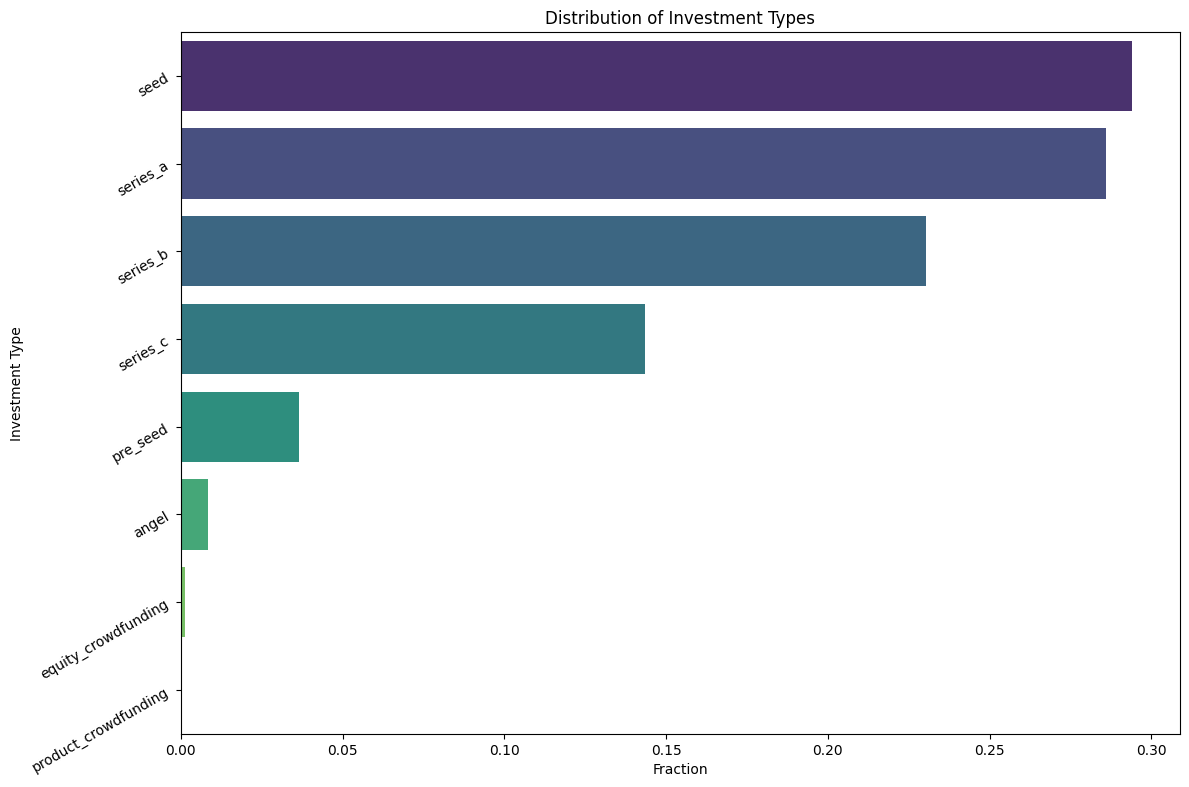

In [35]:
# Filter the data
filtered_data = final_df[final_df['investment_type'].isin([
    'pre_seed', 'seed', 'series_a', 'series_b', 'series_c',
    'angel', 'equity_crowdfunding', 'product_crowdfunding'
])]

# Count occurrences of investment round types in the filtered data
counts_filtered = filtered_data['investment_type'].value_counts()

# Count the total number of filtered investments
total_filtered = counts_filtered.sum()

# Calculate fractions for the filtered data
fractions = counts_filtered / total_filtered
counts_of_investments_types = merged_df['investment_type'].count()
fraction_to_all_investments = total_filtered / counts_of_investments_types

# Create and display the table
table = pd.DataFrame({
    'Investment Type': fractions.index,
    'Fraction': fractions.values
})
print(table)
print(fraction_to_all_investments)
table.to_excel("fractions.xlsx")

# Check if filtered_data is not empty
if not filtered_data.empty:
    
    
    # Bar plot
    plt.figure(figsize=(12, 8)) 
    sns.barplot(y=fractions.index, x=fractions.values, palette="viridis")
    plt.xlabel('Fraction')
    plt.ylabel('Investment Type')
    plt.title('Distribution of Investment Types')

    # labels on the y-axis for better readability
    plt.yticks(rotation=30, ha='right')

    plt.tight_layout()  
    plt.savefig('funding_types_rotated.png')
    plt.show()
else:
    print("No data to display. Check the filtering and category names.")


Adjustment of columns suffixes-due to merging different dataset together

In [36]:
# Column lists for different types of suffixes I want to update
columns_to_change_s_org = [
    'uuid_org', 'name_org', 'roles_org', 'type_org', 'rank_org',
    'total_funding_usd_org', 'total_funding_org', 
    'total_funding_currency_code_org', 'founded_on_org'
]

columns_to_change_bez_org = [
    'country_code', 'state_code', 'region', 'city', 'status', 
    'category_list', 'category_groups_list', 'num_funding_rounds',
    'employee_count', 'last_funding_on', 'primary_role'
]

columns_to_change_x_investors = [
    'type_x', 'country_code_x', 'state_code_x', 'region_x', 'city_x'
]

columns_to_change_all_investors = [
    'total_funding_usd_all', 'total_funding_all', 'total_funding_currency_code_all',
    'founded_on_all', 'name_all', 'type_all', 'rank_all', 'roles_all'
]

columns_to_change_bez_investors = [
    'investor_types', 'investment_count', 'investor_name'
]

columns_to_change_y_funding = [
    'investment_amount_y', 'investment_rounds_y', 'investor_count_y', 'type_y',
    'country_code_y', 'state_code_y', 'region_y', 'city_y'
]

columns_to_change_bez_funding = [
    'investment_amount', 'investment_rounds', 'investor_count',
    'announced_on', 'raised_amount_usd', 'raised_amount', 'raised_amount_currency_code'
]

# Suffixes to add or replace
new_suffix_org = '_organization'
new_suffix_investors = '_investors'
new_suffix_funding = '_funding'

# Replace the suffix for organization columns
for col in columns_to_change_s_org:
    filtered_data.rename(columns={col: col.replace('_org', new_suffix_org)}, inplace=True)

# Add the '_organization' suffix for columns without a suffix
for col in columns_to_change_bez_org:
    filtered_data.rename(columns={col: f'{col}{new_suffix_org}'}, inplace=True)

# Replace suffixes for investor columns
for col in columns_to_change_x_investors + columns_to_change_all_investors:
    if col.endswith('_x'):
        filtered_data.rename(columns={col: col.replace('_x', new_suffix_investors)}, inplace=True)
    elif col.endswith('_all'):
        filtered_data.rename(columns={col: col.replace('_all', new_suffix_investors)}, inplace=True)

# Add the '_investors' suffix for columns without a suffix
for col in columns_to_change_bez_investors:
    filtered_data.rename(columns={col: f'{col}{new_suffix_investors}'}, inplace=True)

# Replace suffixes for funding columns
for col in columns_to_change_y_funding:
    filtered_data.rename(columns={col: col.replace('_y', new_suffix_funding)}, inplace=True)

# Add the '_funding' suffix for columns without a suffix
for col in columns_to_change_bez_funding:
    filtered_data.rename(columns={col: f'{col}{new_suffix_funding}'}, inplace=True)


/tmp/ipykernel_2002291/4257698248.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.rename(columns={col: col.replace('_org', new_suffix_org)}, inplace=True)
/tmp/ipykernel_2002291/4257698248.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.rename(columns={col: f'{col}{new_suffix_org}'}, inplace=True)
/tmp/ipykernel_2002291/4257698248.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.r

In [37]:
#Type of companies in filtered_data
unique_types_org = filtered_data['type_organization'].value_counts()
print(unique_types_org)
unique_types_rolesorg = filtered_data['roles_organization'].value_counts()
print(unique_types_rolesorg)

type_organization
organization    150501
Name: count, dtype: int64
roles_organization
company                    143168
investor,company             7128
investor,company,school        74
investor                       44
company,investor               37
company,school                 23
school                         23
investor,school                 4
Name: count, dtype: int64


In [38]:
# How many companies are defined as 'companies-only'?
soubor_filtr_companies = filtered_data[filtered_data['roles_organization'].isin(['company'])]
print(soubor_filtr_companies.shape)
unique_companies= soubor_filtr_companies['roles_organization'].value_counts()
print(unique_companies)


(143168, 52)
roles_organization
company    143168
Name: count, dtype: int64


In [40]:
# Convert 'founded_on_organization' column to datetime, convert errors to NaT
# and if the date format is not standard and pandas cannot automatically recognize it, specify the format using the 'format' parameter
soubor_filtr_companies['founded_on_organization'] = pd.to_datetime(soubor_filtr_companies['founded_on_organization'], errors='coerce', format='%Y-%m-%d')







/tmp/ipykernel_2002291/1304563182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soubor_filtr_companies['founded_on_organization'] = pd.to_datetime(soubor_filtr_companies['founded_on_organization'], errors='coerce', format='%Y-%m-%d')


In [41]:


datove_typy_vsech_sloupcu = soubor_filtr_companies.dtypes.reset_index()
datove_typy_vsech_sloupcu.columns = ['Column', 'Data Type']

print(datove_typy_vsech_sloupcu)

                                     Sloupec       DatovýTyp
0                          uuid_organization          object
1                          name_organization          object
2                          type_organization          object
3                          rank_organization         float64
4                         roles_organization          object
5                  country_code_organization          object
6                    state_code_organization          object
7                        region_organization          object
8                          city_organization          object
9                        status_organization          object
10         category_groups_list_organization          object
11           num_funding_rounds_organization         float64
12            total_funding_usd_organization         float64
13                total_funding_organization         float64
14  total_funding_currency_code_organization          object
15                   fou

/tmp/ipykernel_2002291/2688346708.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soubor_filtr_companies['intervals'] = intervals


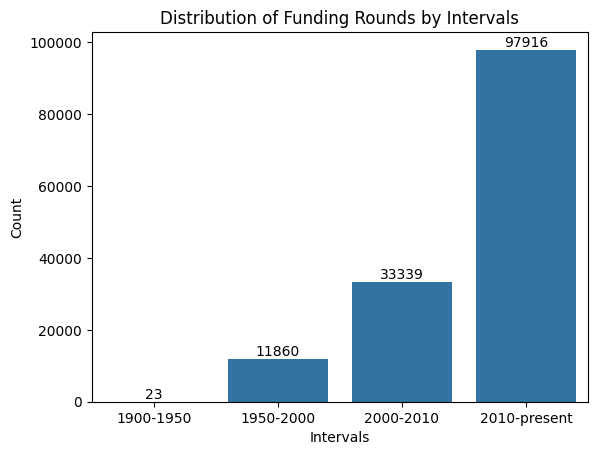

In [42]:
# Create intervals based on 'founded_on' column
current_year = pd.to_datetime('today').year
intervals = pd.cut(soubor_filtr_companies['founded_on_organization'].dt.year, bins=[1900, 1950, 2000, 2010, current_year], labels=['1900-1950', '1950-2000', '2000-2010','2010-present'])

# Adding the intervals column to the dataframe
soubor_filtr_companies['intervals'] = intervals

# Calculate the count of funding rounds in each interval
counts = soubor_filtr_companies['intervals'].value_counts()

# Bar plot using Seaborn
ax = sns.barplot(x=counts.index, y=counts.values)

# Adding numeric labels above columns
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), 
            ha='center', va='bottom', fontsize=10)
    
# Axis labels and title
plt.xlabel('Intervals')
plt.ylabel('Count')
plt.title('Distribution of Funding Rounds by Intervals')

# The final plot
plt.show()

In [43]:
missing_after_intervals=soubor_filtr_companies.isna().sum()
print(missing_after_intervals)
soubor_filtr_companies.to_csv("data_pred_filtraci.csv")

uuid_organization                                0
name_organization                                0
type_organization                                0
rank_organization                                0
roles_organization                               0
country_code_organization                        0
state_code_organization                          0
region_organization                              0
city_organization                                0
status_organization                              0
category_groups_list_organization                0
num_funding_rounds_organization                  0
total_funding_usd_organization                   0
total_funding_organization                       0
total_funding_currency_code_organization         0
founded_on_organization                          0
last_funding_on_organization                     0
employee_count_organization                      0
primary_role_organization                        0
type_investors                 

podívat se na ten kod, co ten soupec founded_on, co ta studie italská? degrees a jobs?

In [44]:
print(soubor_filtr_companies['investment_type'].head(5))

0    series_b
1    series_b
3    series_c
4    series_c
5    series_c
Name: investment_type, dtype: object


/tmp/ipykernel_2002291/919152273.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


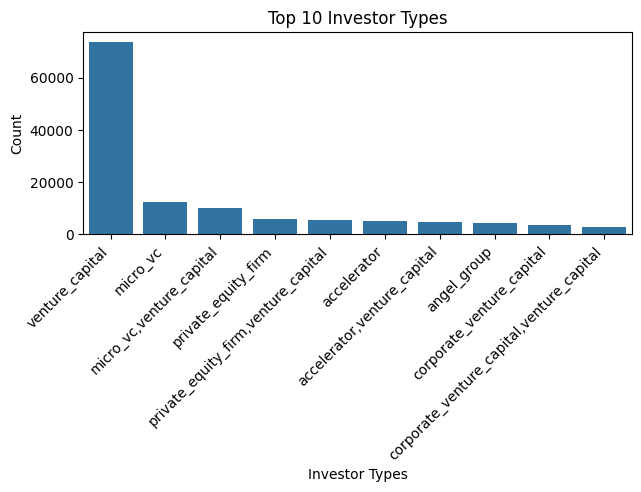

In [45]:
# Investor types
counts = soubor_filtr_companies['investor_types_investors'].value_counts().nlargest(10)
ax = sns.barplot(x=counts.index, y=counts.values)

# Rotation of the x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Displa the plot
plt.tight_layout()  # Improves layout to fit labels

# Set the axis labels and title
plt.xlabel('Investor Types')
plt.ylabel('Count')
plt.title('Top 10 Investor Types')
plt.show()


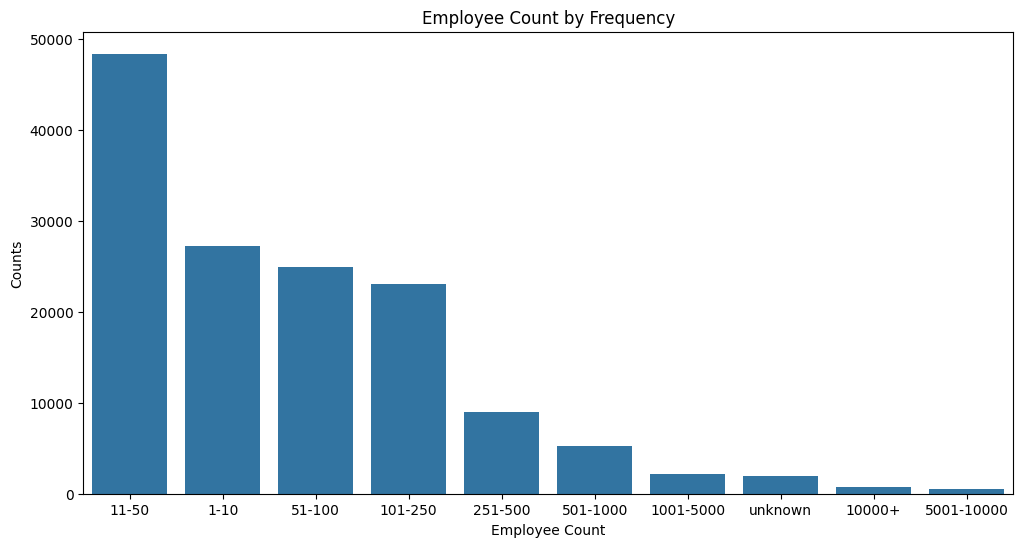

In [46]:
# Counting occurrences for each category in the 'employee_count' column
employee_counts = soubor_filtr_companies['employee_count_organization'].value_counts()

# Sorting the values from highest to lowest
sorted_employee_counts = employee_counts.sort_values(ascending=False)

# Create a bar plot for 'employee_count' sorted by frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_employee_counts.index, y=sorted_employee_counts.values)

# axis labels and title
plt.xlabel('Employee Count')
plt.ylabel('Counts')
plt.title('Employee Count by Frequency')

# the plot
plt.show()


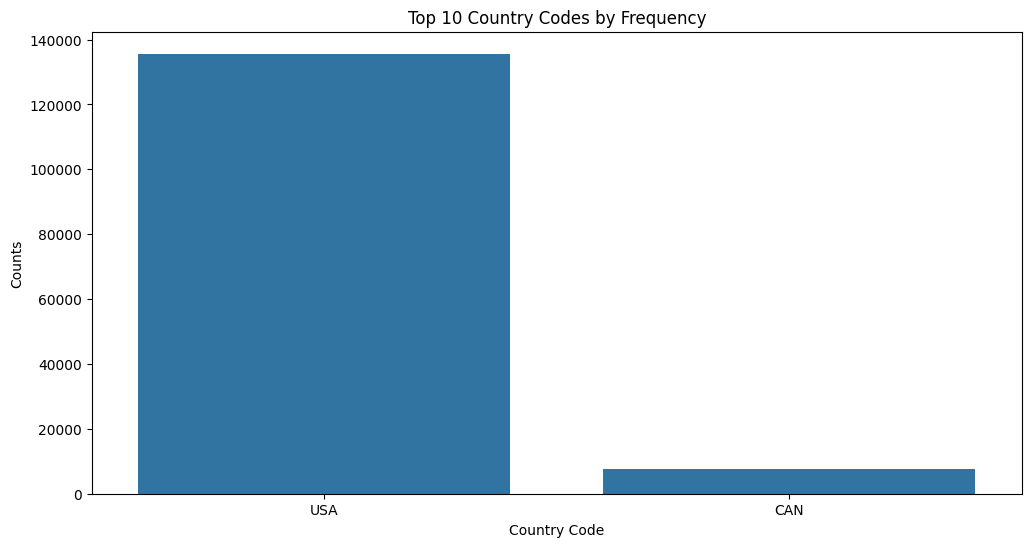

In [47]:
# COUNTRIES WHERE STARTUPS ARE LOCATED
# Counting the number of startups per country
country_counts = soubor_filtr_companies['country_code_organization'].value_counts()

# Select the top 10 countries
top_countries = country_counts.head(10)

# Create a bar plot for the top 10 countries
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values)

# axis labels and title
plt.xlabel('Country Code')
plt.ylabel('Counts')
plt.title('Top 10 Country Codes by Frequency')

# the plot
plt.show()


/tmp/ipykernel_2002291/726480333.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soubor_filtr_companies['total_funding_usd_organization'] = pd.to_numeric(soubor_filtr_companies['total_funding_usd_organization'], errors='coerce')
/tmp/ipykernel_2002291/726480333.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soubor_filtr_companies.dropna(subset=['total_funding_usd_organization'], inplace=True)
/tmp/ipykernel_2002291/726480333.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

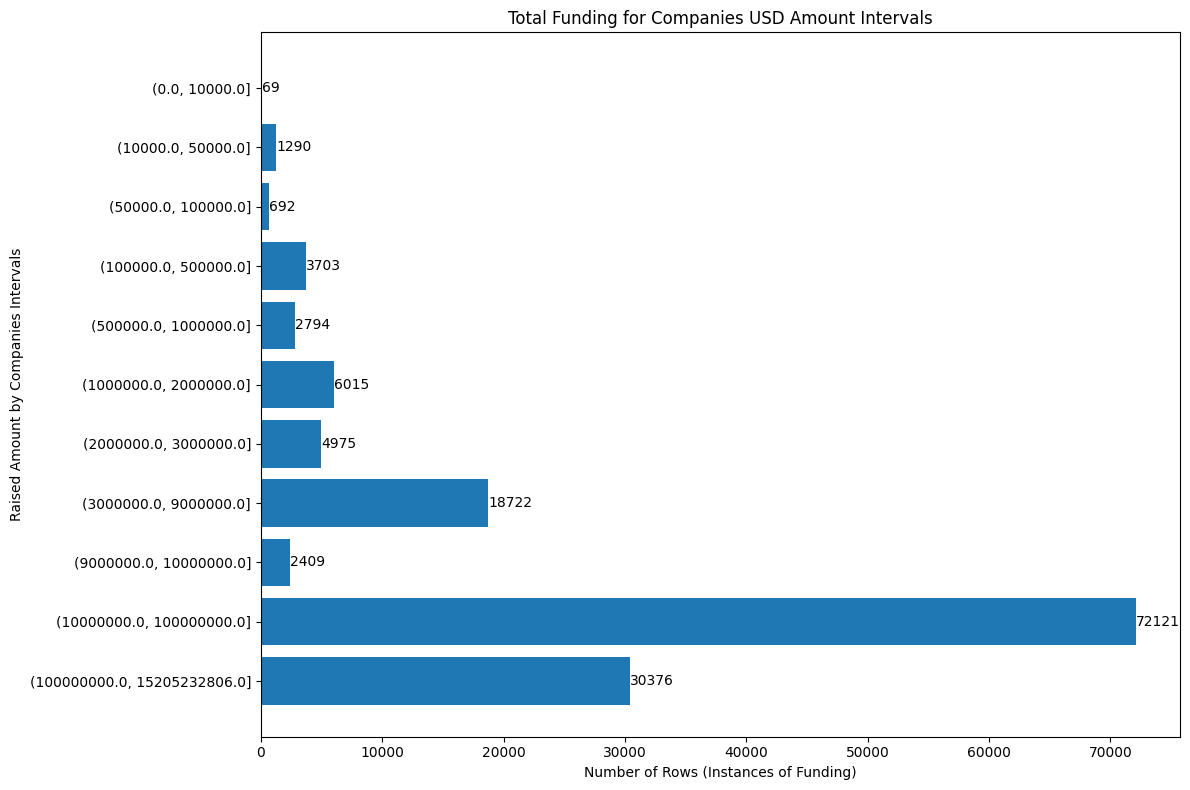

In [48]:
# TOTAL AMOUNT OF MONEY RAISED BY STARTUPS

# Ensuring that 'raised_amount' is a numeric type
soubor_filtr_companies['total_funding_usd_organization'] = pd.to_numeric(soubor_filtr_companies['total_funding_usd_organization'], errors='coerce')

# Dropping any rows that may have NaN values after coercing to numeric
soubor_filtr_companies.dropna(subset=['total_funding_usd_organization'], inplace=True)

# Defining the custom bins for the intervals I will use
bins = [0, 10000, 50000, 100000, 500000, 1000000, 2000000,3000000,9000000,10000000,100000000, soubor_filtr_companies['total_funding_usd_organization'].max()]

# Creating a new column 'amount_interval' with the interval each 'raised_amount' belongs to
soubor_filtr_companies['amount_interval_firmy'] = pd.cut(soubor_filtr_companies['total_funding_usd_organization'], bins=bins)

# Group by the new 'amount_interval' column and count the number of rows in each interval
grouped_intervals = soubor_filtr_companies.groupby('amount_interval_firmy').size().reset_index(name='number_of_rows')

# Plotting
plt.figure(figsize=(12, 8))
bars = plt.barh(grouped_intervals['amount_interval_firmy'].astype(str), grouped_intervals['number_of_rows'])

# Add labels on the bars to show the exact values
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
             f'{int(bar.get_width())}',
             va='center', ha='left')

plt.xlabel('Number of Rows (Instances of Funding)')
plt.ylabel('Raised Amount by Companies Intervals')
plt.title('Total Funding for Companies USD Amount Intervals')
plt.gca().invert_yaxis() #Inverting y_axis!
plt.tight_layout()  
plt.show()

print(soubor_filtr_companies.shape)
soubor_filtr_companies.drop(['investor_name_investors'], axis=1, inplace = True)
print(soubor_filtr_companies.shape)

In [49]:
# Setting the condition(companies founded in 1960 and onwards )
specific_date = pd.to_datetime('1960-01-01')

# Filter the DataFrame based on the condition in the 'founded_on_organization' column
mach_df = soubor_filtr_companies[soubor_filtr_companies['founded_on_organization'] > specific_date]

# Count the number of rows that meet the condition
row_count = mach_df.shape[0]
print(row_count)


143081


In [50]:
column_types = mach_df.dtypes

# Find columns that are of type datetime64
datetime_columns = column_types[column_types == 'datetime64[ns]'].index.tolist()

# Print the names of the columns that are datetime
print("Datetime columns:")
print(datetime_columns)

column_types_1 = mach_df['last_funding_on_organization'].dtypes
print(column_types_1)


Sloupce datetime:
['founded_on_organization']
object


In [51]:
mach_df = mach_df.drop(['intervals'], axis=1)

In [52]:
mach_df=mach_df.drop(['amount_interval_firmy','raised_amount_usd_funding','raised_amount_currency_code_funding', 'total_funding_organization','raised_amount_funding','total_funding_currency_code_investors','total_funding_currency_code_organization','total_funding_investors'],axis=1)

In [53]:
mach_df=mach_df.drop(['name_investors','org_name','uuid_organization','status_organization'],axis=1)


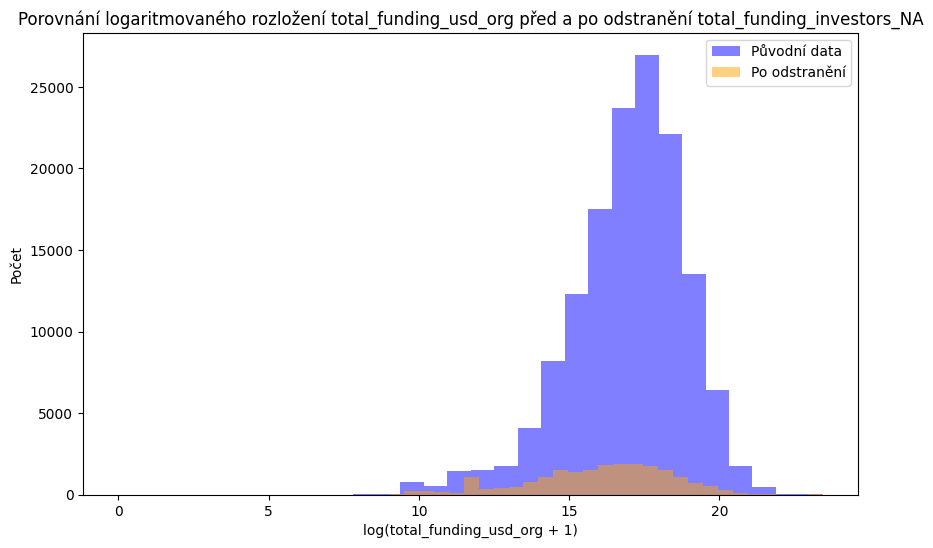

In [54]:
# Data before and after removing missing values in `total_funding_usd_investors`
total_funding_original = mach_df['total_funding_usd_organization'].dropna()
mach_df_cleaned = mach_df.dropna(subset=['total_funding_usd_investors'])
total_funding_cleaned = mach_df_cleaned['total_funding_usd_organization'].dropna()

# Logarithmic histogram for both versions of the data
plt.figure(figsize=(10, 6))
plt.hist(np.log1p(total_funding_original), bins=30, alpha=0.5, label='Original data', color='blue')
plt.hist(np.log1p(total_funding_cleaned), bins=30, alpha=0.5, label='After removal', color='orange')
plt.title("Comparison of log-transformed distribution of total_funding_usd_org before and after removing NA in total_funding_investors")
plt.xlabel("log(total_funding_usd_org + 1)")
plt.ylabel("Count")
plt.legend()
plt.savefig('histogram_after_investors_funding.png')
plt.show()


In [55]:
mach_df = mach_df.dropna(subset=['total_funding_usd_investors'])


In [56]:
missing_values_after_investors_drop = mach_df.isna().sum()
print(missing_values_after_investors_drop.to_string())
print(merged_df.shape)

name_organization                        0
type_organization                        0
rank_organization                        0
roles_organization                       0
country_code_organization                0
state_code_organization                  0
region_organization                      0
city_organization                        0
category_groups_list_organization        0
num_funding_rounds_organization          0
total_funding_usd_organization           0
founded_on_organization                  0
last_funding_on_organization             0
employee_count_organization              0
primary_role_organization                0
type_investors                           0
funding_round_name                       0
investor_name_investors                  0
investor_type                            0
is_lead_investor;;                       0
type_funding                             0
rank_y                                   0
roles_investors                          0
country_cod

In [57]:
# Count occurrences of at least one of the specified words in the 'category_list' column
word_count = mach_df['category_groups_list_organization'].str.contains(
    r'\b(?:software|artificial intelligence|machine learning|Data and Analytics|Information Technology|Internet Services|Hardware)\b',
    case=False, na=False).sum()

# Print the result
print(word_count)


14682


EDITING COLUMN VALUES + CHARTS AND FIGURES

TECH/NON_TECH

In [58]:
# Creating a new column "type_of_industry_organization" with default value None
mach_df['type_of_industry_organization'] = None

# Defining the condition
condition = mach_df['category_groups_list_organization'].str.contains(
    r'\b(?:software|artificial intelligence|machine learning|Data and Analytics|Information Technology|Internet Services|Hardware)\b',
    case=False, na=False)

# Setting the value "Technology" for rows that meet the condition
mach_df.loc[condition, 'type_of_industry_organization'] = 'Technology'

# Setting the value "Non-Technology" for rows that do not meet the condition
mach_df.loc[~condition, 'type_of_industry_organization'] = 'Non-Technology'

# Print the modified DataFrame columns
columns = mach_df.columns.tolist()
print(columns)


['name_organization', 'type_organization', 'rank_organization', 'roles_organization', 'country_code_organization', 'state_code_organization', 'region_organization', 'city_organization', 'category_groups_list_organization', 'num_funding_rounds_organization', 'total_funding_usd_organization', 'founded_on_organization', 'last_funding_on_organization', 'employee_count_organization', 'primary_role_organization', 'type_investors', 'funding_round_name', 'investor_name_investors', 'investor_type', 'is_lead_investor;;', 'type_funding', 'rank_y', 'roles_investors', 'country_code_investors', 'state_code_investors', 'region_investors', 'city_investors', 'investor_types_investors', 'investment_count_investors', 'total_funding_usd_investors', 'founded_on_investors', 'type_investors', 'country_code_funding', 'state_code_funding', 'region_funding', 'city_funding', 'investment_type', 'announced_on_funding', 'investor_count_funding', 'Presence_on_social_media_organization', 'Presence_on_social_media_inv

In [59]:
mach_df=mach_df.drop(['category_groups_list_organization',],axis=1)

In [60]:
missing=mach_df.isna().sum()
print(missing.to_string())

name_organization                        0
type_organization                        0
rank_organization                        0
roles_organization                       0
country_code_organization                0
state_code_organization                  0
region_organization                      0
city_organization                        0
num_funding_rounds_organization          0
total_funding_usd_organization           0
founded_on_organization                  0
last_funding_on_organization             0
employee_count_organization              0
primary_role_organization                0
type_investors                           0
funding_round_name                       0
investor_name_investors                  0
investor_type                            0
is_lead_investor;;                       0
type_funding                             0
rank_y                                   0
roles_investors                          0
country_code_investors                   0
state_code_

In [61]:
# All dataframe columns
print(mach_df.columns)

Index(['name_organization', 'type_organization', 'rank_organization',
       'roles_organization', 'country_code_organization',
       'state_code_organization', 'region_organization', 'city_organization',
       'num_funding_rounds_organization', 'total_funding_usd_organization',
       'founded_on_organization', 'last_funding_on_organization',
       'employee_count_organization', 'primary_role_organization',
       'type_investors', 'funding_round_name', 'investor_name_investors',
       'investor_type', 'is_lead_investor;;', 'type_funding', 'rank_y',
       'roles_investors', 'country_code_investors', 'state_code_investors',
       'region_investors', 'city_investors', 'investor_types_investors',
       'investment_count_investors', 'total_funding_usd_investors',
       'founded_on_investors', 'type_investors', 'country_code_funding',
       'state_code_funding', 'region_funding', 'city_funding',
       'investment_type', 'announced_on_funding', 'investor_count_funding',
       'Pr

In [62]:
unique_values_dataset = mach_df.nunique()
print(unique_values_dataset.to_string())

name_organization                        12043
type_organization                            1
rank_organization                        12196
roles_organization                           1
country_code_organization                    2
state_code_organization                     61
region_organization                         61
city_organization                          918
num_funding_rounds_organization             25
total_funding_usd_organization            6278
founded_on_organization                   1732
last_funding_on_organization              3743
employee_count_organization                 10
primary_role_organization                    1
type_investors                               1
funding_round_name                       15726
investor_name_investors                    735
investor_type                                1
is_lead_investor;;                           3
type_funding                                 1
rank_y                                     735
roles_investo

In [63]:
mach_df=mach_df.drop(['rank_organization','rank_y','rank_investors'], axis=1, errors='ignore')

In [64]:
print(mach_df.columns)

Index(['name_organization', 'type_organization', 'roles_organization',
       'country_code_organization', 'state_code_organization',
       'region_organization', 'city_organization',
       'num_funding_rounds_organization', 'total_funding_usd_organization',
       'founded_on_organization', 'last_funding_on_organization',
       'employee_count_organization', 'primary_role_organization',
       'type_investors', 'funding_round_name', 'investor_name_investors',
       'investor_type', 'is_lead_investor;;', 'type_funding',
       'roles_investors', 'country_code_investors', 'state_code_investors',
       'region_investors', 'city_investors', 'investor_types_investors',
       'investment_count_investors', 'total_funding_usd_investors',
       'founded_on_investors', 'type_investors', 'country_code_funding',
       'state_code_funding', 'region_funding', 'city_funding',
       'investment_type', 'announced_on_funding', 'investor_count_funding',
       'Presence_on_social_media_organiza

In [65]:
# The lists of unique values in listed columns
for column in ['investor_type', 'type_organization','type_funding']:
    print(f"Unikátní hodnoty ve sloupci {column}:")
    print(mach_df[column].unique())
    print()  # Blank line-between outputs for better readability


Unikátní hodnoty ve sloupci investor_type:
['organization']

Unikátní hodnoty ve sloupci type_organization:
['organization']

Unikátní hodnoty ve sloupci type_funding:
['organization']



In [66]:
# Statistical summary of numerical variables
summary_numeric = mach_df.describe()

# Statistical summary of categorical variables
summary_categorical = mach_df.describe(include=['object', 'category'])

# Output of the basic statistical overview
print("Numerical variables:\n", summary_numeric)
print("\nCategorical variables:\n", summary_categorical)


Numerické proměnné:
        num_funding_rounds_organization  total_funding_usd_organization  \
count                     20748.000000                    2.074800e+04   
mean                          4.582080                    6.422012e+07   
min                           1.000000                    4.907000e+03   
25%                           3.000000                    2.185000e+06   
50%                           4.000000                    1.200000e+07   
75%                           6.000000                    4.810000e+07   
max                          26.000000                    1.520523e+10   
std                           2.824464                    3.493382e+08   

             founded_on_organization  investment_count_investors  \
count                          20748                20748.000000   
mean   2013-04-13 15:19:07.252747264                 1465.992722   
min              1968-01-01 00:00:00                    1.000000   
25%              2011-04-14 00:00:00    

In [68]:
mach_df.to_csv('machdf_souboru.csv', index=False)

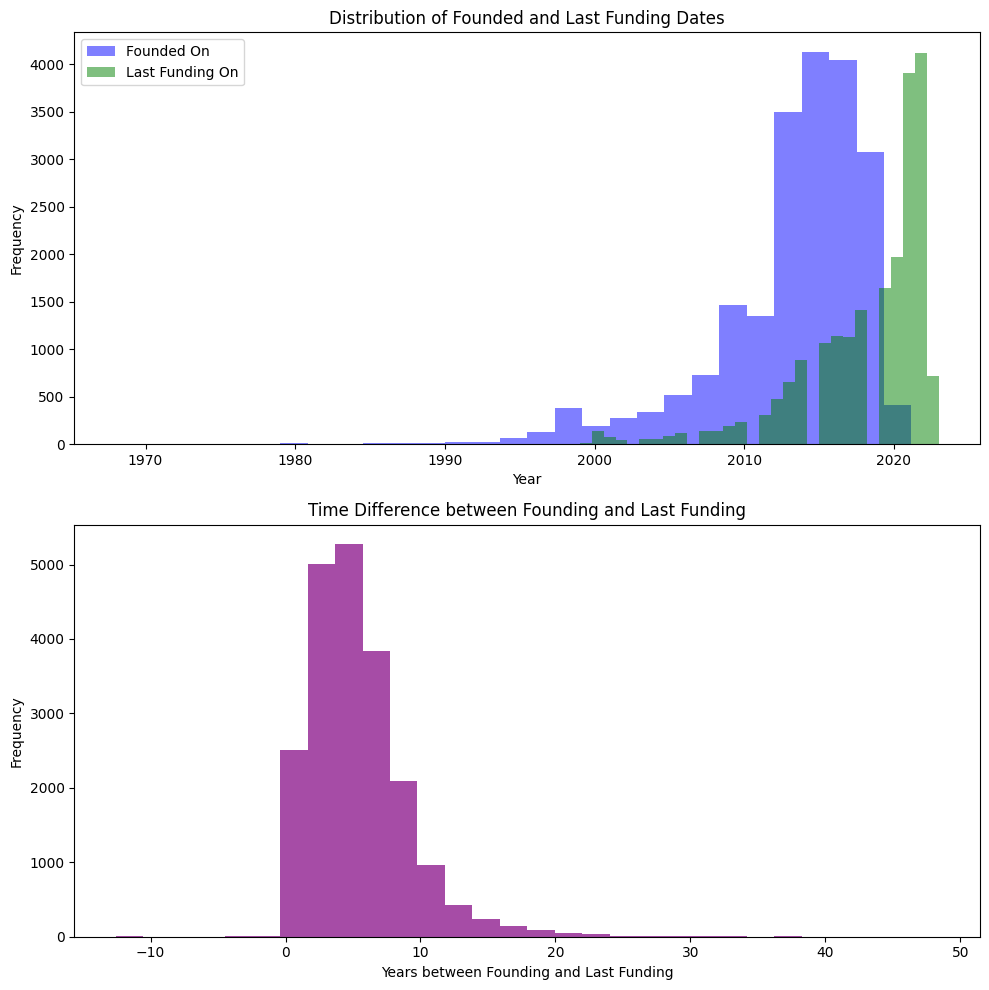

In [69]:
# Assuming 'founded_on_organization' and 'last_funding_on' are in datetime format
mach_df['founded_on_organization'] = pd.to_datetime(mach_df['founded_on_organization'])
mach_df['last_funding_on_organization'] = pd.to_datetime(mach_df['last_funding_on_organization'])

# Calculating the time difference in years
mach_df['time_diff_years'] = (mach_df['last_funding_on_organization'] - mach_df['founded_on_organization']).dt.days / 365

# Creating the figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# First plot: Distribution of founding and last funding dates
axs[0].hist(mach_df['founded_on_organization'].dt.year, bins=30, alpha=0.5, label='Founded On', color='blue')
axs[0].hist(mach_df['last_funding_on_organization'].dt.year, bins=30, alpha=0.5, label='Last Funding On', color='green')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Distribution of Founded and Last Funding Dates')
axs[0].legend()

# Second plot: Histogram of time differences between founding and last funding
axs[1].hist(mach_df['time_diff_years'], bins=30, alpha=0.7, color='purple')
axs[1].set_xlabel('Years between Founding and Last Funding')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Time Difference between Founding and Last Funding')

# Adjusting the layout to prevent overlap
plt.tight_layout()

# the plots
plt.show()


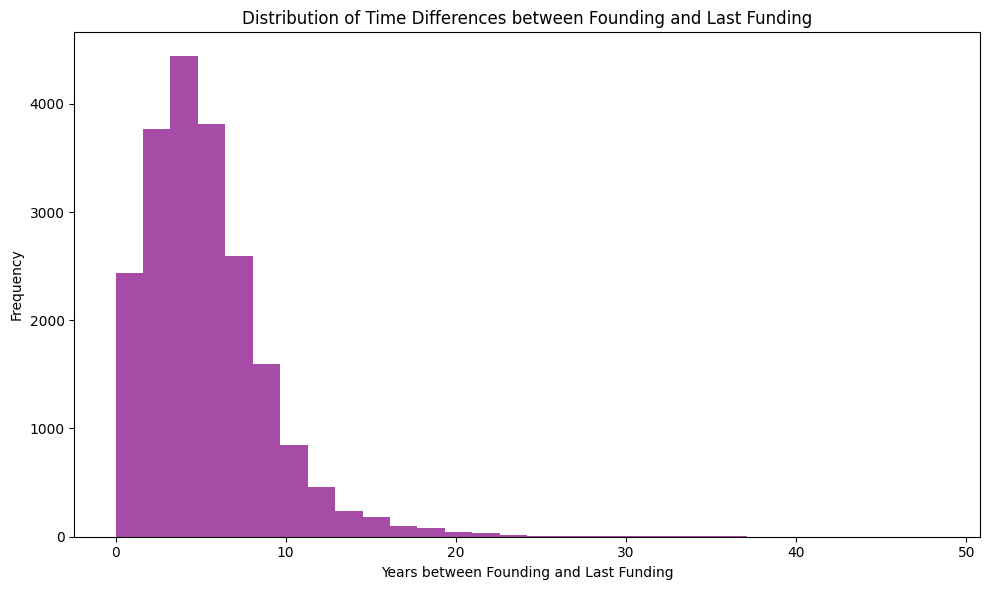

In [70]:
# Assuming 'founded_on_organization' and 'last_funding_on' are in datetime format
mach_df['founded_on_organization'] = pd.to_datetime(mach_df['founded_on_organization'])
mach_df['last_funding_on_organization'] = pd.to_datetime(mach_df['last_funding_on_organization'])

# Calculating the duration between founding and last funding in years
mach_df['duration_years'] = (mach_df['last_funding_on_organization'] - mach_df['founded_on_organization']).dt.days / 365.25

# Removing NaN or negative values, if any
mach_df = mach_df.dropna(subset=['duration_years'])
mach_df = mach_df[mach_df['duration_years'] >= 0]

# the histogram of time differences in years
plt.figure(figsize=(10,6))
plt.hist(mach_df['duration_years'], bins=30, color='purple', alpha=0.7)


plt.xlabel('Years between Founding and Last Funding')
plt.ylabel('Frequency')
plt.title('Distribution of Time Differences between Founding and Last Funding')


plt.tight_layout()
plt.show()


In [72]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import plot_tree

Dropping empty values possibly created when modifying date columns


In [74]:
mach_df = mach_df.dropna(subset=['founded_on_investors','total_funding_usd_investors' ])

DROPPING GEOGRAPHIC AND STATUS VARIABLES

In [75]:
unique_companies_machdf=mach_df['name_organization'].nunique()
print(unique_companies_machdf)

12024


In [76]:
mach_df=mach_df.drop(['funding_round_name', 'name_organization',],axis=1)

In [77]:
# Assuming mach_df is your DataFrame
empty_values_count = mach_df.isna().sum()

# Printing the number of empty values for each column
print(empty_values_count)

type_organization                        0
roles_organization                       0
country_code_organization                0
state_code_organization                  0
region_organization                      0
city_organization                        0
num_funding_rounds_organization          0
total_funding_usd_organization           0
founded_on_organization                  0
last_funding_on_organization             0
employee_count_organization              0
primary_role_organization                0
type_investors                           0
investor_name_investors                  0
investor_type                            0
is_lead_investor;;                       0
type_funding                             0
roles_investors                          0
country_code_investors                   0
state_code_investors                     0
region_investors                         0
city_investors                           0
investor_types_investors                 0
investment_

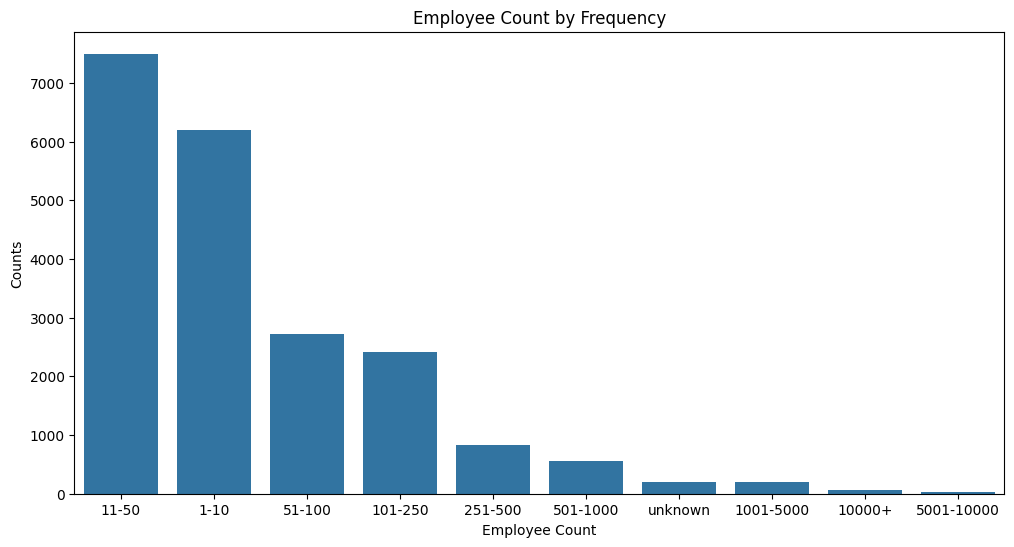

In [78]:
# Counting occurrences for each category in the 'employee_count' column
employee_counts = mach_df['employee_count_organization'].value_counts()

# Sorting the values from highest to lowest
sorted_employee_counts = employee_counts.sort_values(ascending=False)

# Creatig a bar plot for 'employee_count' sorted by frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_employee_counts.index, y=sorted_employee_counts.values)

plt.xlabel('Employee Count')
plt.ylabel('Counts')
plt.title('Employee Count by Frequency')

plt.savefig('employees.png')
plt.show()


/tmp/ipykernel_2002291/2690436030.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts_rounds.values, y=counts_rounds.index, palette="viridis")
/tmp/ipykernel_2002291/2690436030.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


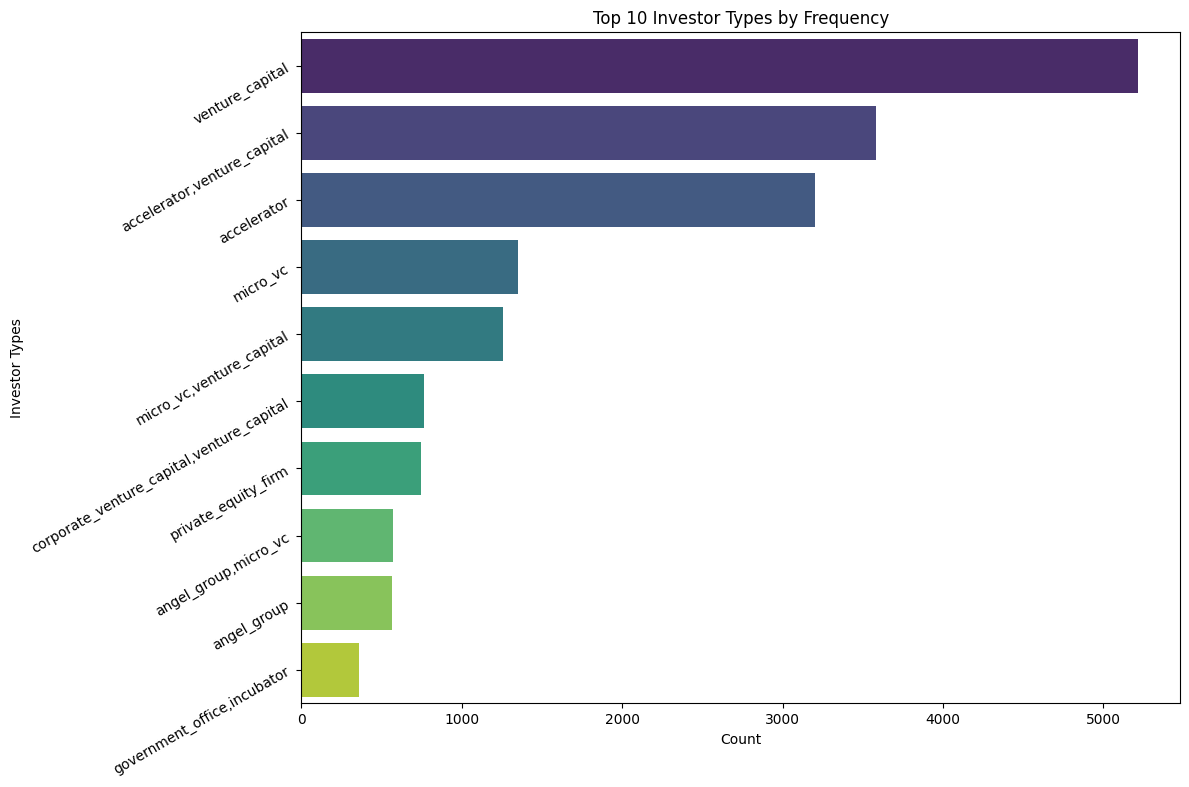

In [79]:
# Calculating the number of occurrences for each category in the 'investor_types_investors' column
counts_rounds = mach_df['investor_types_investors'].value_counts().nlargest(10)  # Get top 10

# Setting figure size
plt.figure(figsize=(12, 8))  # Adjusted figure size for better readability

# Creating a horizontal bar plot using Seaborn
ax = sns.barplot(x=counts_rounds.values, y=counts_rounds.index, palette="viridis")

# Setting the axis labels and chart title
ax.set_xlabel('Count')
ax.set_ylabel('Investor Types')
ax.set_title('Top 10 Investor Types by Frequency')

# Rotating y-axis labels for better readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

plt.tight_layout()
# Prevention of overlapping  
plt.savefig('investor_types.png')
plt.show()


Úprava Typů investora

In [80]:
unique_values = mach_df['investor_types_investors'].nunique()
print(unique_values)

71


In [81]:
# Defining keyword categories
category_1_keywords = ['accelerator', 'incubator', 'university_program', 'entrepreneurship_program', 
                        'co_working_space', 'startup_competition']
category_2_keywords = ['venture_capital', 'corporate_venture_capital', 'private_equity_firm', 'hedge_fund', 
                        'investment_bank', 'pension_funds', 'fund_of_funds', 'micro_vc', 'venture_debt', 'angel_group']

# List to store original values that were replaced with 'Other'
original_other_values = []

# Function to assign categories
def replace_with_categories(value):
    global original_other_values  # Access the list
    if pd.isna(value):  # Check if the value is missing
        return 'Other'
    tokens = value.split(',')
    category_1 = any(keyword in tokens for keyword in category_1_keywords)
    category_2 = any(keyword in tokens for keyword in category_2_keywords)
    if category_1:
        return 'Incubators & Accelerators'
    elif category_2:
        return 'Financial Investors'
    else:
        original_other_values.append(value)  # Store original unmatched value
        return 'Other'

# Apply the function to the column
mach_df['investor_types_investors'] = mach_df['investor_types_investors'].apply(replace_with_categories)

# Print first 40 original values that were replaced with 'Other'
print("Original values replaced with 'Other':")
print(original_other_values[:40])


Původní hodnoty nahrazené 'Other':
['government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office', 'government_office']


In [82]:
data_types = mach_df.dtypes
print(data_types)

type_organization                                object
roles_organization                               object
country_code_organization                        object
state_code_organization                          object
region_organization                              object
city_organization                                object
num_funding_rounds_organization                 float64
total_funding_usd_organization                  float64
founded_on_organization                  datetime64[ns]
last_funding_on_organization             datetime64[ns]
employee_count_organization                      object
primary_role_organization                        object
type_investors                                   object
investor_name_investors                          object
investor_type                                    object
is_lead_investor;;                               object
type_funding                                     object
roles_investors                                 

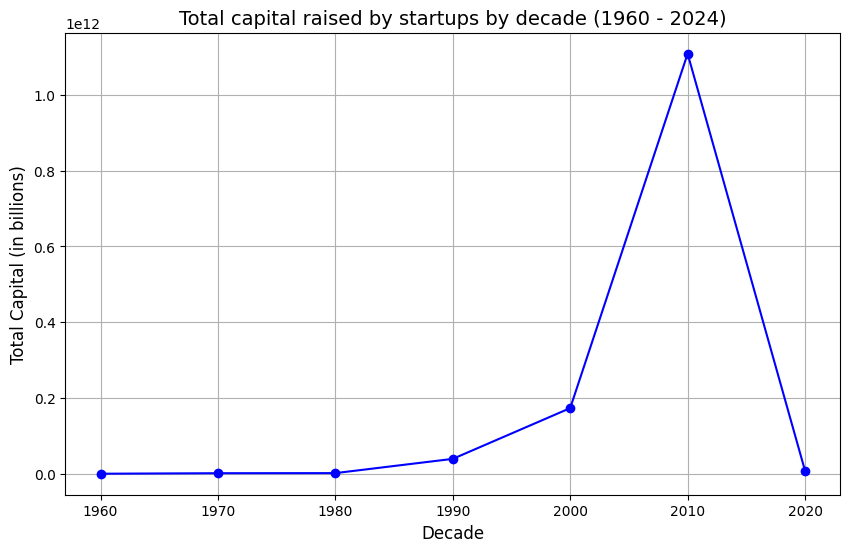

In [83]:
# Assigning decades based on the year of founding
mach_df['founded_year'] = mach_df['founded_on_organization'].dt.year  # Extract the year
mach_df['decade'] = (mach_df['founded_year'] // 10) * 10  # Convert to decade

# Aggregation of data by decade – sum or average of investments
decade_summary = mach_df.groupby('decade')['total_funding_usd_organization'].sum().reset_index()

# Visualization using a line plot
plt.figure(figsize=(10, 6))
plt.plot(decade_summary['decade'], decade_summary['total_funding_usd_organization'], marker='o', linestyle='-', color='b')

#labels and title
plt.title('Total capital raised by startups by decade (1960 - 2024)', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Total Capital (in billions)', fontsize=12)

# Display the plot
plt.grid(True)
plt.savefig('capital_startup_decade.png')
plt.show()


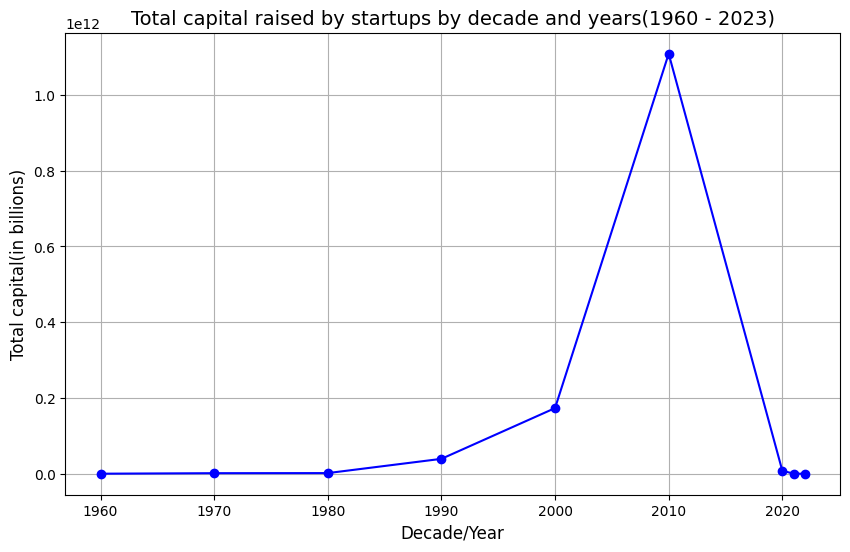

In [84]:
# Assigning the decades based on the year of founding
mach_df['founded_year'] = mach_df['founded_on_organization'].dt.year  # Extraction of the year
mach_df['decade'] = (mach_df['founded_year'] // 10) * 10  # Converting to decade

# Extracting separate entries for the years 2021, 2022, and 2023
recent_years = mach_df[mach_df['founded_year'].isin([2021, 2022, 2023])]

# Aggregation of data by decade – sum of investments
decade_summary = mach_df.groupby('decade')['total_funding_usd_organization'].sum().reset_index()

# Aggregation of data for the last three years (2021, 2022, 2023)
recent_summary = recent_years.groupby('founded_year')['total_funding_usd_organization'].sum().reset_index()

# Combining decade-level data with data from recent years
combined_summary = pd.concat([decade_summary, recent_summary.rename(columns={'founded_year': 'decade'})])

# Visualization using a line plot
plt.figure(figsize=(10, 6))
plt.plot(combined_summary['decade'], combined_summary['total_funding_usd_organization'], marker='o', linestyle='-', color='b')

# Adding labels and title
plt.title('Total capital raised by startups by decade and specific years (1960–2023)', fontsize=14)
plt.xlabel('Decade/Year', fontsize=12)
plt.ylabel('Total Capital (in billions)', fontsize=12)

# Display the plot
plt.grid(True)
plt.savefig('capital_startups.png')
plt.show()


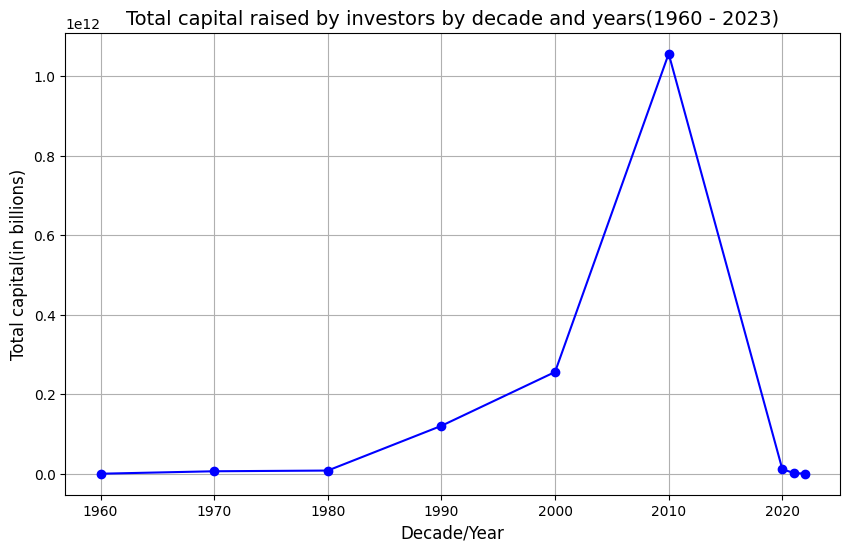

In [85]:
# Assigninng decades based on the year of founding
mach_df['founded_year'] = mach_df['founded_on_organization'].dt.year  # Extract the year
mach_df['decade'] = (mach_df['founded_year'] // 10) * 10  # Convert to decade

# Extraction  of separate entries for the years 2021, 2022, and 2023
recent_years = mach_df[mach_df['founded_year'].isin([2021, 2022, 2023])]

# Aggregation of data by decade – sum of investments from investors
decade_summary = mach_df.groupby('decade')['total_funding_usd_investors'].sum().reset_index()

# Aggregation of data for the last three years (2021, 2022, 2023)
recent_summary = recent_years.groupby('founded_year')['total_funding_usd_investors'].sum().reset_index()

# Combination of decade-level data with data from recent years
combined_summary = pd.concat([decade_summary, recent_summary.rename(columns={'founded_year': 'decade'})])

# Visualization using a line plot
plt.figure(figsize=(10, 6))
plt.plot(combined_summary['decade'], combined_summary['total_funding_usd_investors'], marker='o', linestyle='-', color='b')

# Adding labels and title
plt.title('Total capital raised by investors by decade and years (1960–2023)', fontsize=14)
plt.xlabel('Decade/Year', fontsize=12)
plt.ylabel('Total Capital (in billions)', fontsize=12)

# Display the plot
plt.grid(True)
plt.savefig('capital_startups_investors.png')
plt.show()


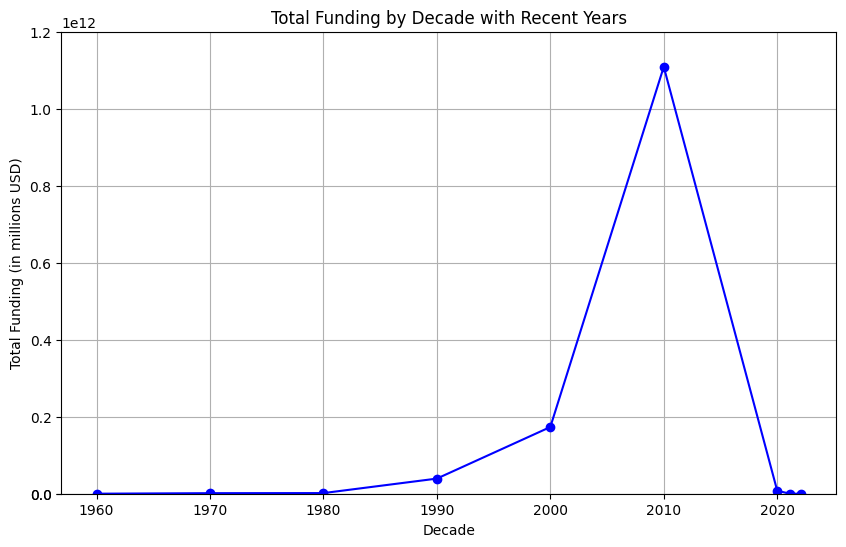

In [86]:
# Extraction of the year from 'founded_on_organization' column
mach_df['year'] = mach_df['founded_on_organization'].dt.year

# Group by decades
mach_df['decade'] = (mach_df['year'] // 10) * 10
decade_summary = mach_df.groupby('decade')['total_funding_usd_organization'].sum().reset_index()

# Adding recent years (2021, 2022, 2023) as separate groups
recent_years = mach_df[mach_df['year'] >= 2021]
recent_years_summary = recent_years.groupby('year')['total_funding_usd_organization'].sum().reset_index()

# Assigning decimal values to recent years to distinguish them visually, e.g., 2020.1 for 2021, etc.
recent_years_summary['decade'] = recent_years_summary['year'] - 2020 + 2020.1

# Combination of decade-level data with recent years data
combined_summary = pd.concat([decade_summary, recent_years_summary], ignore_index=True)

# Creating a line plot
plt.figure(figsize=(10, 6))
plt.plot(combined_summary['decade'], combined_summary['total_funding_usd_organization'], marker='o', color='b', label='Total Funding')

# Setting y-axis range from zero and add a manual tick at 25,000
plt.ylim(0, max(combined_summary['total_funding_usd_organization'].max(), 25000))

# Manually adding a tick at 25,000 to the Y-axis
current_ticks = plt.yticks()[0]
new_ticks = list(current_ticks) + [25000]
plt.yticks(new_ticks)

# Adding axis labels and title
plt.xlabel('Decade')
plt.ylabel('Total Funding (in millions USD)')
plt.title('Total Funding by Decade with Recent Years')
plt.grid(True)

#the plot
plt.show()


/tmp/ipykernel_2002291/1363447088.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  soubor_filtr_companies['founded_on_organization'] = pd.to_datetime(soubor_filtr_companies['founded_on_organization'], errors='coerce')


2982
0


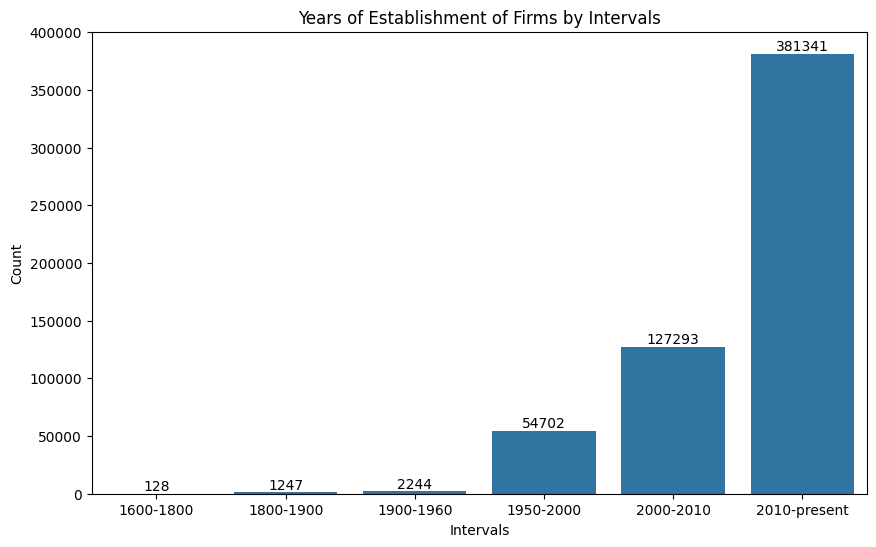

In [87]:
# Converting 'founded_on_org' or 'founded_on_organization' to datetime format
merged_df['founded_on_org'] = pd.to_datetime(merged_df['founded_on_org'], errors='coerce')
soubor_filtr_companies['founded_on_organization'] = pd.to_datetime(soubor_filtr_companies['founded_on_organization'], errors='coerce')

# Checking how many dates could not be converted (optional step for debugging)
print(merged_df['founded_on_org'].isnull().sum())
print(soubor_filtr_companies['founded_on_organization'].isnull().sum())

# Creating intervals
# Merged_df intervals
current_year = pd.to_datetime('today').year
intervals_merged = pd.cut(merged_df['founded_on_org'].dt.year, 
                          bins=[1600,1800, 1900, 1960, 2000, 2010, current_year], 
                          labels=['1600-1800','1800-1900','1900-1960', '1950-2000', '2000-2010', '2010-present'])


# Adding the intervals columns to respective dataframes
merged_df['intervals'] = intervals_merged


# Calculating the count of funding rounds in each interval for merged_df
counts = merged_df['intervals'].value_counts()

# Creating a bar plot using Seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.index, y=counts.values)

# Adding labels to the bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '%d' % int(p.get_height()), 
            ha='center', va='bottom', fontsize=10)

# Setting axis labels and title
plt.xlabel('Intervals')
plt.ylabel('Count')
plt.title('Years of Establishment of Firms by Intervals')

# the plot
plt.savefig('founded_years.png')
plt.show()


In [88]:
columns_merged= merged_df.columns
print(columns_merged.to_list())

['uuid_org', 'name_org', 'type_org', 'permalink_org', 'cb_url_org', 'rank_org', 'created_at_org', 'updated_at_org', 'legal_name', 'roles_org', 'domain_org', 'homepage_url', 'country_code', 'state_code', 'region', 'city', 'address', 'postal_code', 'status', 'short_description', 'category_list', 'category_groups_list', 'num_funding_rounds', 'total_funding_usd_org', 'total_funding_org', 'total_funding_currency_code_org', 'founded_on_org', 'last_funding_on', 'closed_on_org', 'employee_count', 'email', 'phone', 'facebook_url_org', 'linkedin_url_org', 'twitter_url_org', 'logo_url_org', 'alias1', 'alias2', 'alias3', 'primary_role', 'num_exits', 'uuid_x', 'name_x', 'type_x', 'permalink_x', 'cb_url_x', 'rank_x', 'created_at_x', 'updated_at_x', 'funding_round_uuid', 'funding_round_name', 'investor_uuid', 'investor_name', 'investor_type', 'is_lead_investor;;', 'uuid_y', 'name_y', 'type_y', 'permalink_y', 'cb_url_y', 'rank_y', 'created_at_y', 'updated_at_y', 'roles_all', 'domain_all', 'country_cod

In [89]:
# Display the names of all columns and their data types

print(mach_df.dtypes)

type_organization                                object
roles_organization                               object
country_code_organization                        object
state_code_organization                          object
region_organization                              object
city_organization                                object
num_funding_rounds_organization                 float64
total_funding_usd_organization                  float64
founded_on_organization                  datetime64[ns]
last_funding_on_organization             datetime64[ns]
employee_count_organization                      object
primary_role_organization                        object
type_investors                                   object
investor_name_investors                          object
investor_type                                    object
is_lead_investor;;                               object
type_funding                                     object
roles_investors                                 

In [90]:
# Function to convert year to decade
def year_to_decade(year):
    if pd.isna(year):  # If the value is NaN, return None
        return None
    if isinstance(year, pd.Timestamp):  # If the year is a Timestamp, get the year part
        year = year.year
    try:
        year = int(year)  # Ensure it's an integer if possible
    except ValueError:
        # If year is already in a string format like '2010-2019', return as is
        return year
    
    # logic for mapping year to decade
    if year < 1960:  # For values before 1960
        return '<1960'
    elif 1960 <= year < 1970:
        return '1960-1970'
    elif 1970 <= year < 1980:
        return '1970-1980'
    elif 1980 <= year < 1990:
        return '1980-1990'
    elif 1990 <= year < 2000:
        return '1990-2000'
    elif 2000 <= year < 2010:
        return '2000-2010'
    elif 2010 <= year < 2020:
        return '2010-2020'
    else:
        return '2020+'

#  Are columns in datetime format?
columns_to_convert = ['founded_on_organization', 'last_funding_on_organization','announced_on_funding','founded_on_investors']

# Looping through the columns to convert them to datetime first
for col in columns_to_convert:
    mach_df[col] = pd.to_datetime(mach_df[col], errors='coerce')  # Convert to datetime, coerce errors to NaT
    mach_df[f'{col}_decade'] = mach_df[col].apply(year_to_decade)  # Apply the year to decade conversion

# Checking the results
print(mach_df[[f'{col}_decade' for col in columns_to_convert]].head())


    founded_on_organization_decade last_funding_on_organization_decade  \
189                      2000-2010                           2010-2020   
221                      2000-2010                           2000-2010   
222                      2000-2010                           2000-2010   
236                      2000-2010                           2000-2010   
239                      2000-2010                           2000-2010   

    announced_on_funding_decade founded_on_investors_decade  
189                   2000-2010                   2000-2010  
221                   2000-2010                   1990-2000  
222                   2000-2010                   1990-2000  
236                   2000-2010                   2000-2010  
239                   2000-2010                   1980-1990  


In [91]:
print(mach_df.dtypes)

type_organization                                object
roles_organization                               object
country_code_organization                        object
state_code_organization                          object
region_organization                              object
city_organization                                object
num_funding_rounds_organization                 float64
total_funding_usd_organization                  float64
founded_on_organization                  datetime64[ns]
last_funding_on_organization             datetime64[ns]
employee_count_organization                      object
primary_role_organization                        object
type_investors                                   object
investor_name_investors                          object
investor_type                                    object
is_lead_investor;;                               object
type_funding                                     object
roles_investors                                 

In [92]:
print(mach_df.columns)

Index(['type_organization', 'roles_organization', 'country_code_organization',
       'state_code_organization', 'region_organization', 'city_organization',
       'num_funding_rounds_organization', 'total_funding_usd_organization',
       'founded_on_organization', 'last_funding_on_organization',
       'employee_count_organization', 'primary_role_organization',
       'type_investors', 'investor_name_investors', 'investor_type',
       'is_lead_investor;;', 'type_funding', 'roles_investors',
       'country_code_investors', 'state_code_investors', 'region_investors',
       'city_investors', 'investor_types_investors',
       'investment_count_investors', 'total_funding_usd_investors',
       'founded_on_investors', 'type_investors', 'country_code_funding',
       'state_code_funding', 'region_funding', 'city_funding',
       'investment_type', 'announced_on_funding', 'investor_count_funding',
       'Presence_on_social_media_organization',
       'Presence_on_social_media_investors'

In [93]:
columns_to_drop = ['founded_on_organization','state_code_organization','state_code_funding','state_code_investors','region_funding','region_organization','region_investors','last_funding_on_organization','investor_name_investors',
                   'founded_on_investors','announced_on_funding','year','decade','founded_year','duration_years','time_diff_years', 'type_organization','type_investors','type_funding','primary_role_organization','investor_name_investors']

# Dropping the columns from the DataFrame
mach_df = mach_df.drop(columns=columns_to_drop, errors='ignore')

In [94]:
# Function to replace values
def replace_country(value):
    if value in ['USA', 'US']:
        return 'US'
    else:
        return 'non-US'

# Application of the function to selected columns in the DataFrame
mach_df['country_code_organization'] = mach_df['country_code_organization'].apply(replace_country)
mach_df['country_code_funding'] = mach_df['country_code_funding'].apply(replace_country)
mach_df['country_code_investors'] = mach_df['country_code_investors'].apply(replace_country)

# Print for verification
print(mach_df[['country_code_organization', 'country_code_funding', 'country_code_investors']])


       country_code_organization country_code_funding country_code_investors
189                           US                   US                     US
221                           US                   US                     US
222                           US                   US                     US
236                           US                   US                     US
239                           US                   US                     US
...                          ...                  ...                    ...
711047                        US                   US                     US
711055                        US                   US                     US
711061                        US                   US                     US
711073                        US                   US                     US
711076                        US                   US                     US

[20725 rows x 3 columns]


In [95]:
# Function to replace city values
def replace_city(value):
    if value in ['London', 'New York City', 'New York', 'Tel Aviv', 'Los Angeles', 'Boston', 'Singapore',
                 'Beijing', 'Seoul', 'Tokyo', 'Shanghai', 'Washington', 'Amsterdam', 'Paris', 'Berlin',
                 'Miami', 'Chicago', 'Toronto', 'Toronto-Waterloo', 'San Diego', 'Seattle', 'Campbell',
                 'Cupertino', 'Gilroy', 'Los Altos', 'Los Gatos', 'Milpitas', 'Morgan Hill', 'Mountain View',
                 'Palo Alto', 'San Jose', 'Santa Clara', 'Saratoga', 'Sunnyvale']:
        return 'core-startup-city'
    else:
        return 'non-core-startup-city'

# Application of the function to selected columns in the DataFrame
mach_df['city_organization'] = mach_df['city_organization'].apply(replace_city)
mach_df['city_funding'] = mach_df['city_funding'].apply(replace_city)
mach_df['city_investors'] = mach_df['city_investors'].apply(replace_city)

# Print for verification
print(mach_df[['city_organization', 'city_funding', 'city_investors']])


            city_organization           city_funding         city_investors
189     non-core-startup-city  non-core-startup-city      core-startup-city
221         core-startup-city      core-startup-city  non-core-startup-city
222         core-startup-city      core-startup-city  non-core-startup-city
236         core-startup-city      core-startup-city  non-core-startup-city
239         core-startup-city      core-startup-city      core-startup-city
...                       ...                    ...                    ...
711047      core-startup-city      core-startup-city  non-core-startup-city
711055      core-startup-city      core-startup-city  non-core-startup-city
711061      core-startup-city      core-startup-city  non-core-startup-city
711073  non-core-startup-city  non-core-startup-city  non-core-startup-city
711076  non-core-startup-city  non-core-startup-city  non-core-startup-city

[20725 rows x 3 columns]


In [96]:
# Setting the display format for numeric values to avoid scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# Format selected columns to show no decimal places
columns_no_decimal = ['announced_on_funding_decade', 'founded_on_investors_decade', 
                      'founded_on_organization_decade', 'last_funding_on_organization_decade']

# Function to format numeric values without decimals
def format_numeric_values(x):
    if pd.api.types.is_numeric_dtype(x):  # Check if value is numeric
        return '{:.0f}'.format(x)  # Format as integer
    else:
        return x  # Leave non-numeric values unchanged

# Application of the formatting function to specified columns
mach_df[columns_no_decimal] = mach_df[columns_no_decimal].applymap(format_numeric_values)

# Statistical summary of numerical variables (rounded to 2 decimals)
summary_numeric = mach_df.describe().round(2)

# Statistical summary of categorical variables
summary_categorical = mach_df.describe(include=['object', 'category'])

# Transpose the tables
summary_numeric_T = summary_numeric.T
summary_categorical_T = summary_categorical.T

# Function to plot transposed table and save as image
def plot_transposed_table(df, title, filename):
    fig, ax = plt.subplots(figsize=(20, 12))  # Increased size for better readability
    ax.axis('tight')
    ax.axis('off')

    # Creating the table
    table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, loc='center', cellLoc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(14)  # Increase font size
    table.scale(3, 3)  # Scaling up the table significantly
    
    plt.title(title, fontsize=18)
    
    # Saving the table as an image with higher DPI for better quality
    plt.savefig(filename, bbox_inches='tight', dpi=400)  
    plt.close()

# Saving the transposed tables as two images
plot_transposed_table(summary_numeric_T, "Statistical Summary of Numerical Variables", "statistic_summary_numeric.png")
plot_transposed_table(summary_categorical_T, "Statistical Summary of Categorical Variables", "statistic_summary_categorical.png")

# Saving both summaries to an Excel file
with pd.ExcelWriter('statistic_summary.xlsx') as writer:
    summary_numeric_T.to_excel(writer, sheet_name='Numeric Summary')
    summary_categorical_T.to_excel(writer, sheet_name='Categorical Summary')

print("Excel file saved as 'statistic_summary.xlsx'.")


/tmp/ipykernel_2002291/4033216514.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mach_df[columns_no_decimal] = mach_df[columns_no_decimal].applymap(format_numeric_values)


Excel file saved as 'statistic_summary.xlsx'.


/tmp/ipykernel_2002291/828836494.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts_rounds.values, y=counts_rounds.index, palette="viridis")
/tmp/ipykernel_2002291/828836494.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


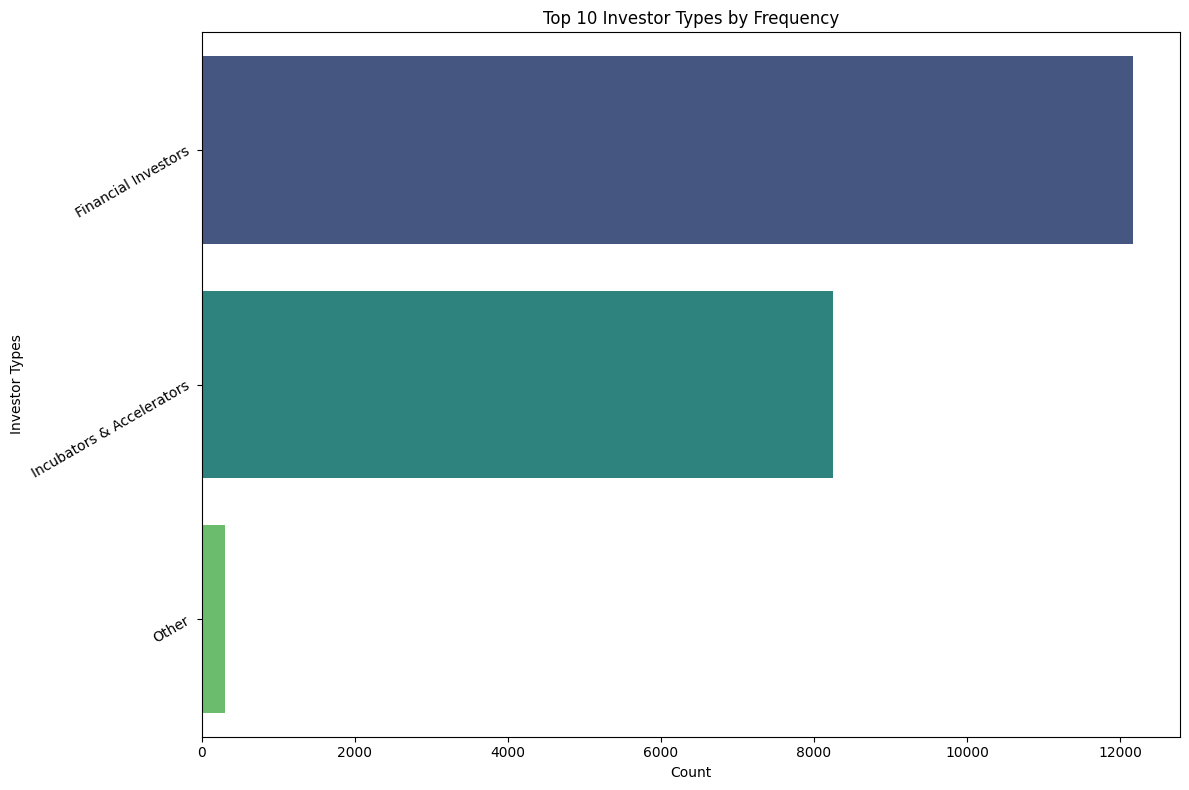

In [97]:
# Calculating the number of occurrences for each category in the 'investor_types_investors' column
counts_rounds = mach_df['investor_types_investors'].value_counts().nlargest(10)  # Get top 10

# Setting the figure size
plt.figure(figsize=(12, 8))  # Adjusted figure size for better readability

# Creating a horizontal bar plot using Seaborn
ax = sns.barplot(x=counts_rounds.values, y=counts_rounds.index, palette="viridis")

# Set axis labels and chart title
ax.set_xlabel('Count')
ax.set_ylabel('Investor Types')
ax.set_title('Top 10 Investor Types by Frequency')

# Rotating y-axis labels for better readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Saving the chart to a file
plt.tight_layout()  # Making sure everything fits without overlapping
plt.savefig('investor_types_adjusted.png')

# Displaying the chart
plt.show()


In [98]:
# Calculating skewness for numerical columns in the DataFrame

skewness = mach_df.skew(numeric_only=True)
print(skewness)


num_funding_rounds_organization          1.36
total_funding_usd_organization          35.52
investment_count_investors               1.20
total_funding_usd_investors             14.07
investor_count_funding                   4.33
Presence_on_social_media_organization   -1.39
Presence_on_social_media_investors      -1.80
dtype: float64


In [99]:
# Interpretation
for column in skewness.index:
    if skewness[column] > 1 or skewness[column] < -1:
        print(f"{column} má vysokou šikmost.")
    elif (skewness[column] > 0.5 and skewness[column] <= 1) or (skewness[column] < -0.5 and skewness[column] >= -1):
        print(f"{column} má mírnou šikmost.")
    else:
        print(f"{column} má nízkou nebo žádnou šikmost.")

num_funding_rounds_organization má vysokou šikmost.
total_funding_usd_organization má vysokou šikmost.
investment_count_investors má vysokou šikmost.
total_funding_usd_investors má vysokou šikmost.
investor_count_funding má vysokou šikmost.
Presence_on_social_media_organization má vysokou šikmost.
Presence_on_social_media_investors má vysokou šikmost.


In [100]:
# Applying np.log1p to all specified columns at once using the DataFrame apply method
cols_to_transform = ['total_funding_usd_investors','total_funding_usd_organization','num_funding_rounds_organization','investment_count_investors','investor_count_funding']
mach_df[cols_to_transform] = mach_df[cols_to_transform].apply(np.log1p)

In [101]:
X_categorial = mach_df.drop('total_funding_usd_organization',axis=1)
X=pd.get_dummies(X_categorial)
y = mach_df['total_funding_usd_organization']
print('Number of samples in X:', X.shape[0])
print('Number of labels in y:', len(y))

Number of samples in X: 20725
Number of labels in y: 20725


In [102]:
print(y.head())

189   18.48
221   15.53
222   15.53
236   17.16
239   17.16
Name: total_funding_usd_organization, dtype: float64


In [103]:
print(y.unique())
print(y.dtype)

[18.47658839 15.53380305 17.1583724  ... 14.47817121 16.91672838
 15.70741758]
float64


In [104]:
misy= y.isna().sum()
print(misy)

0


In [105]:
misy_1= mach_df.isna().sum()
print(misy_1)

roles_organization                       0
country_code_organization                0
city_organization                        0
num_funding_rounds_organization          0
total_funding_usd_organization           0
employee_count_organization              0
investor_type                            0
is_lead_investor;;                       0
roles_investors                          0
country_code_investors                   0
city_investors                           0
investor_types_investors                 0
investment_count_investors               0
total_funding_usd_investors              0
country_code_funding                     0
city_funding                             0
investment_type                          0
investor_count_funding                   0
Presence_on_social_media_organization    0
Presence_on_social_media_investors       0
type_of_industry_organization            0
founded_on_organization_decade           0
last_funding_on_organization_decade      0
announced_o

In [106]:
mach_df = mach_df.dropna(subset=['founded_on_investors_decade'])

In [107]:
#training and testing_data
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Number of samples in X_train:', X_train.shape[0])
print('Number of labels in y_train:', len(y_train))

Number of samples in X_train: 14507
Number of labels in y_train: 14507


SIMPLE REGRESSION DECISION TREE

In [108]:
from sklearn.tree import DecisionTreeRegressor
reg =DecisionTreeRegressor(random_state=42)
reg.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [109]:
# Prediction
y_train_pred = reg.predict(X_train)


In [110]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

In [111]:
# Calculating metrics for the training set

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)

In [112]:
# Print metrics for the training set

print("Trénovací sada:")
print(f'Mean Squared Error (MSE): {mse_train_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_train_rounded}')
print(f'Mean Absolute Error (MAE): {mae_train_rounded}')
print(f'R-squared (R²): {r2_train_rounded}')

Trénovací sada:
Mean Squared Error (MSE): 0.032
Root Mean Squared Error (RMSE): 0.179
Mean Absolute Error (MAE): 0.031
R-squared (R²): 0.994


In [113]:
y_test_pred = reg.predict(X_test)

# Calculating metrics for the testing set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

#Print metrics for testing set
print("Testovací sada:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')

Testovací sada:
Mean Squared Error (MSE): 1.788
Root Mean Squared Error (RMSE): 1.337
Mean Absolute Error (MAE): 0.94
R-squared (R²): 0.674


In [114]:
# Number of leaf nodes
num_leaf_nodes = reg.get_n_leaves()
print(f"Počet listových uzlů (listových regionů): {num_leaf_nodes}")

Počet listových uzlů (listových regionů): 12602


FEATURE IMPORTANCE REGRESSION TREE

<Figure size 1500x1200 with 0 Axes>

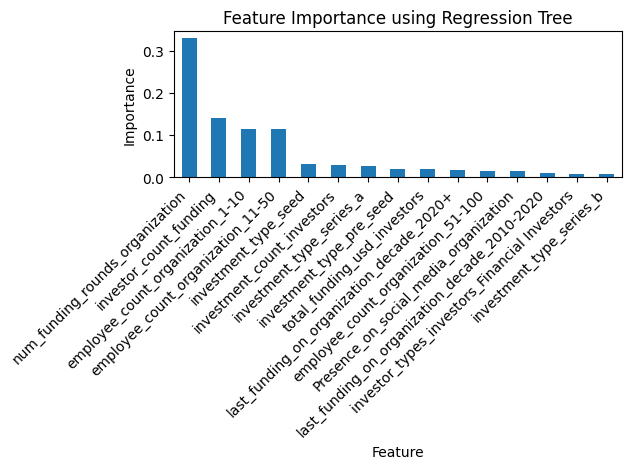

In [115]:


# Creating a dataframe with feature importances and their names
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(15, 12))
top_features_df = features_df.head(15)
top_features_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance using Regression Tree')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)

plt.xticks(rotation=45, ha='right')  # Slight rotation and alignment of labels
plt.tight_layout()

plt.savefig('new_feature_importance_regression_tree_bezgeo.png', bbox_inches='tight')
plt.show()


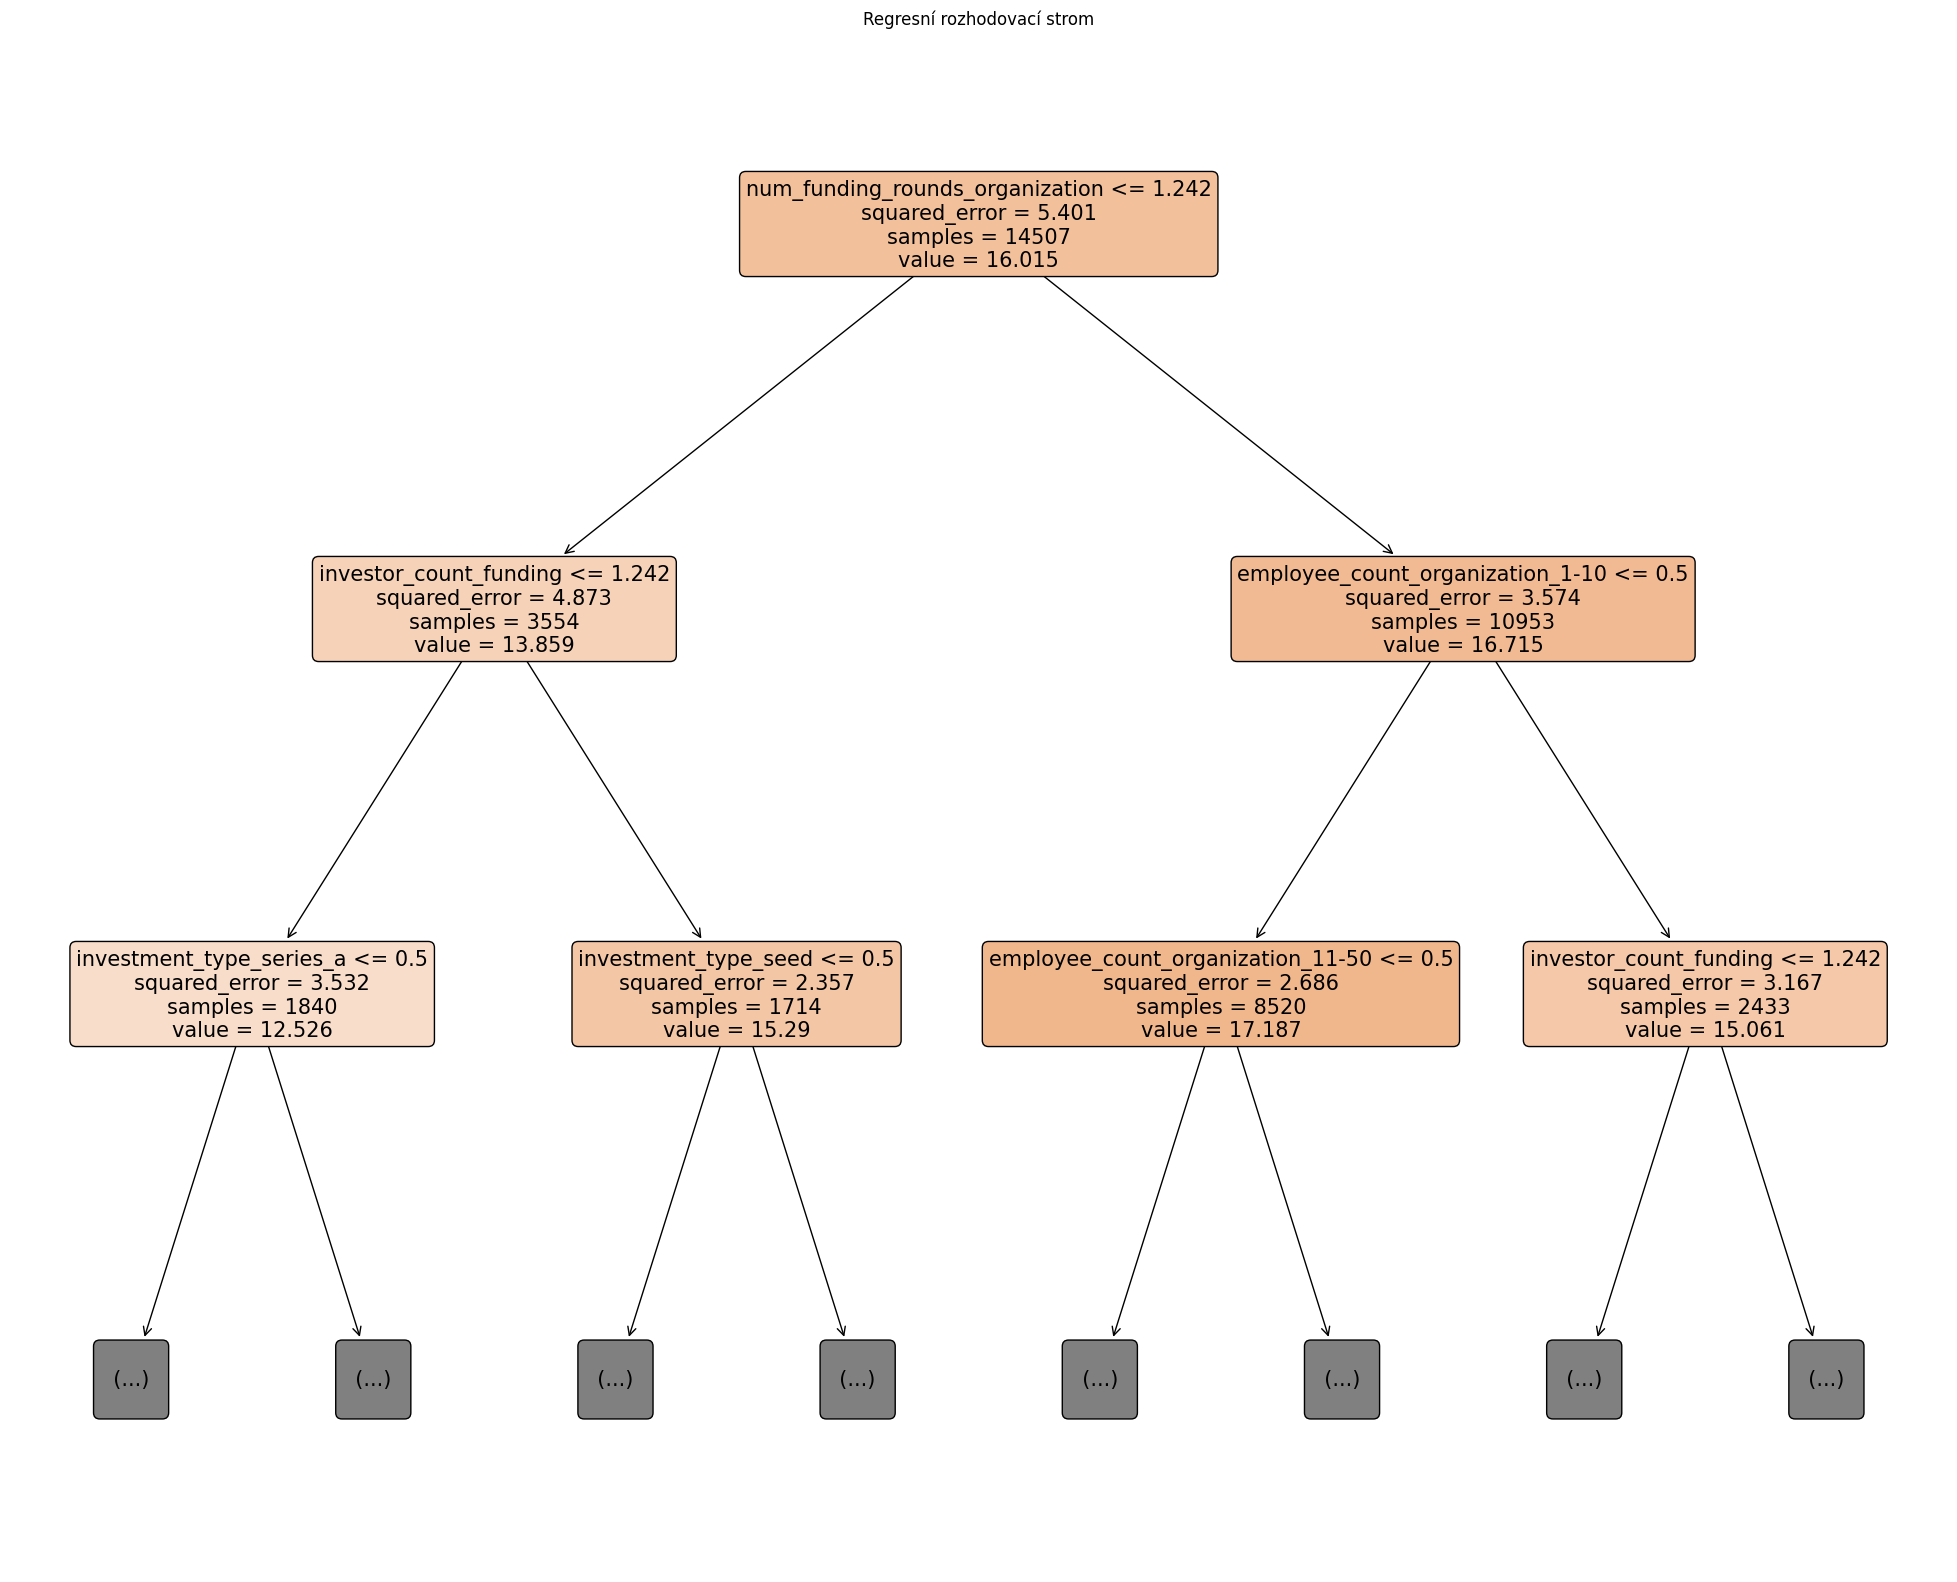

In [117]:
# Tree visualization
plt.figure(figsize=(25, 20))

# Converting pandas Index object to list
feature_names_list = X_train.columns.tolist()
plot_tree(
    reg,
    max_depth=2,
    feature_names=feature_names_list,
    fontsize=15,
    filled=True,
    rounded=True
)
plt.title("Regression Decision Tree")
plt.savefig('first_tree.png')
plt.show()


In [118]:
# Accessing the tree structure
tree = reg.tree_

# Function to compute the weighted average for a given branch
def calculate_branch_average(tree, node_id):
    # If the node is a leaf, return its value and number of samples
    if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
        return tree.value[node_id][0][0], tree.n_node_samples[node_id]

    # Otherwise, recursively compute averages for left and right children
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    left_value, left_samples = calculate_branch_average(tree, left_child)
    right_value, right_samples = calculate_branch_average(tree, right_child)

    # Weighted average of left and right branch values
    total_samples = left_samples + right_samples
    weighted_average = (left_value * left_samples + right_value * right_samples) / total_samples

    return weighted_average, total_samples

# Average value for the left branch (left child of the root node)
left_branch_average, left_samples = calculate_branch_average(tree, tree.children_left[0])

# Average value for the right branch (right child of the root node)
right_branch_average, right_samples = calculate_branch_average(tree, tree.children_right[0])

print(f"Average value in the left branch: {left_branch_average} (samples: {left_samples})")
print(f"Average value in the right branch: {right_branch_average} (samples: {right_samples})")


Průměrná hodnota v levé větvi: 13.858832452431924 (vzorky: 3554)
Průměrná hodnota v pravé větvi: 16.714893473078686 (vzorky: 10953)


In [119]:
# Counting the number of layers (tree depth)
depth = reg.get_depth()
print(f"Number of tree layers: {depth}")


Počet vrstev stromu: 36


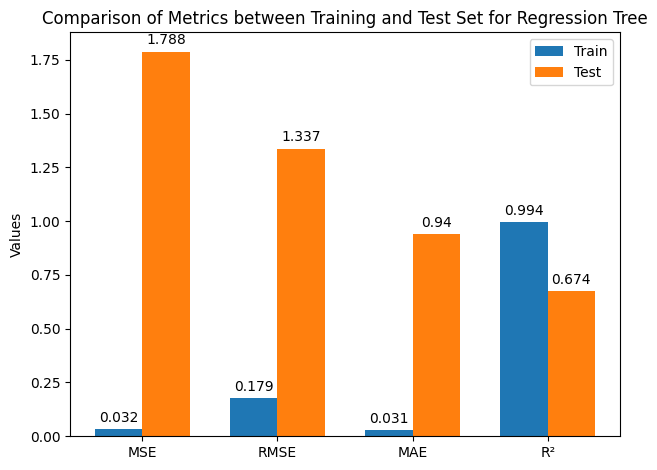

In [120]:
# Metrics for training and test sets
metrics_train = [mse_train, rmse_train, mae_train, r2_train]
metrics_test = [mse_test, rmse_test, mae_test, r2_test]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding labels, title and custom x-axis tick labels
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics between Training and Test Set for Regression Tree')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('metrics_comparison_regtree_vychozi.png')
plt.show()


In [121]:
# Number of leaf nodes
num_leaf_nodes = reg.get_n_leaves()
print(f"Number of leaf nodes (terminal regions): {num_leaf_nodes}")


Počet listových uzlů (listových regionů): 12602


In [122]:
# Calculating the range of values

min_value = mach_df['total_funding_usd_organization'].min()
max_value = mach_df['total_funding_usd_organization'].max()

print(f"Minimální hodnota: {min_value}")
print(f"Maximální hodnota: {max_value}")
print(f"Rozsah hodnot: ({min_value}, {max_value})")


Minimální hodnota: 8.498621805830801
Maximální hodnota: 23.44490546917194
Rozsah hodnot: (8.498621805830801, 23.44490546917194)


FIRST MODEL WITH MODIFIED PARAMETERS

Výsledky pro model 1:
{'Model': 'Model 1', 'Params': {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42}, 'MSE Train': 1.965, 'RMSE Train': 1.402, 'MAE Train': 1.068, 'R2 Train': 0.633, 'MSE Test': 2.007, 'RMSE Test': 1.417, 'MAE Test': 1.094, 'R2 Test': 0.651}


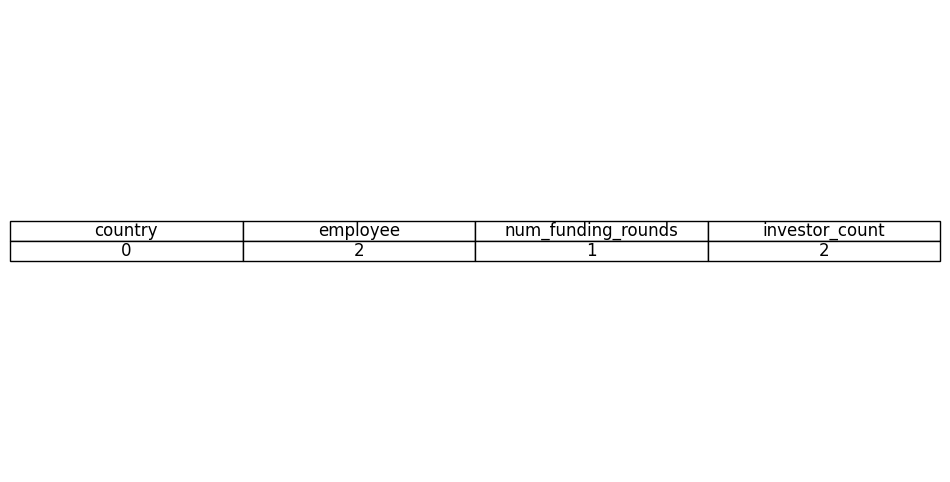

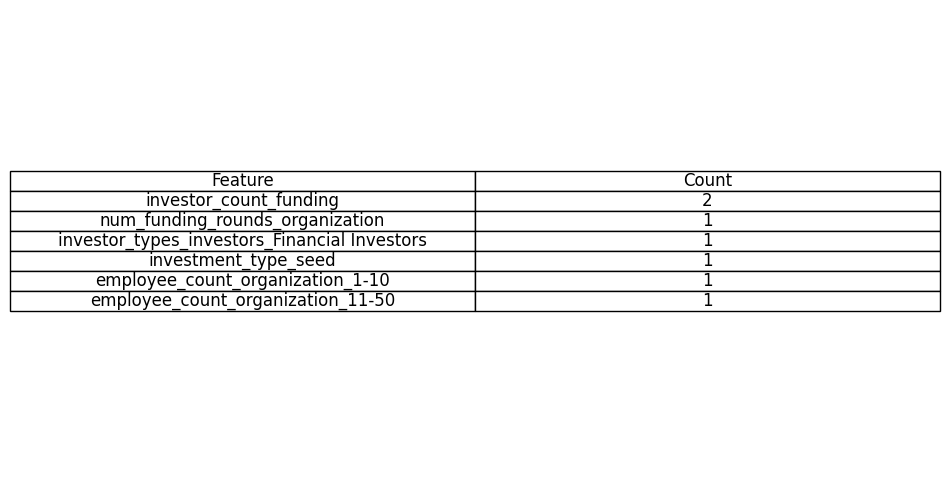

<Figure size 1500x1200 with 0 Axes>

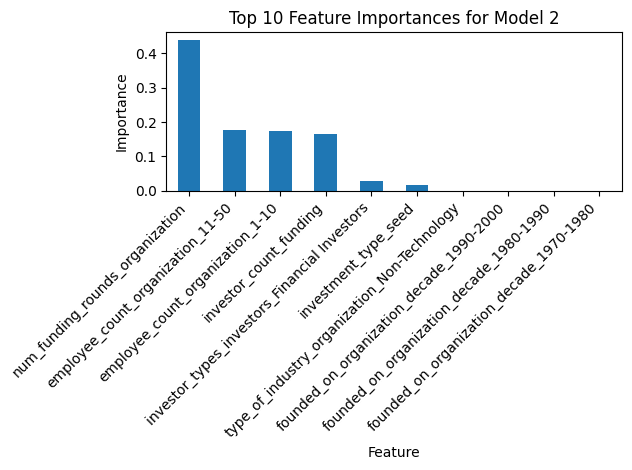

In [123]:
# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameters for Model 1
params1 = {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42}

# Train Model 1
model1 = DecisionTreeRegressor(**params1).fit(X_train, y_train)

# Predictions on training and test sets
y_train_pred1 = model1.predict(X_train)
y_test_pred1 = model1.predict(X_test)

# Computing metrics for training and test sets
mse_train1 = mean_squared_error(y_train, y_train_pred1)
rmse_train1 = np.sqrt(mse_train1)
mae_train1 = mean_absolute_error(y_train, y_train_pred1)
r2_train1 = r2_score(y_train, y_train_pred1)

mse_train1_rounded = round(mse_train1, 3)
rmse_train1_rounded = round(rmse_train1, 3)
mae_train1_rounded = round(mae_train1, 3)
r2_train1_rounded = round(r2_train1, 3)

mse_test1 = mean_squared_error(y_test, y_test_pred1)
rmse_test1 = np.sqrt(mse_test1)
mae_test1 = mean_absolute_error(y_test, y_test_pred1)
r2_test1 = r2_score(y_test, y_test_pred1)

mse_test1_rounded = round(mse_test1, 3)
rmse_test1_rounded = round(rmse_test1, 3)
mae_test1_rounded = round(mae_test1, 3)
r2_test1_rounded = round(r2_test1, 3)

# Results for Model 1
results1 = {
    'Model': 'Model 1',
    'Params': params1,
    'MSE Train': mse_train1_rounded,
    'RMSE Train': rmse_train1_rounded,
    'MAE Train': mae_train1_rounded,
    'R2 Train': r2_train1_rounded,
    'MSE Test': mse_test1_rounded,
    'RMSE Test': rmse_test1_rounded,
    'MAE Test': mae_test1_rounded,
    'R2 Test': r2_test1_rounded
}

# Print results for Model 1
print("Results for Model 1:")
print(results1)

# Feature importances for Model 1
feature_importances1 = model1.feature_importances_

# Function to traverse tree and count occurrences of some features
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # If not a leaf node
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Count keyword feature occurrences in the tree for Model 1
feature_count1, count_dict1 = count_features_in_tree(model1.tree_, X.columns)

# Creating DataFrame with keyword feature counts for Model 1
search_features_df1 = pd.DataFrame([count_dict1], index=['Model 1'])

# Displaying table of keyword counts for Model 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df1.values, colLabels=search_features_df1.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving keyword feature table as image
plt.savefig('search_keywords_count_table_model_1_bezgeo.png', bbox_inches='tight')
plt.show()

# Most frequently used features
top_features1 = {k: v for k, v in sorted(feature_count1.items(), key=lambda item: item[1], reverse=True)}

# Creating DataFrame of top features for Model 1
top_features_df1 = pd.DataFrame(list(top_features1.items()), columns=['Feature', 'Count'])

# Displaying table of top features for Model 1
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df1.values, colLabels=top_features_df1.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving top features table as image
plt.savefig('top_features_count_table_model_1_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating DataFrame with feature importances and names for Model 1
features_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances1
}).sort_values(by='Importance', ascending=False)

# Plot top 10 feature importances for Model 1
plt.figure(figsize=(15, 12))
top_features_df1 = features_df1.head(10)
top_features_df1.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 2')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_1_bezgeo.png', bbox_inches='tight')
plt.show()


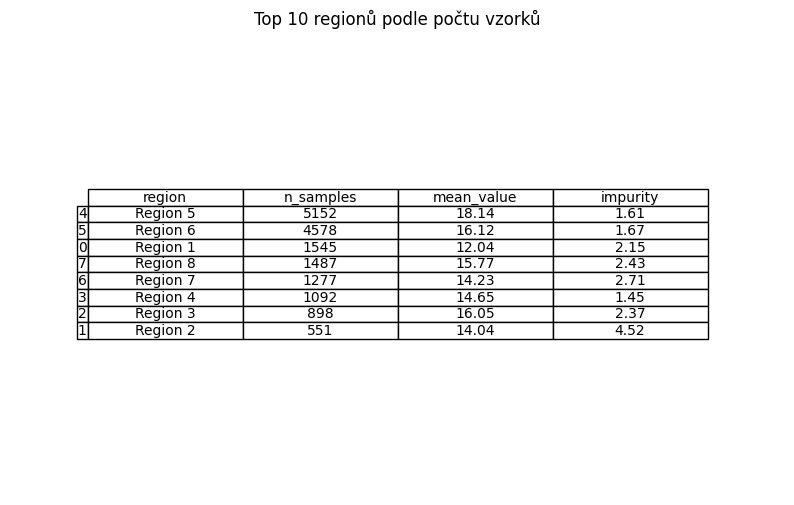

In [124]:
from pandas.plotting import table

# Access the tree structure
tree_ = model1.tree_  # Tree from the model
n_nodes = tree_.node_count
feature_names = X.columns  # Feature names from the dataset

# Collect information about leaf nodes
leaf_nodes = []
region_descriptions = {}  # Region descriptions by ID

for node_id in range(n_nodes):
    # Check if the node is a leaf
    if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:  # Leaf node
        path_conditions = []
        current_node = node_id

        # Traverse back to the root and collect split conditions
        while current_node != 0:
            parent_node = (tree_.children_left == current_node).nonzero()[0][0] \
                if current_node in tree_.children_left else \
                (tree_.children_right == current_node).nonzero()[0][0]
            feature_index = tree_.feature[parent_node]
            threshold = tree_.threshold[parent_node]

            # Adding condition based on direction (left or right child)
            if feature_index != -2 and feature_index < len(feature_names):  # Validating index
                feature_name = feature_names[feature_index]
                if current_node == tree_.children_left[parent_node]:
                    condition = f"{feature_name} <= {threshold:.2f}"
                else:
                    condition = f"{feature_name} > {threshold:.2f}"
                path_conditions.append(condition)
            current_node = parent_node

        # Reverse the conditions so they go from root to leaf
        path_conditions.reverse()
        description = " AND ".join(path_conditions)

        # Saving leaf node information
        region_descriptions[f"Region {len(region_descriptions) + 1}"] = description
        leaf_nodes.append({
            "region": f"Region {len(region_descriptions)}",
            "n_samples": tree_.n_node_samples[node_id],
            "mean_value": tree_.value[node_id][0][0],
            "impurity": tree_.impurity[node_id]
        })

# Converting to DataFrame for analysis
leaf_df = pd.DataFrame(leaf_nodes)

# Selecting top 10 regions by number of samples
top_regions = leaf_df.sort_values("n_samples", ascending=False).head(10)

# Round values to 2 decimal places
top_regions = top_regions.round(2)

# Saving table of top 10 regions (as an image)
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')
table_fig = table(ax, top_regions, loc='center', cellLoc='center', colWidths=[0.2] * len(top_regions.columns))
plt.title("Top 10 Regions by Number of Samples")
plt.savefig("top_10_regions_table.png", bbox_inches='tight', dpi=300)
plt.show()


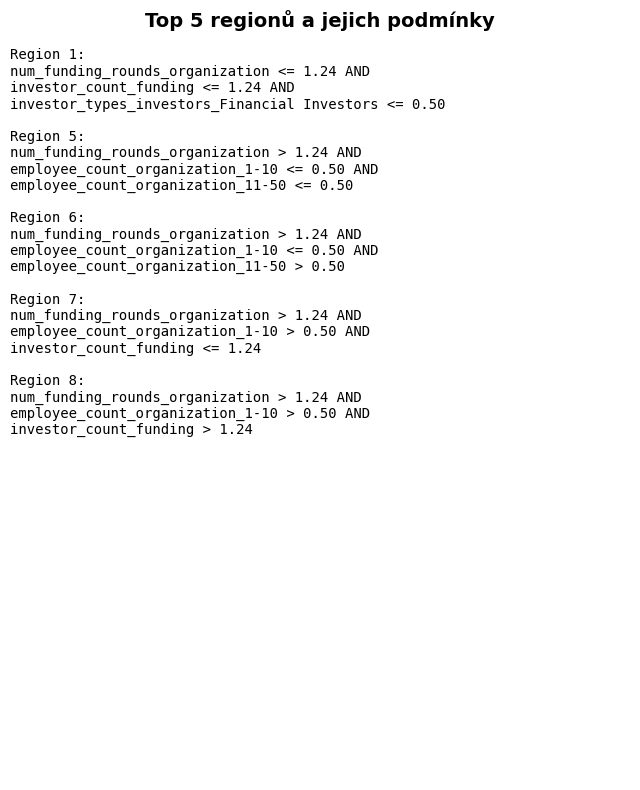

In [125]:
# Accessing tree node information
tree_ = model1.tree_  # Tree from the model
n_nodes = tree_.node_count
feature_names = X.columns  # Feature names from the dataset

# Collecting information about leaf nodes
leaf_nodes = []
region_descriptions = {}  # Region descriptions by ID

for node_id in range(n_nodes):
    # Checking if node is a leaf
    if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:  # Leaf node
        path_conditions = []
        current_node = node_id

        # Traverse back to the root and collect conditions
        while current_node != 0:
            parent_node = (tree_.children_left == current_node).nonzero()[0][0] \
                if current_node in tree_.children_left else \
                (tree_.children_right == current_node).nonzero()[0][0]
            feature_index = tree_.feature[parent_node]
            threshold = tree_.threshold[parent_node]

            # Adding condition based on the direction (left or right child)
            if feature_index != -2 and feature_index < len(feature_names):  # Validate index
                feature_name = feature_names[feature_index]
                if current_node == tree_.children_left[parent_node]:
                    condition = f"{feature_name} <= {threshold:.2f}"
                else:
                    condition = f"{feature_name} > {threshold:.2f}"
                path_conditions.append(condition)
            current_node = parent_node

        # Reverse conditions so they go from root to leaf
        path_conditions.reverse()
        description = " AND\n".join(path_conditions)  # Each "AND" on a new line

        # Save leaf node information
        region_descriptions[f"Region {len(region_descriptions) + 1}"] = description
        leaf_nodes.append({
            "region": f"Region {len(region_descriptions)}",
            "n_samples": tree_.n_node_samples[node_id],
            "mean_value": tree_.value[node_id][0][0],
            "impurity": tree_.impurity[node_id]
        })

# Converting to DataFrame for analysis
leaf_df = pd.DataFrame(leaf_nodes)

# Selecting top 5 regions by number of samples
top_regions = leaf_df.sort_values("n_samples", ascending=False).head(5)

# Creating textual summary of regions and their descriptions
top_region_descriptions = []
for region, description in region_descriptions.items():
    if region in top_regions["region"].values:
        top_region_descriptions.append(f"{region}:\n{description}\n")

# Creating an image with the textual output of region descriptions
fig, ax = plt.subplots(figsize=(8, 10))
ax.axis('off')  # Hide axes
ax.text(0.5, 1, "Top 5 Regions and Their Conditions", ha='center', va='top', fontsize=14, weight='bold')
text_content = "\n".join(top_region_descriptions)
ax.text(0, 0.95, text_content, ha='left', va='top', fontsize=10, wrap=True, family='monospace')

# the result
plt.savefig("top_5_regions_descriptions.png", bbox_inches='tight', dpi=300)
plt.show()


In [126]:
# Number of leaf nodes
num_leaf_nodes = model1.get_n_leaves()
print(f"Number of leaf nodes (terminal regions): {num_leaf_nodes}")


Počet listových uzlů (listových regionů): 8


<Figure size 1500x1200 with 0 Axes>

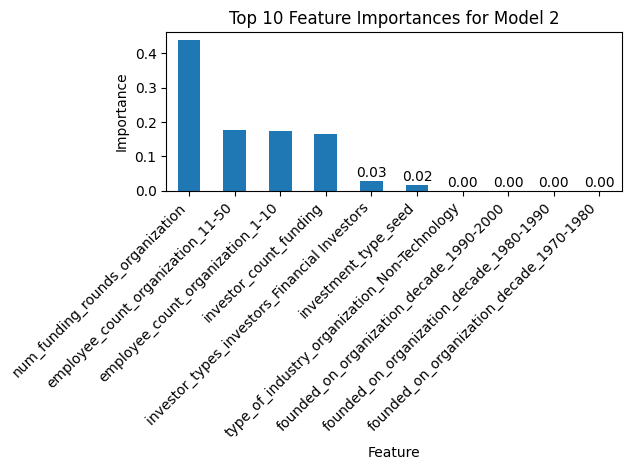

In [127]:
# Creating DataFrame with feature importances and their names for Model 1
features_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances1
}).sort_values(by='Importance', ascending=False)

# feature importances for Model 1- plot
plt.figure(figsize=(15, 12))
top_features_df1 = features_df1.head(10)
ax = top_features_df1.plot(kind='bar', x='Feature', y='Importance', legend=False)

# Adding text labels above the last 6 bars in the chart
for i, v in enumerate(top_features_df1['Importance'].tail(6)):
    ax.text(i + len(top_features_df1) - 6, v + 0.01, f'{v:.2f}', ha='center')

plt.title('Top 10 Feature Importances for Model 2')  # (Optional: change to 'Model 1')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_1_bezgeo.png', bbox_inches='tight')
plt.show()


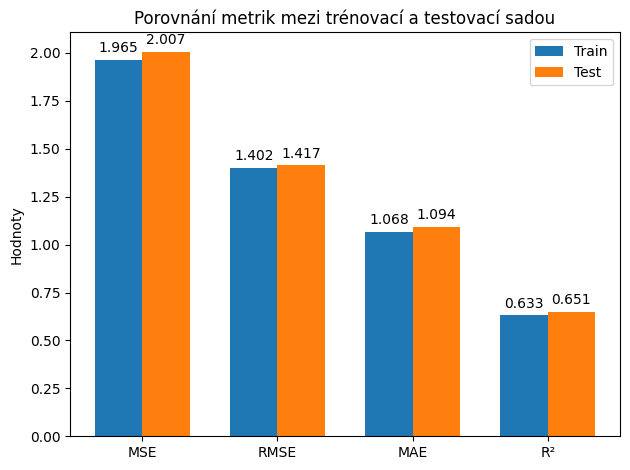

In [128]:
#Metrics for training and testing sets
metrics_train = [mse_train1, rmse_train1, mae_train1, r2_train1]
metrics_test = [mse_test1, rmse_test1, mae_test1, r2_test1]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Hodnoty')
ax.set_title('Porovnání metrik mezi trénovací a testovací sadou')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('metrics_comparison_random_forest_model1_bezgeo.png')
plt.show()

SECOND MODEL WITH ADJUSTED PARAMETERS

Výsledky pro model 2:
{'Model': 'Model 2', 'Params': {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42}, 'MSE Train': 1.407, 'RMSE Train': 1.186, 'MAE Train': 0.899, 'R2 Train': 0.737, 'MSE Test': 1.474, 'RMSE Test': 1.214, 'MAE Test': 0.931, 'R2 Test': 0.743}


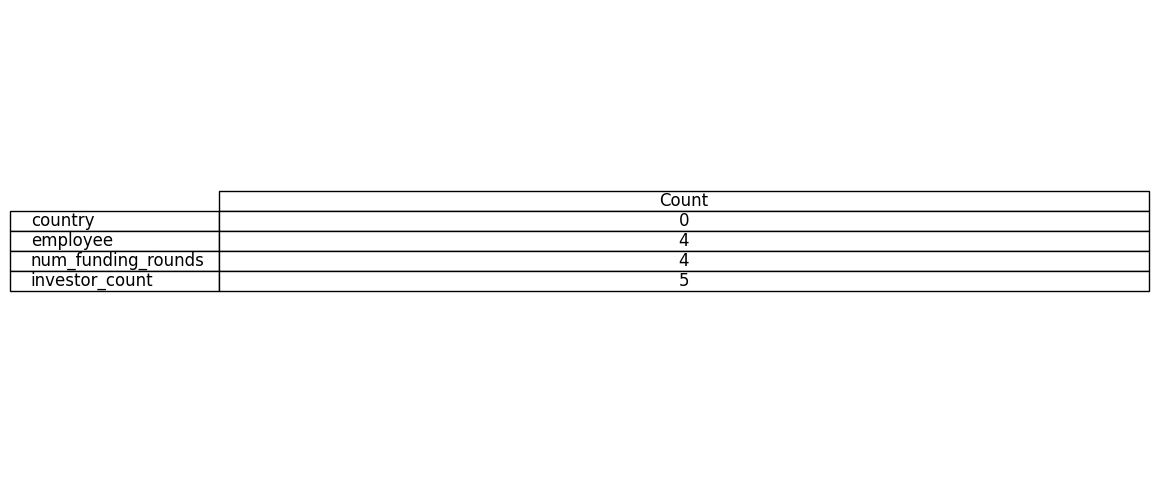

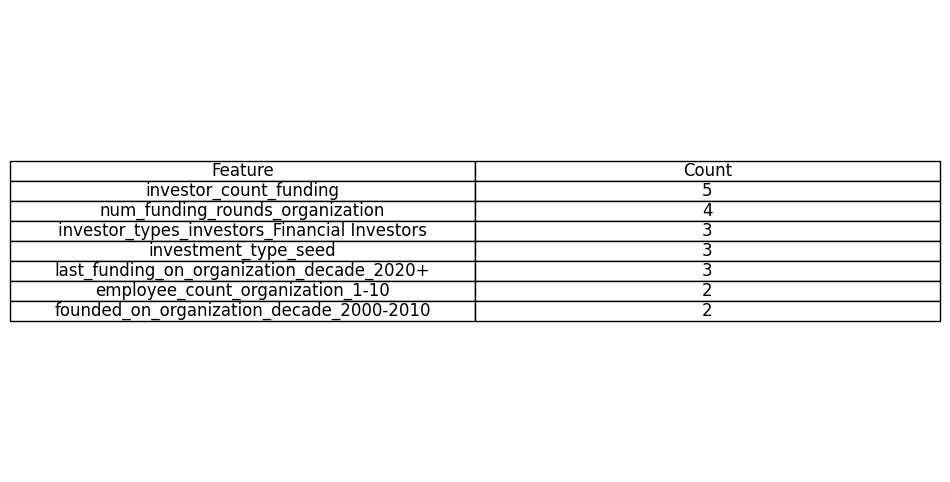

<Figure size 1500x1200 with 0 Axes>

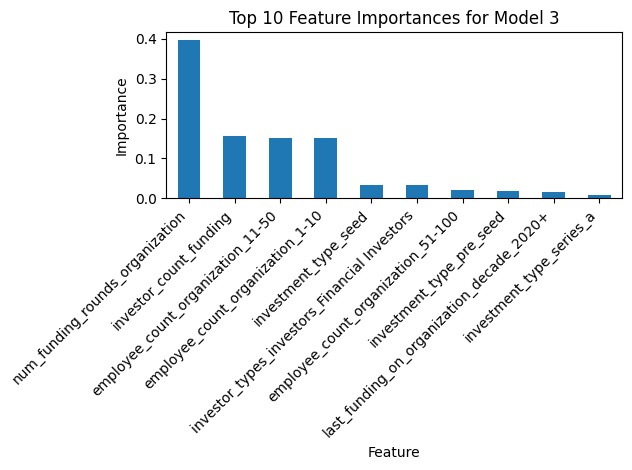

In [129]:
# Parameters for Model 2
params2 = {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42}

# Train Model 2
model2 = DecisionTreeRegressor(**params2).fit(X_train, y_train)

# Predictions on training and test sets
y_train_pred2 = model2.predict(X_train)
y_test_pred2 = model2.predict(X_test)

# Computing metrics for training and test sets
mse_train2 = mean_squared_error(y_train, y_train_pred2)
rmse_train2 = np.sqrt(mse_train2)
mae_train2 = mean_absolute_error(y_train, y_train_pred2)
r2_train2 = r2_score(y_train, y_train_pred2)

mse_train2_rounded = round(mse_train2, 3)
rmse_train2_rounded = round(rmse_train2, 3)
mae_train2_rounded = round(mae_train2, 3)
r2_train2_rounded = round(r2_train2, 3)

mse_test2 = mean_squared_error(y_test, y_test_pred2)
rmse_test2 = np.sqrt(mse_test2)
mae_test2 = mean_absolute_error(y_test, y_test_pred2)
r2_test2 = r2_score(y_test, y_test_pred2)

mse_test2_rounded = round(mse_test2, 3)
rmse_test2_rounded = round(rmse_test2, 3)
mae_test2_rounded = round(mae_test2, 3)
r2_test2_rounded = round(r2_test2, 3)

# Results for Model 2
results2 = {
    'Model': 'Model 2',
    'Params': params2,
    'MSE Train': mse_train2_rounded,
    'RMSE Train': rmse_train2_rounded,
    'MAE Train': mae_train2_rounded,
    'R2 Train': r2_train2_rounded,
    'MSE Test': mse_test2_rounded,
    'RMSE Test': rmse_test2_rounded,
    'MAE Test': mae_test2_rounded,
    'R2 Test': r2_test2_rounded
}

# Printing results for Model 2
print("Results for Model 2:")
print(results2)

# Function to walk the tree and count target feature occurrences
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # Not a leaf node
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Feature importances for Model 2
feature_importances2 = model2.feature_importances_

# Counting target feature occurrences for Model 2
feature_count2, count_dict2 = count_features_in_tree(model2.tree_, X.columns)

# Creating DataFrame with search keyword counts for Model 2
search_features_df2 = pd.DataFrame([count_dict2], index=['Model 2']).T
search_features_df2.columns = ['Count']

# Display keyword count table for Model 2
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df2.values, colLabels=search_features_df2.columns, rowLabels=search_features_df2.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Save keyword count table as image
plt.savefig('search_keywords_count_table_model_2_bezgeo.png', bbox_inches='tight')
plt.show()

# Most frequent features
top_features2 = {k: v for k, v in sorted(feature_count2.items(), key=lambda item: item[1], reverse=True)}

# Creating DataFrame with top features for Model 2
top_features_df2 = pd.DataFrame(list(top_features2.items())[:7], columns=['Feature', 'Count'])

# Display top features table for Model 2
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df2.values, colLabels=top_features_df2.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving top features table as image
plt.savefig('top_features_count_table_model_2.png', bbox_inches='tight')
plt.show()

# Creating DataFrame with feature importances and names for Model 2
features_df2 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances2
}).sort_values(by='Importance', ascending=False)

# Plot-top 10 feature importances for Model 2
plt.figure(figsize=(15, 12))
top_features_df2 = features_df2.head(10)
top_features_df2.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 3')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_2_bezgeo.png', bbox_inches='tight')
plt.show()


In [130]:
# Number of leaf nodes
num_leaf_nodes = model2.get_n_leaves()
print(f"Počet listových uzlů (listových regionů): {num_leaf_nodes}")

Počet listových uzlů (listových regionů): 32


THIRD MODEL WITH ADJUSTED PARAMETERS

Výsledky pro model 3:
{'Model': 'Model 3', 'Params': {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'random_state': 42}, 'MSE Train': 0.822, 'RMSE Train': 0.906, 'MAE Train': 0.681, 'R2 Train': 0.846, 'MSE Test': 1.167, 'RMSE Test': 1.08, 'MAE Test': 0.811, 'R2 Test': 0.797}


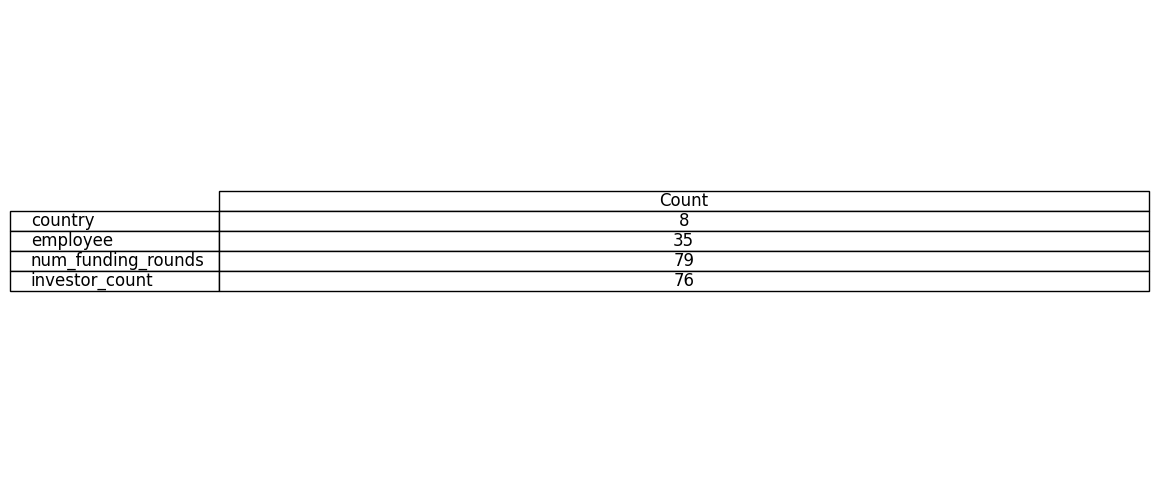

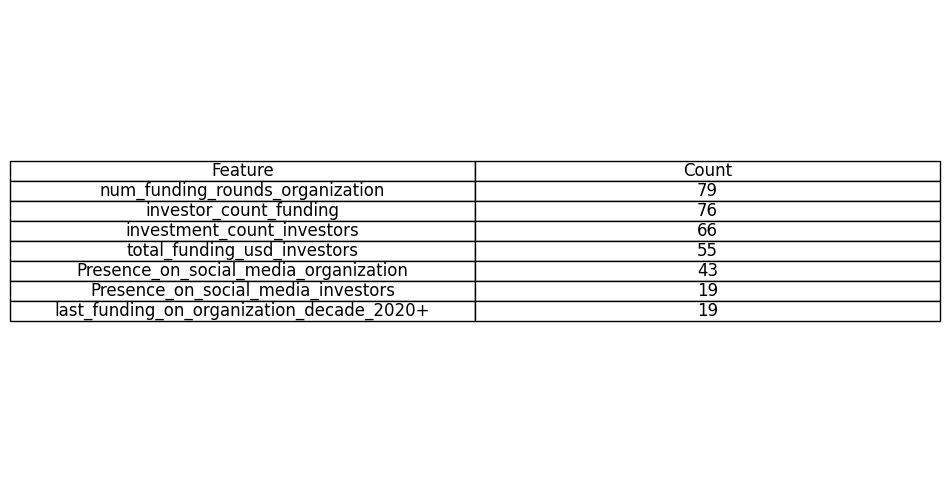

<Figure size 1500x1200 with 0 Axes>

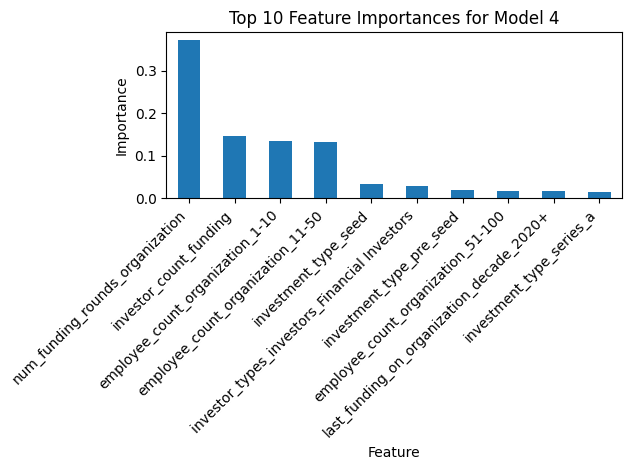

In [131]:
# Parameters for Model 3
params3 = {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'random_state': 42}

# Train Model 3
model3 = DecisionTreeRegressor(**params3).fit(X_train, y_train)

# Predictions on training and test sets
y_train_pred3 = model3.predict(X_train)
y_test_pred3 = model3.predict(X_test)

# Computing metrics for training and test sets
mse_train3 = mean_squared_error(y_train, y_train_pred3)
rmse_train3 = np.sqrt(mse_train3)
mae_train3 = mean_absolute_error(y_train, y_train_pred3)
r2_train3 = r2_score(y_train, y_train_pred3)

mse_train3_rounded = round(mse_train3, 3)
rmse_train3_rounded = round(rmse_train3, 3)
mae_train3_rounded = round(mae_train3, 3)
r2_train3_rounded = round(r2_train3, 3)

mse_test3 = mean_squared_error(y_test, y_test_pred3)
rmse_test3 = np.sqrt(mse_test3)
mae_test3 = mean_absolute_error(y_test, y_test_pred3)
r2_test3 = r2_score(y_test, y_test_pred3)

mse_test3_rounded = round(mse_test3, 3)
rmse_test3_rounded = round(rmse_test3, 3)
mae_test3_rounded = round(mae_test3, 3)
r2_test3_rounded = round(r2_test3, 3)

# Results for Model 3
results3 = {
    'Model': 'Model 3',
    'Params': params3,
    'MSE Train': mse_train3_rounded,
    'RMSE Train': rmse_train3_rounded,
    'MAE Train': mae_train3_rounded,
    'R2 Train': r2_train3_rounded,
    'MSE Test': mse_test3_rounded,
    'RMSE Test': rmse_test3_rounded,
    'MAE Test': mae_test3_rounded,
    'R2 Test': r2_test3_rounded
}

# Print results for Model 3
print("Results for Model 3:")
print(results3)

# Function to traverse the tree and count target features
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # Not a leaf node
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Feature importances for Model 3
feature_importances3 = model3.feature_importances_

# Counting occurrences of target features for Model 3
feature_count3, count_dict3 = count_features_in_tree(model3.tree_, X.columns)

# Creating DataFrame with search keyword counts for Model 3
search_features_df3 = pd.DataFrame([count_dict3], index=['Model 3']).T
search_features_df3.columns = ['Count']

# Display table of keyword counts for Model 3
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df3.values, colLabels=search_features_df3.columns, rowLabels=search_features_df3.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Save keyword count table as image
plt.savefig('search_keywords_count_table_model_3_bezgeo.png', bbox_inches='tight')
plt.show()

# Most frequent features
top_features3 = {k: v for k, v in sorted(feature_count3.items(), key=lambda item: item[1], reverse=True)}

# Creating DataFrame with top features for Model 3
top_features_df3 = pd.DataFrame(list(top_features3.items())[:7], columns=['Feature', 'Count'])

# Display top features table for Model 3
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df3.values, colLabels=top_features_df3.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Save top features table as image
plt.savefig('top_features_count_table_model_3_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating DataFrame with feature importances and names for Model 3
features_df3 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances3
}).sort_values(by='Importance', ascending=False)

# Plot top 10 feature importances for Model 3
plt.figure(figsize=(15, 12))
top_features_df3 = features_df3.head(10)
top_features_df3.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 4')  # (Note: should probably be "Model 3")
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_3_bezgeo.png', bbox_inches='tight')
plt.show()


In [132]:
# Number of leaf nodes
num_leaf_nodes = model3.get_n_leaves()
print(f"Počet listových uzlů (listových regionů): {num_leaf_nodes}")

Počet listových uzlů (listových regionů): 614


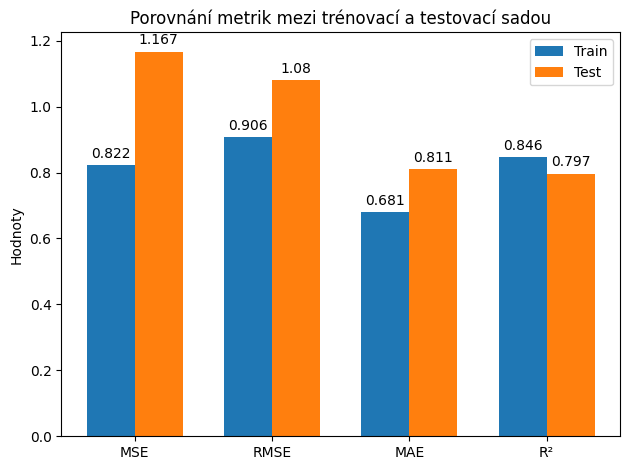

In [133]:
# Metrics for training and testing set
metrics_train = [mse_train3, rmse_train3, mae_train3, r2_train3]
metrics_test = [mse_test3, rmse_test3, mae_test3, r2_test3]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Hodnoty')
ax.set_title('Porovnání metrik mezi trénovací a testovací sadou')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('metrics_comparison_random_forest_model3_bezgeo.png')
plt.show()

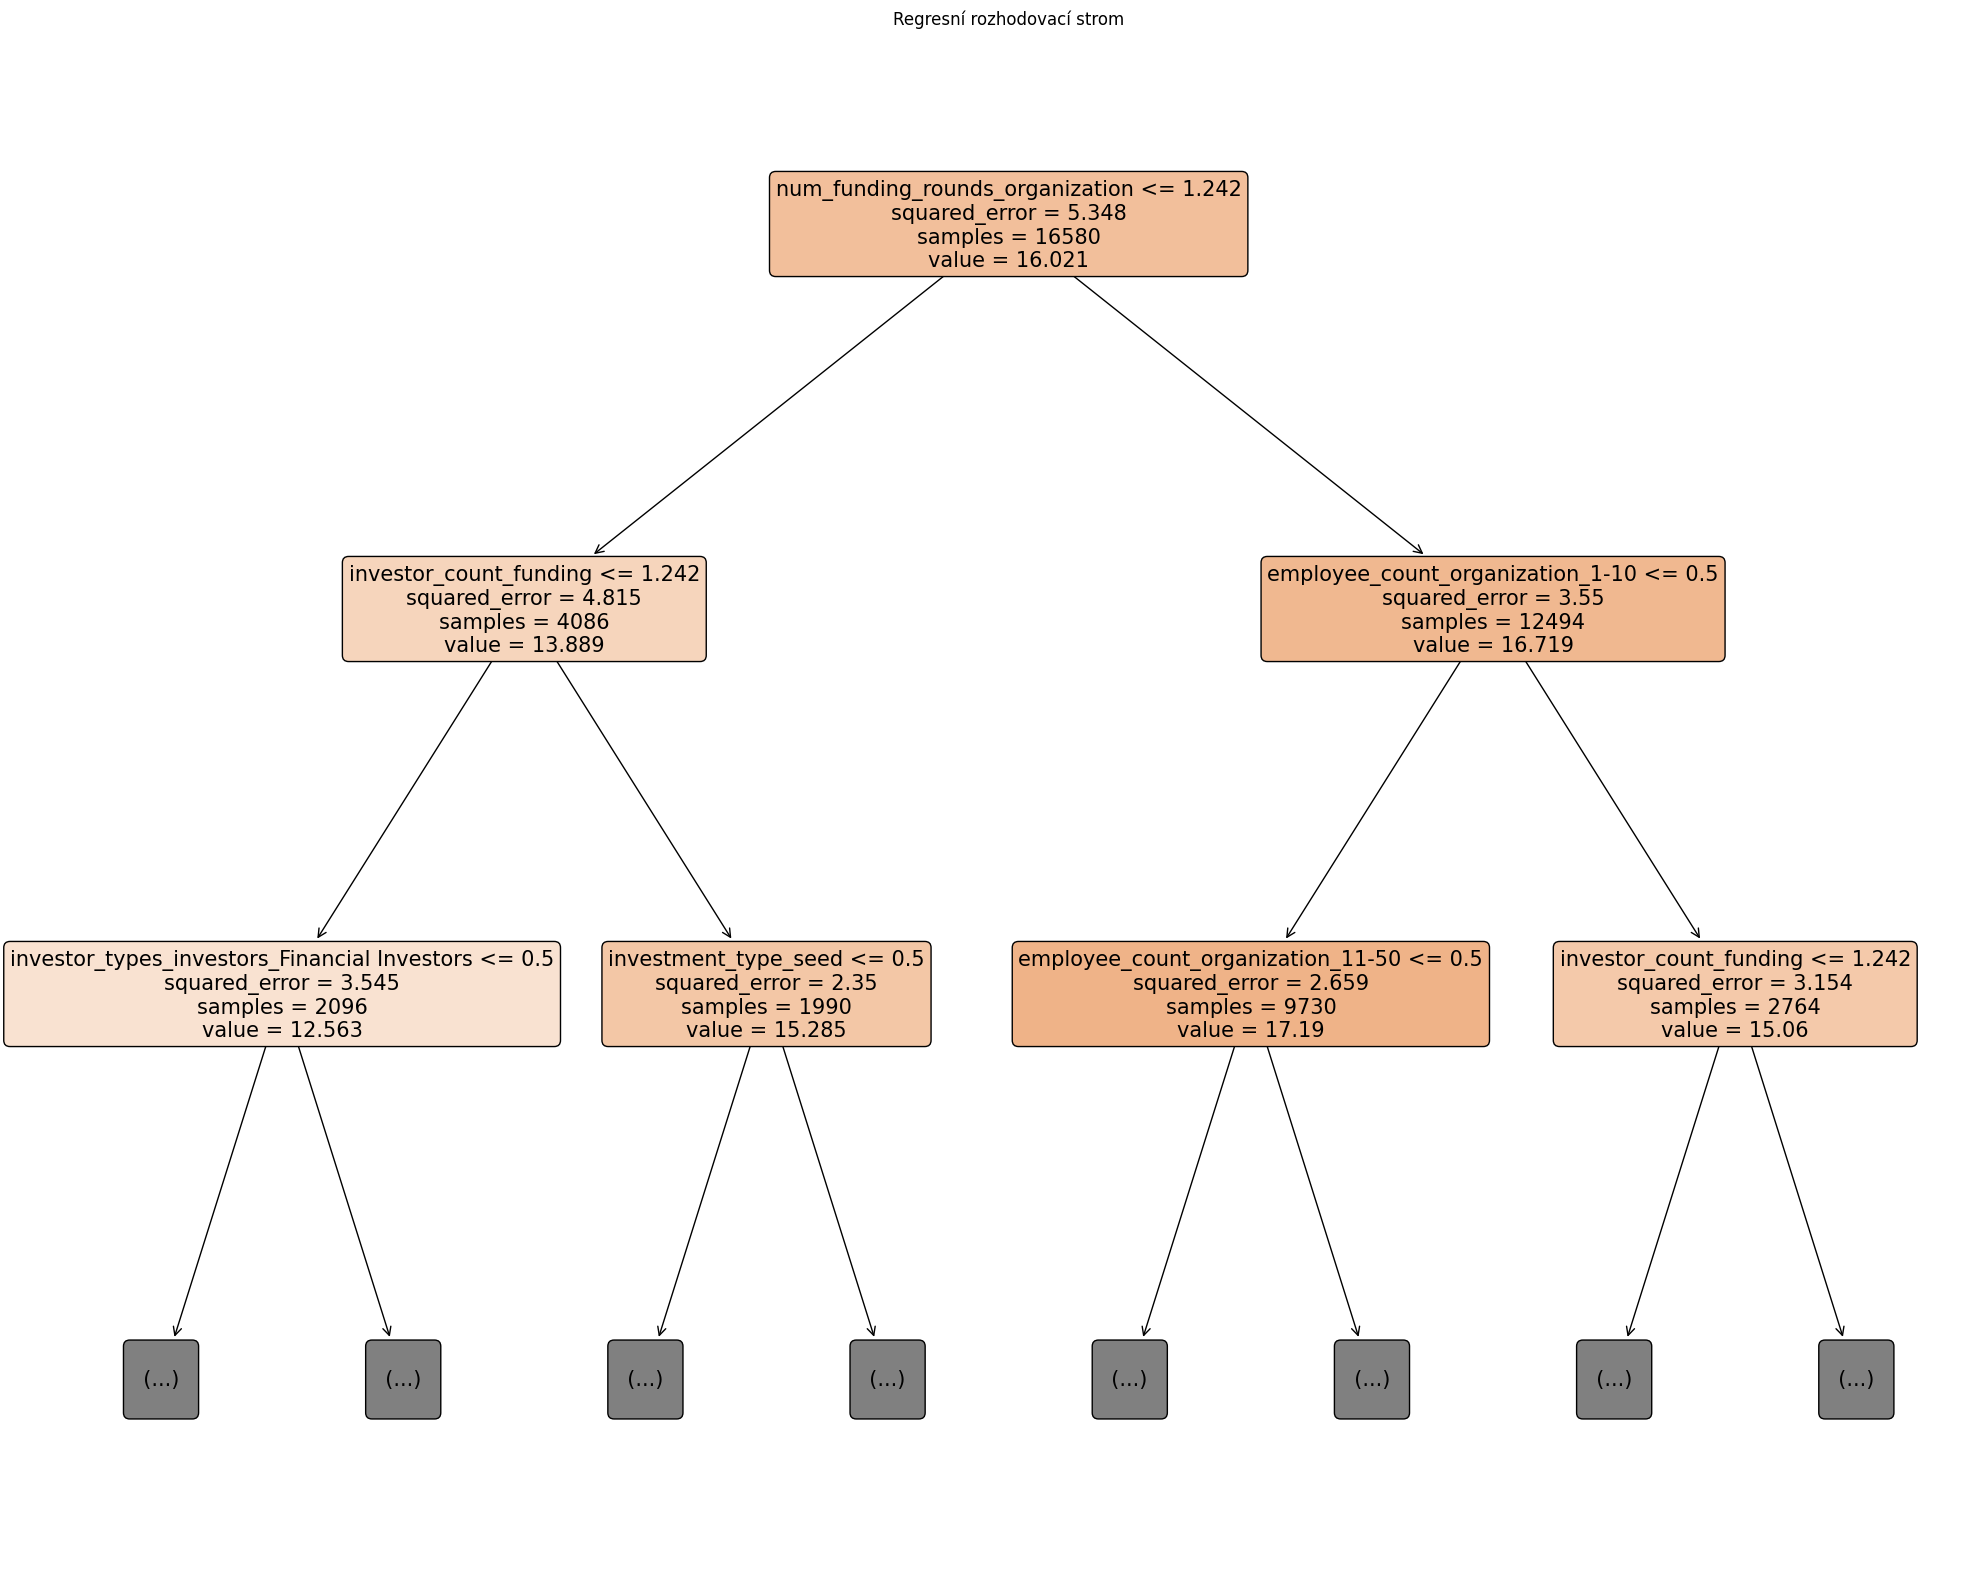

In [134]:
# Tree visualisation
plt.figure(figsize=(25,20))

# Converting pandas Index object to a list

feature_names_list = X_train.columns.tolist()
plot_tree(
    model3,
    max_depth=2,
    feature_names= feature_names_list,
    fontsize=15,
    filled=True,
    rounded=True
)
plt.title("Regresní rozhodovací strom")
plt.savefig('ctvrty_strom.png')
plt.show()

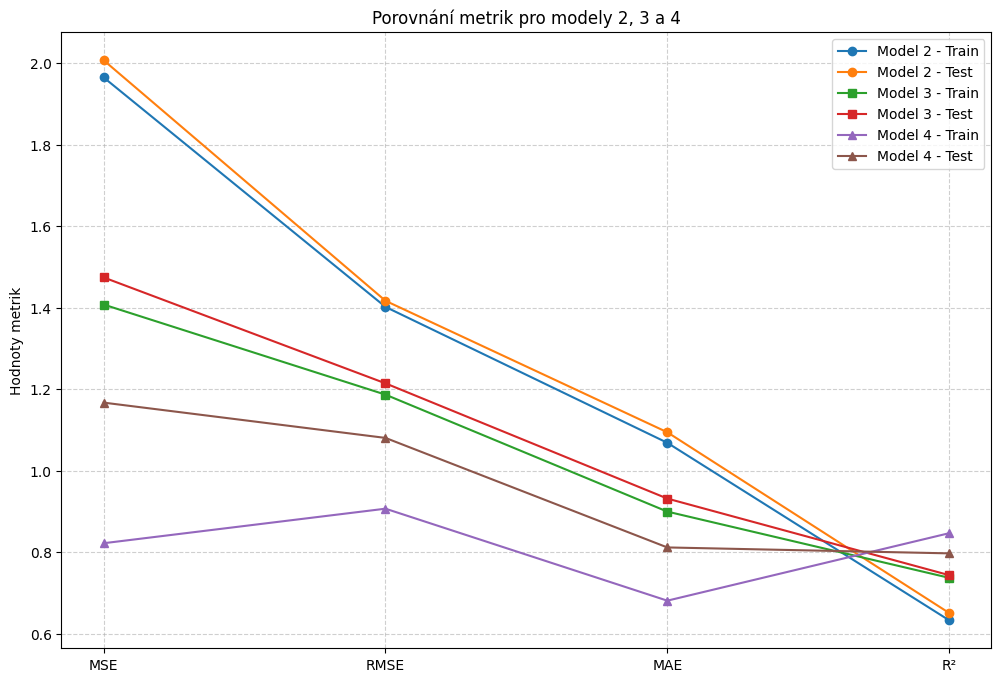

In [135]:
# Defining metrics for each model(already counted above)
metrics_train1 = [mse_train1, rmse_train1, mae_train1, r2_train1]
metrics_test1 = [mse_test1, rmse_test1, mae_test1, r2_test1]

metrics_train2 = [mse_train2, rmse_train2, mae_train2, r2_train2]
metrics_test2 = [mse_test2, rmse_test2, mae_test2, r2_test2]

metrics_train3 = [mse_train3, rmse_train3, mae_train3, r2_train3]
metrics_test3 = [mse_test3, rmse_test3, mae_test3, r2_test3]

# Metric labels
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# X-axis positions for metrics
x = np.arange(len(labels))

plt.figure(figsize=(12, 8))

# Line plots for each model
plt.plot(x, metrics_train1, marker='o', label='Model 2 - Train')
plt.plot(x, metrics_test1, marker='o', label='Model 2 - Test')

plt.plot(x, metrics_train2, marker='s', label='Model 3 - Train')
plt.plot(x, metrics_test2, marker='s', label='Model 3 - Test')

plt.plot(x, metrics_train3, marker='^', label='Model 4 - Train')
plt.plot(x, metrics_test3, marker='^', label='Model 4 - Test')

# Axis settings and legend
plt.xticks(x, labels)
plt.ylabel('Metric Values')
plt.title('Comparison of Metrics for Models 2, 3, and 4')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Saving the chart
plt.savefig('metrics_comparison_models.png', bbox_inches='tight')
plt.show()


CROSS VALIDATION

Mean Squared Error (MSE) for Decision Tree Regressor: 1.69 (+/- 0.06)


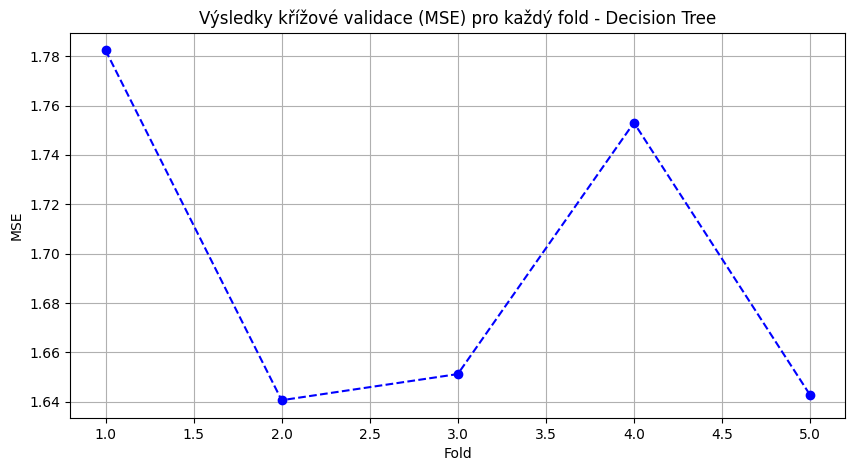

In [136]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold

# Defining cross-validation strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Creating an instance of the decision tree regressor
tree_regressor = DecisionTreeRegressor(random_state=42)

# Applying cross-validation
cv_results_tree = cross_val_score(tree_regressor, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Print mean and standard deviation of the cross-validation scores
print(f"Mean Squared Error (MSE) for Decision Tree Regressor: {-np.mean(cv_results_tree):.2f} (+/- {np.std(cv_results_tree):.2f})")

# Visualization of cross-validation results
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cv_results_tree) + 1), -cv_results_tree, marker='o', linestyle='--', color='b')
plt.title('Cross-Validation Results (MSE) per Fold - Decision Tree')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.grid(True)
plt.savefig('cross_validation_results_decision_tree_bezgeo.png')  # Save the cross-validation chart
plt.show()


In [137]:
# Prediction on the test set
y_test_pred = reg.predict(X_test)

# Computation of metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Print metrics for the test set
print("\nTest set:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')



Testovací sada:
Mean Squared Error (MSE): 1.821
Root Mean Squared Error (RMSE): 1.349
Mean Absolute Error (MAE): 0.954
R-squared (R²): 0.683


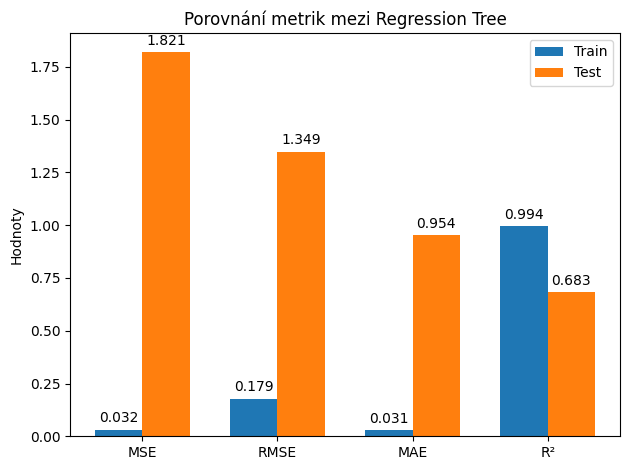

In [138]:
# Metrics visualization
metrics_train = [mse_train, rmse_train, mae_train, r2_train]
metrics_test = [mse_test, rmse_test, mae_test, r2_test]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

ax.set_ylabel('Hodnoty')
ax.set_title('Porovnání metrik mezi Regression Tree')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a label above each bar in each column, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

plt.tight_layout()
plt.savefig('metrics_comparison_regression_tree_bezgeo.png')
plt.show()

In [139]:
# Number of leaf nodes
num_leaf_nodes = reg.get_n_leaves()
print(f"Počet listových uzlů (listových regionů): {num_leaf_nodes}")

Počet listových uzlů (listových regionů): 12602


In [140]:
# Defining metrics for each model
metrics_train_reg = [mse_train, rmse_train, mae_train, r2_train]
metrics_test_reg = [mse_test, rmse_test, mae_test, r2_test]

# Defining metrics for each model (already counted)
metrics_train1 = [mse_train1, rmse_train1, mae_train1, r2_train1]
metrics_test1 = [mse_test1, rmse_test1, mae_test1, r2_test1]

metrics_train2 = [mse_train2, rmse_train2, mae_train2, r2_train2]
metrics_test2 = [mse_test2, rmse_test2, mae_test2, r2_test2]

metrics_train3 = [mse_train3, rmse_train3, mae_train3, r2_train3]
metrics_test3 = [mse_test3, rmse_test3, mae_test3, r2_test3]

# Labels for metrics
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# Creating a DataFrame with all metrics
metrics_data = {
    'Metric': labels,
    'Model 1 - Train': metrics_train_reg,
    'Model 1 - Test': metrics_test_reg,
    'Model 2 - Train': metrics_train1,
    'Model 2 - Test': metrics_test1,
    'Model 3 - Train': metrics_train2,
    'Model 3 - Test': metrics_test2,
    'Model 4 - Train': metrics_train3,
    'Model 4 - Test': metrics_test3,
}

metrics_df = pd.DataFrame(metrics_data)

# Print the table to console
print("\nMetrics comparison table:")
print(metrics_df)

# Saving the table to an Excel file
metrics_df.to_excel('metrics_comparison_models_tree.xlsx', index=False)



Metrics comparison table:
  Metric  Model 1 - Train  Model 1 - Test  Model 2 - Train  Model 2 - Test  \
0    MSE             0.03            1.82             1.96            2.01   
1   RMSE             0.18            1.35             1.40            1.42   
2    MAE             0.03            0.95             1.07            1.09   
3     R²             0.99            0.68             0.63            0.65   

   Model 3 - Train  Model 3 - Test  Model 4 - Train  Model 4 - Test  
0             1.41            1.47             0.82            1.17  
1             1.19            1.21             0.91            1.08  
2             0.90            0.93             0.68            0.81  
3             0.74            0.74             0.85            0.80  


In [141]:
# GRID SEARCH FOR SIMPLE DECISION TREES
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialization of the the GridSearchCV object
grid_search = GridSearchCV(estimator=reg, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fitting the grid search to the training data
grid_search.fit(X_train, y_train)

# Retrieving the best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

# Validation of the best model on the test set
predictions = best_estimator.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"The best parameters are {best_params} with a mean squared error of {mse:.2f}")


The best parameters are {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10} with a mean squared error of 1.166789939475783


In [142]:
best_regressor = grid_search.best_estimator_

# Prediction on the training set
y_train_pred = best_regressor.predict(X_train)

# Computing metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)

# Prediction on the test set
y_test_pred = best_regressor.predict(X_test)

# Computation of the metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Print metrics for the training set
print("Training set:")
print(f"Mean Squared Error (MSE): {mse_train_rounded}")
print(f"Root Mean Squared Error (RMSE): {rmse_train_rounded}")
print(f"Mean Absolute Error (MAE): {mae_train_rounded}")
print(f"R^2 Score: {r2_train_rounded}")

# Print metrics for the test set
print("\nTest set:")
print(f"Mean Squared Error (MSE): {mse_test_rounded}")
print(f"Root Mean Squared Error (RMSE): {rmse_test_rounded}")
print(f"Mean Absolute Error (MAE): {mae_test_rounded}")
print(f"R^2 Score: {r2_test_rounded}")


Trénovací sada:
Mean Squared Error (MSE): 1.821
Root Mean Squared Error (RMSE): 1.349
Mean Absolute Error (MAE): 0.954
R^2 Score: 0.683

Testovací sada:
Mean Squared Error (MSE): 1.167
Root Mean Squared Error (RMSE): 1.08
Mean Absolute Error (MAE): 0.811
R^2 Score: 0.797


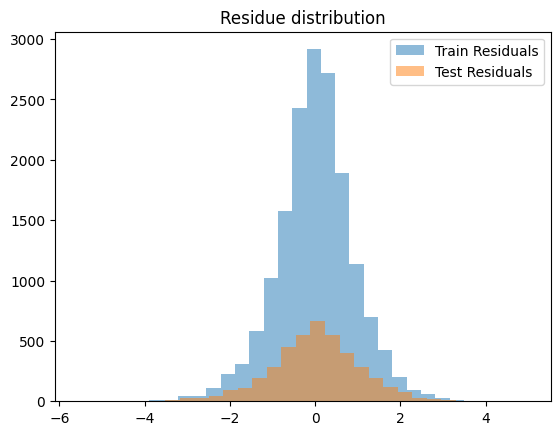

In [143]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.hist(train_residuals, bins=30, alpha=0.5, label='Train Residuals')
plt.hist(test_residuals, bins=30, alpha=0.5, label='Test Residuals')
plt.legend()
plt.title('Residue distribution')
plt.savefig('distribuce.png')
plt.show()

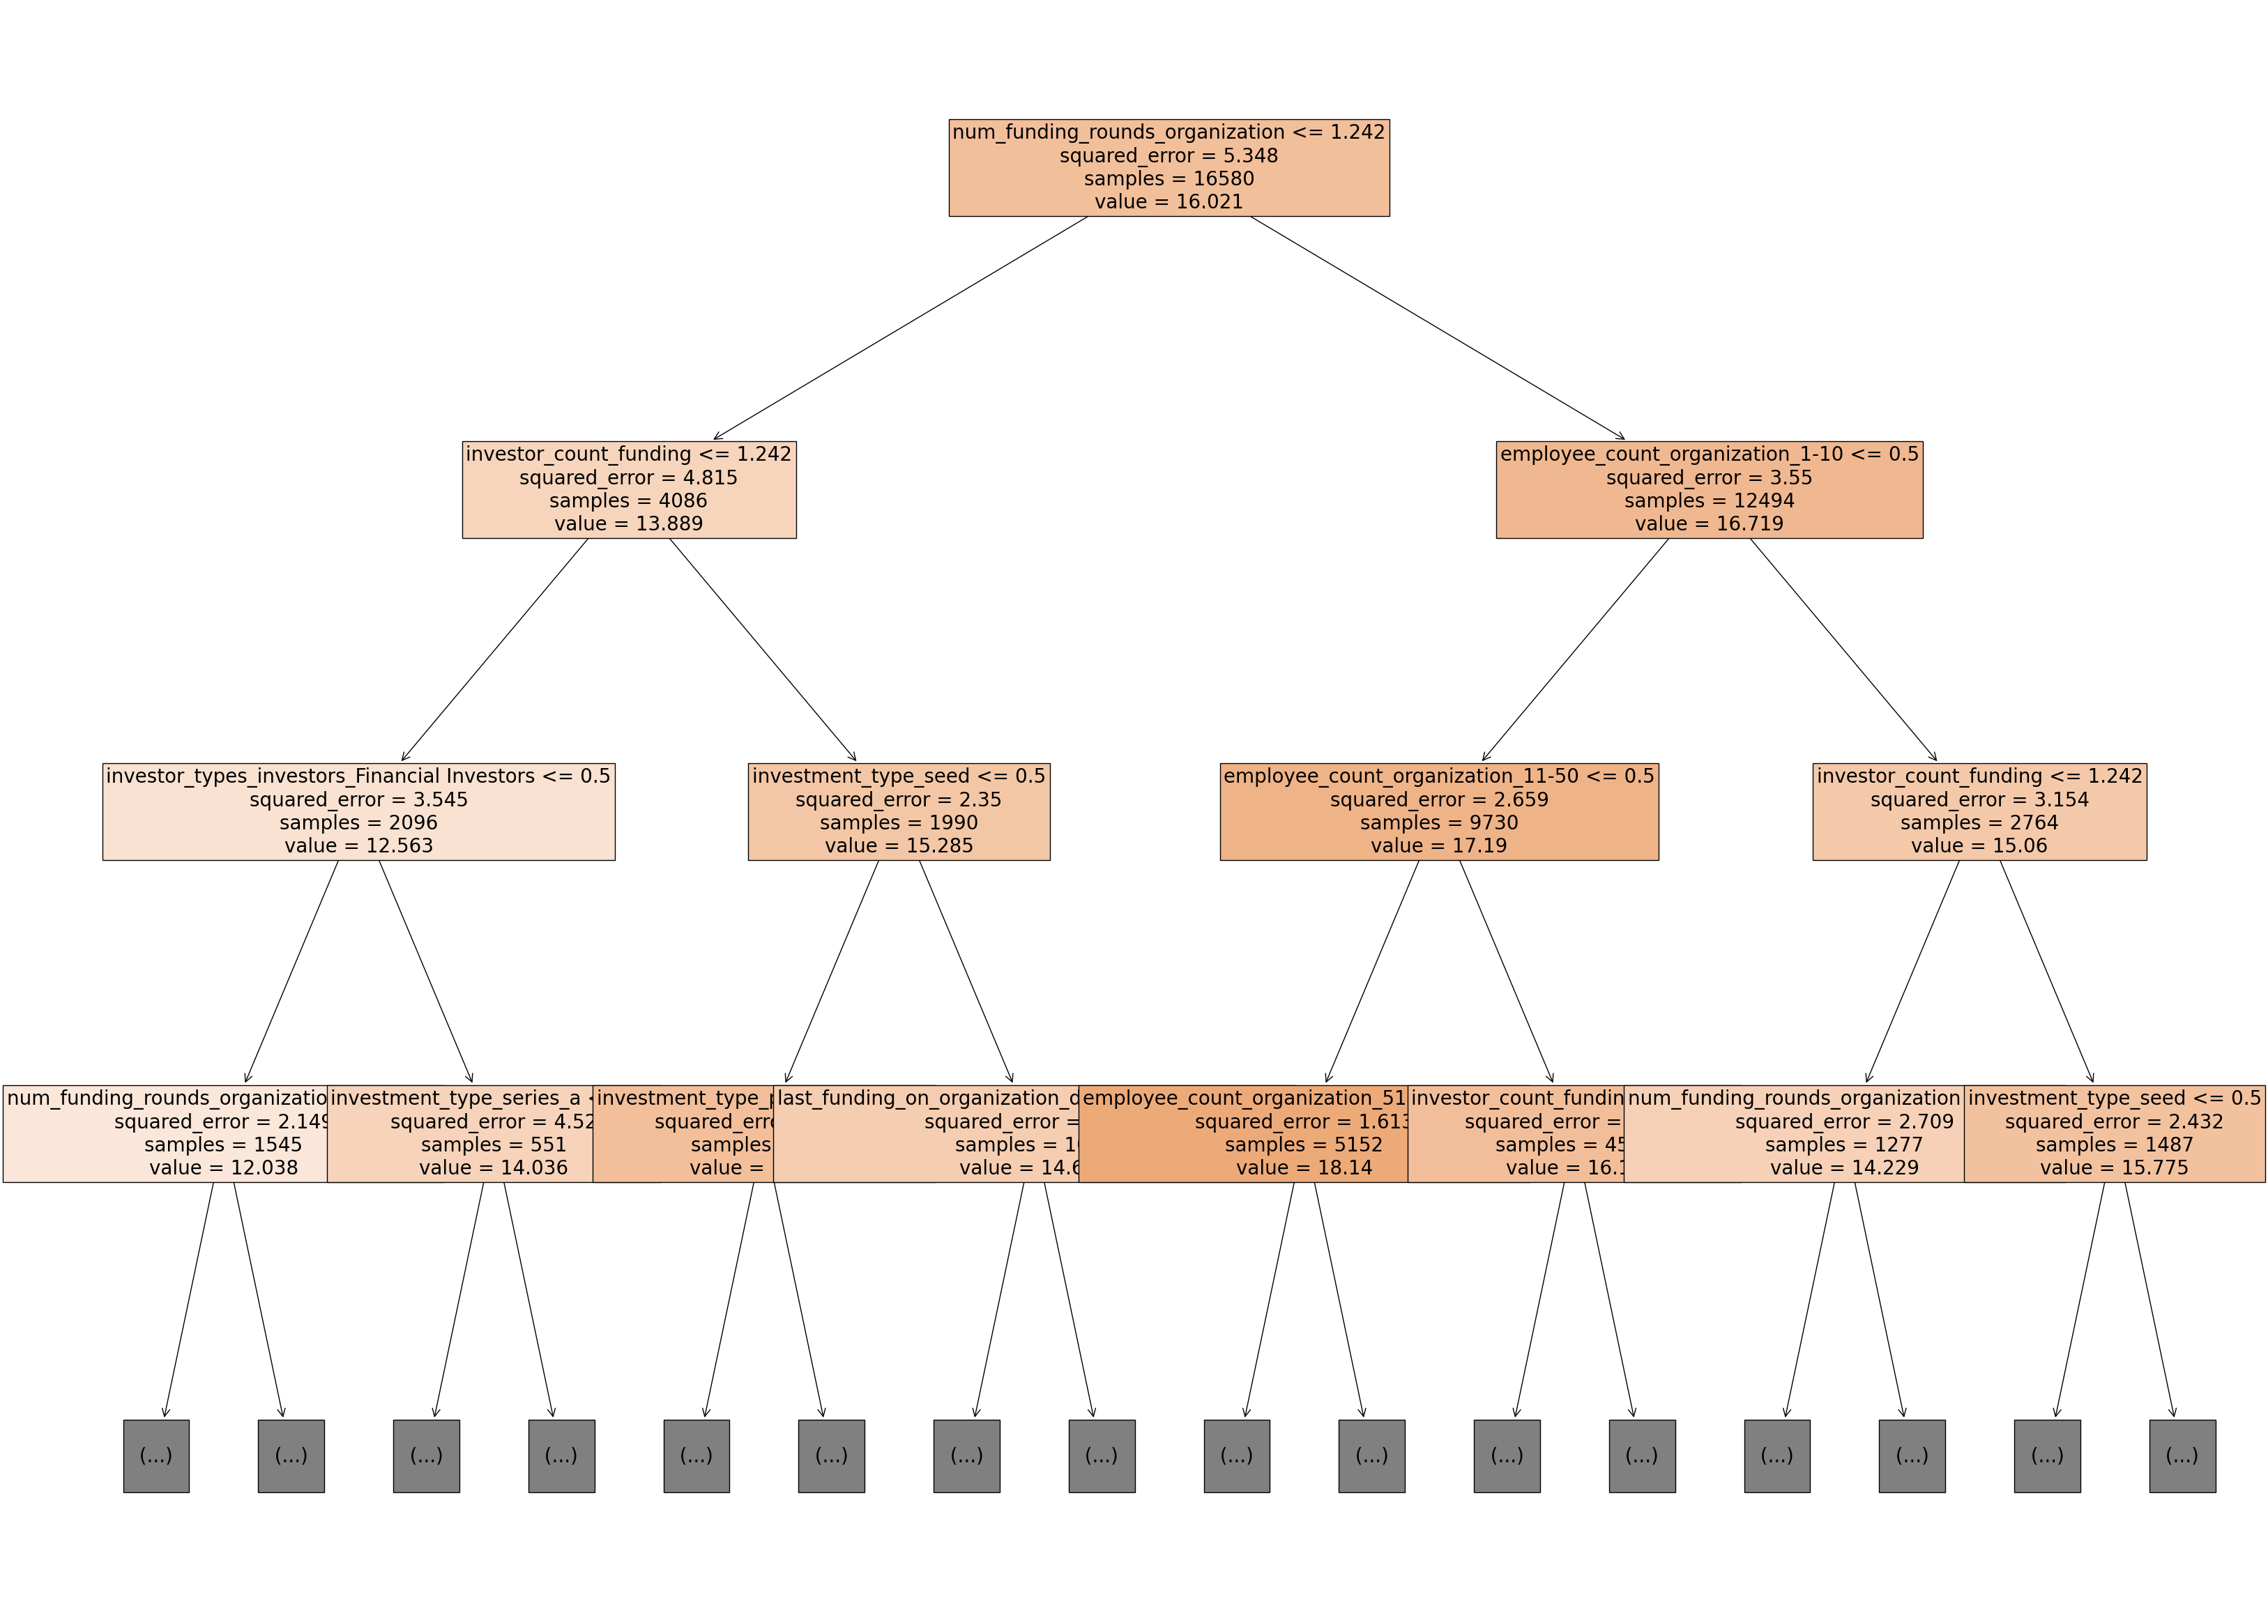

In [144]:
# Increasing the figure size
plt.figure(figsize=(40, 30))

# Converting pandas Index object to a list
feature_names_list = X_train.columns.tolist()

# the tree plot with larger font size
plot_tree(
    best_regressor,
    filled=True,
    feature_names=feature_names_list,
    fontsize=20,  # Increased font size
    max_depth=3   
)

# Saving the plot
plt.savefig('optimized_reg_large.png', bbox_inches='tight')
plt.show()


In [145]:

# Defining the k-fold cross-validation method
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Applying cross-validation
cv_results_tree = cross_val_score(best_regressor, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Output-> the mean and standard deviation of the cross-validation scores
print(f"Mean Squared Error (MSE) for Random Forest Regressor: {-np.mean(cv_results_tree):.2f} (+/- {np.std(cv_results_tree):.2f})")

Mean Squared Error (MSE) for Random Forest Regressor: 1.14 (+/- 0.03)


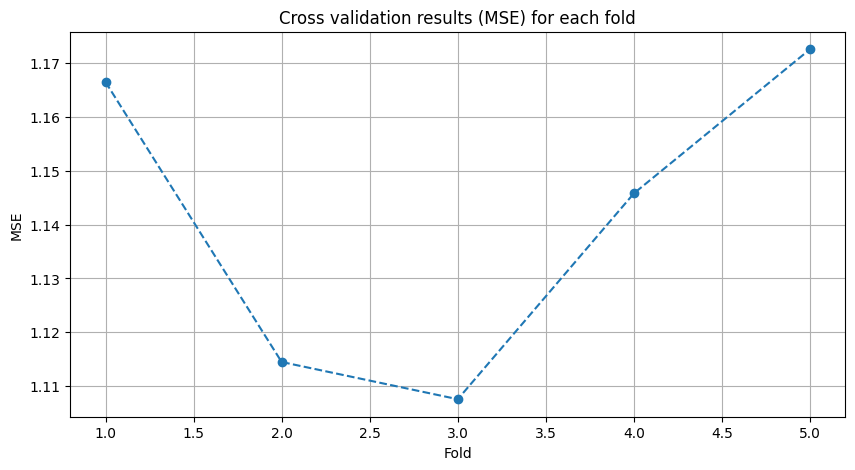

In [146]:
# Vizualization of the cross-validation
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cv_results_tree) + 1), -cv_results_tree, marker='o', linestyle='--')
plt.title('Cross validation results (MSE) for each fold')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.grid(True)
plt.savefig('cross_validation_results_tree_bezgeo.png')
plt.show()


In [147]:
# --- Technology Sector Analysis ---
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Convert feature names to column indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Initialize for cumulative computations
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_leaf_parent_counts = {feature: 0 for feature in geo_features}
geo_parent_nodes_set = set()  # Set to track parent nodes of leaf nodes with geo features

# Node count tracking
total_leaf_nodes = 0            
total_parent_nodes = 0        
total_nodes = 0

# Accessing the tree
tree = best_regressor.tree_
total_nodes += tree.node_count  # Counting all nodes in the tree

# Set for identifying parent nodes
parent_nodes = set()

# Iterating over all nodes in the tree
for node_id in range(tree.node_count):
    # Checking if the node is a leaf
    if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
        total_leaf_nodes += 1

        # Finding the parent node
        parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
        if parent_id.size > 0:
            parent_nodes.add(parent_id[0])
            split_feature = tree.feature[parent_id[0]]

            # Checking if the splitting feature is a geo feature
            if split_feature in geo_feature_indices:
                geo_feature_name = X_train.columns[split_feature]
                geo_leaf_parent_counts[geo_feature_name] += 1
                geo_parent_nodes_set.add(parent_id[0])

total_parent_nodes += len(parent_nodes)

# Counting of unique parent nodes that split on geo features
total_geo_parent_nodes = len(geo_parent_nodes_set)

# Output-> results for geographic features
geo_results = [
    {
        'Feature': feature,
        'Leaf Parent Count': geo_leaf_parent_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# Summary table with node counts
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Saving results to Excel
with pd.ExcelWriter('decision_tree_node_analysis_with_geo.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Leaf Parent Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# Print results
print("\nAnalysis of geographic features in parent nodes of leaves:")
print(geo_results_df)
print("\nSummary of node counts:")
print(summary_df)



Analýza geografických proměnných v rodičovských uzlech listů:
                                    Feature  Leaf Parent Count
0              country_code_organization_US                  0
1          country_code_organization_non-US                  4
2       city_organization_core-startup-city                  7
3   city_organization_non-core-startup-city                  2
4                 country_code_investors_US                  1
5             country_code_investors_non-US                  4
6          city_investors_core-startup-city                  2
7      city_investors_non-core-startup-city                 10
8                   country_code_funding_US                  4
9               country_code_funding_non-US                  0
10           city_funding_core-startup-city                  2
11       city_funding_non-core-startup-city                  0

Souhrnné počty uzlů:
               Metric  Value
0         Total Nodes   1227
1    Total Leaf Nodes    614
2  Total 

<Figure size 1500x1200 with 0 Axes>

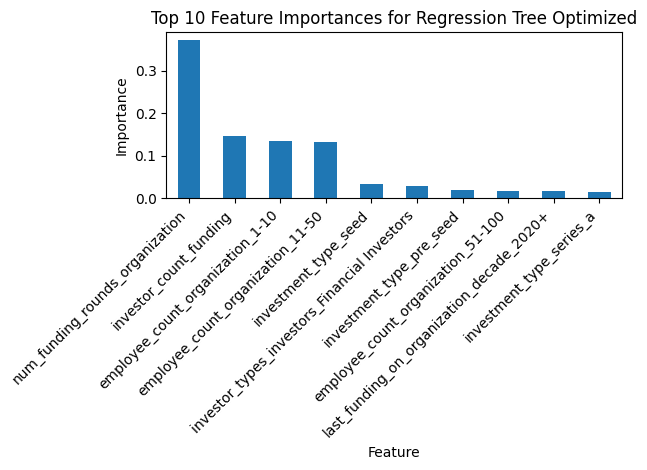

In [148]:
# Getting the feature importances for the best_regressor model
feature_importances_best = best_regressor.feature_importances_

# Creating a DataFrame with feature importances and names for best_regressor
features_df_best = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_best
}).sort_values(by='Importance', ascending=False)

# Selecting the top 10 most important features
top_features_df_best = features_df_best.head(10)

# Plot- feature importances for best_regressor
plt.figure(figsize=(15, 12))
top_features_df_best.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Regression Tree (Optimized)')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_best_regressor.png', bbox_inches='tight')
plt.show()


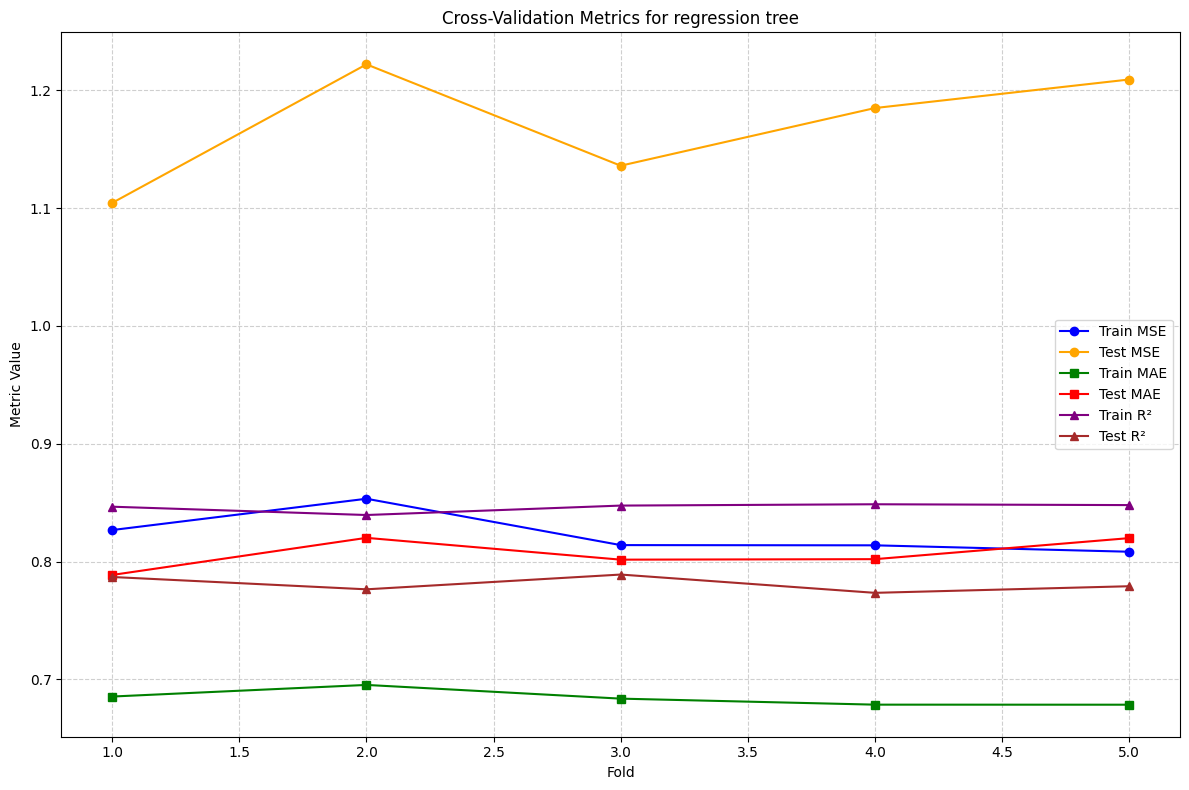

In [149]:
# Defining custom scoring metrics
scoring = {
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

# Performing cross-validation
cv_results = cross_validate(
    best_regressor, X_train, y_train, 
    cv=5, scoring=scoring, return_train_score=True, n_jobs=-1
)

# Extraction of metric values for each fold
train_mse = -cv_results['train_MSE']
test_mse = -cv_results['test_MSE']

train_mae = -cv_results['train_MAE']
test_mae = -cv_results['test_MAE']

train_r2 = cv_results['train_R2']
test_r2 = cv_results['test_R2']

# Creating a line plot
plt.figure(figsize=(12, 8))

# Line plot for MSE
plt.plot(range(1, 6), train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(range(1, 6), test_mse, marker='o', label='Test MSE', color='orange')

# Line plot for MAE
plt.plot(range(1, 6), train_mae, marker='s', label='Train MAE', color='green')
plt.plot(range(1, 6), test_mae, marker='s', label='Test MAE', color='red')

# Line plot for R²
plt.plot(range(1, 6), train_r2, marker='^', label='Train R²', color='purple')
plt.plot(range(1, 6), test_r2, marker='^', label='Test R²', color='brown')

# Plot - settings
plt.xlabel('Fold')
plt.ylabel('Metric Value')
plt.title('Cross-Validation Metrics for Regression Tree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Saving the plot
plt.savefig('basic_tree_cross_validation_line_plot.png', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


RANDOM FORESTS STANDARD

In [150]:
from sklearn.ensemble import RandomForestRegressor

# Creating an instance of Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Training the model on the training data
rf_regressor.fit(X_train, y_train)

# Making predictions on the training set
y_train_pred = rf_regressor.predict(X_train)

# Computing metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)

# Printing training set metrics
print("Training set:")
print(f'Mean Squared Error (MSE): {mse_train_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_train_rounded}')
print(f'Mean Absolute Error (MAE): {mae_train_rounded}')
print(f'R-squared (R²): {r2_train_rounded}')


Trénovací sada:
Mean Squared Error (MSE): 0.154
Root Mean Squared Error (RMSE): 0.392
Mean Absolute Error (MAE): 0.274
R-squared (R²): 0.971


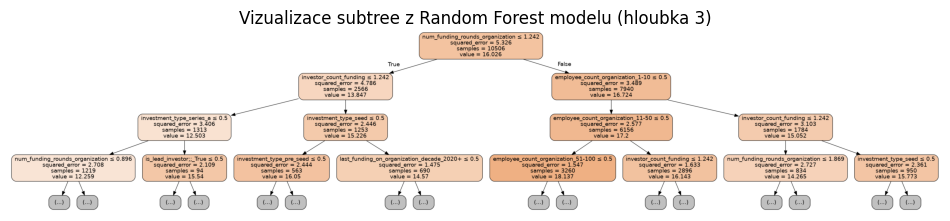

In [151]:
from sklearn.tree import export_graphviz
from subprocess import call

# Choosing the index of the tree to visualize
tree_index = 0

# Getting an individual tree from the Random Forest model
tree = rf_regressor.estimators_[tree_index]

# Setting the maximum depth of the tree you want to visualize
max_depth = 3

# Exporting only the subtree to a DOT file
export_graphviz(
    tree,
    out_file="subtree.dot",
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=max_depth
)

# Converting the DOT file to a PNG image
call(['dot', '-Tpng', 'subtree.dot', '-o', 'subtree.png'])

# Displaying the resulting visualization
plt.figure(figsize=(12, 12))
plt.imshow(plt.imread('subtree.png'))
plt.axis('off')
plt.title(f"Subtree visualization from Random Forest model (depth {max_depth})")
plt.show()


<Figure size 1500x1200 with 0 Axes>

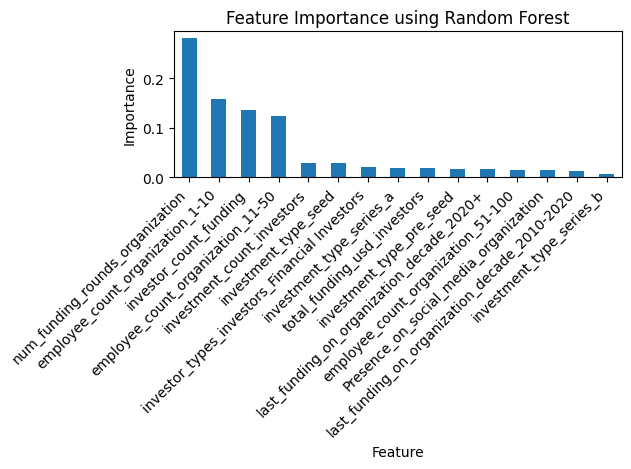

In [152]:
# Creating a DataFrame with feature importances and their names
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting a feature importances
plt.figure(figsize=(15, 12))
top_features_df = features_df.head(15)
top_features_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance using Random Forest')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)

plt.xticks(rotation=45, ha='right')  # Slight rotation and alignment of labels
plt.tight_layout()

plt.savefig('new_feature_importance_velke_random_les_bezgeo.png', bbox_inches='tight')
plt.show()


In [153]:
# Prediction on the test data
y_pred = rf_regressor.predict(X_test)

# Computation of the metrics for the test set
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Print metrics for the test set
print("\nTest set:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')



Testovací sada:
Mean Squared Error (MSE): 0.981
Root Mean Squared Error (RMSE): 0.99
Mean Absolute Error (MAE): 0.728
R-squared (R²): 0.829


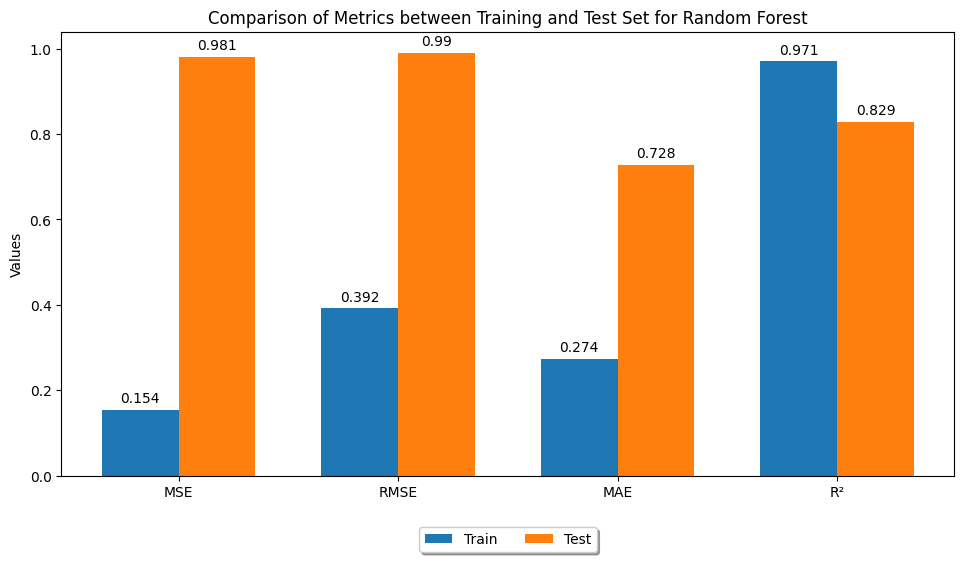

In [154]:
# Metrics for training and test sets
metrics_train = [mse_train, rmse_train, mae_train, r2_train]
metrics_test = [mse_test, rmse_test, mae_test, r2_test]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding labels, title, and custom tick labels
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics between Training and Test Set for Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=2)  # Legend below the plot

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout(pad=2.0)  # Adjusting padding to prevent overlap
plt.savefig('metrics_comparison_random_forest_bezgeo_vychozi.png')
plt.show()


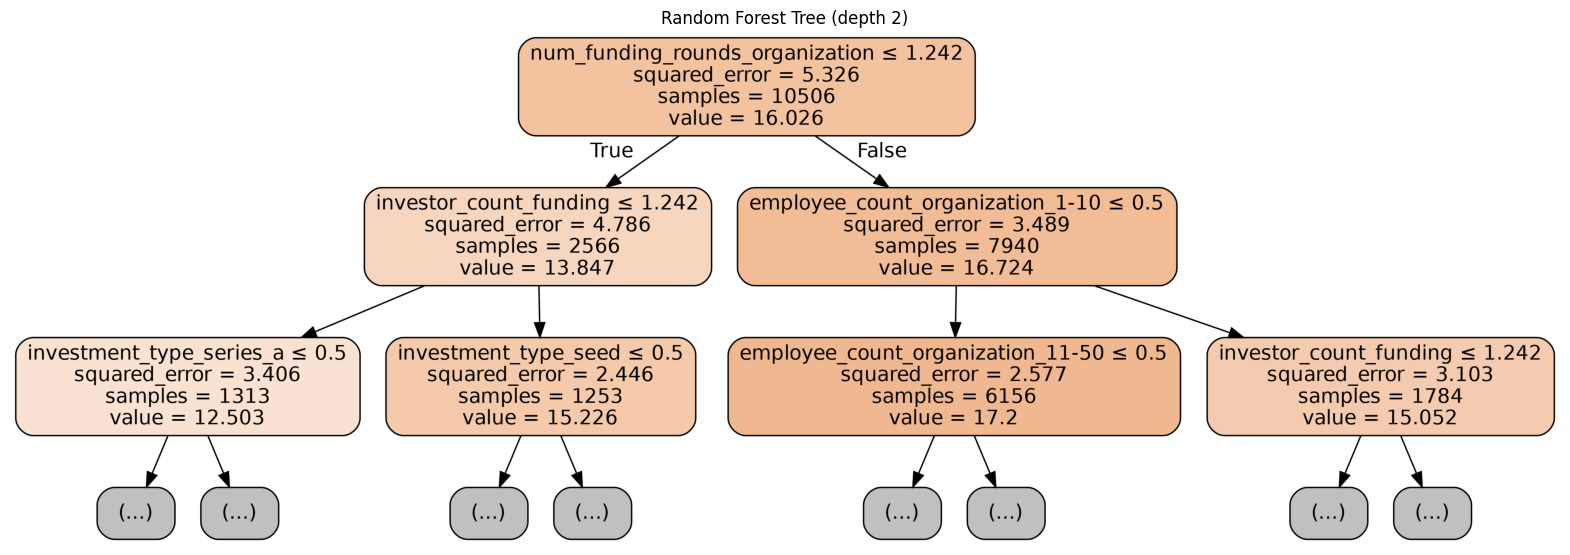

In [155]:
# Index of the tree to visualize
tree_index = 0

# Extracting a single tree from the Random Forest model
tree = rf_regressor.estimators_[tree_index]

# Depth of the tree to visualize
max_depth = 2

# Exporting only a subtree to a DOT file
export_graphviz(
    tree,
    out_file="subtree.dot",
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=max_depth
)

# Converting the DOT file to a PNG image with higher DPI for better resolution
call(['dot', '-Tpng', 'subtree.dot', '-o', 'subtree.png', '-Gdpi=300'])

# Displaying the resulting visualization
plt.figure(figsize=(20, 20))
plt.imshow(plt.imread('subtree.png'))
plt.axis('off')
plt.title(f"Random Forest Tree (depth {max_depth})")
plt.savefig('randomforest_highres.png', bbox_inches='tight', dpi=300)  # Save with higher resolution
plt.show()


In [156]:
# Individual tree from the Random Forest model
tree = rf_regressor.estimators_[tree_index].tree_

# Initialization variables to accumulate values of leaf nodes
left_leaf_values = []
right_leaf_values = []

# Iteration over all nodes in the tree
for node_id in range(tree.node_count):
    # Checking if the node is a leaf (has no children)
    if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
        # Getting the prediction value at the leaf node (average prediction)
        leaf_value = tree.value[node_id][0][0]
        
        # Determination if the node belongs to the left or right branch of the root
        if node_id in tree.children_left:
            left_leaf_values.append(leaf_value)
        elif node_id in tree.children_right:
            right_leaf_values.append(leaf_value)

# Calculation average values for left and right leaf branches
average_left_leaf_value = np.mean(left_leaf_values) if left_leaf_values else None
average_right_leaf_value = np.mean(right_leaf_values) if right_leaf_values else None

# Printing results
print(f"Average value of leaf nodes in the left branch: {average_left_leaf_value}")
print(f"Average value of leaf nodes in the right branch: {average_right_leaf_value}")


Průměrná hodnota listových uzlů v levé větvi: 16.07419280856198
Průměrná hodnota listových uzlů v pravé větvi: 16.130389589503448


In [157]:
# Individual tree from the Random Forest model
tree = rf_regressor.estimators_[tree_index].tree_

# List to store information about leaf nodes
leaf_nodes_info = []

# Iteration through all nodes in the tree
for node_id in range(tree.node_count):
    # Checking if the node is a leaf
    if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
        # Value of the leaf node
        node_value = tree.value[node_id][0][0]
        
        # Finding the feature that led to the split (from the parent node)
        parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
        if len(parent_id) > 0:
            parent_id = parent_id[0]
            feature_index = tree.feature[parent_id]
            feature_name = X_train.columns[feature_index] if feature_index != -2 else "No Feature"
        else:
            feature_name = "No Feature"
        
        # Storing leaf node information
        leaf_nodes_info.append({
            'Node_ID': node_id,
            'Feature': feature_name,
            'Value': node_value
        })

# Sorting leaf nodes by their prediction value (descending)
leaf_nodes_info = sorted(leaf_nodes_info, key=lambda x: x['Value'], reverse=True)

# Selecting the top 10 leaf nodes with the highest value
top_10_leaf_nodes = leaf_nodes_info[:10]

# Printing the top 10 leaf nodes
print("Top 10 leaf nodes with the highest prediction value:")
for node in top_10_leaf_nodes:
    print(f"Node ID: {node['Node_ID']}, Feature: {node['Feature']}, Value: {node['Value']}")


Prvních 10 listových uzlů s nejvyšší hodnotou:
Node ID: 6042, Feature: Presence_on_social_media_investors, Value: 23.44490546917194
Node ID: 6149, Feature: investment_count_investors, Value: 23.439204839535
Node ID: 6150, Feature: investment_count_investors, Value: 23.439204839535
Node ID: 5610, Feature: employee_count_organization_251-500, Value: 21.975171295313608
Node ID: 5821, Feature: is_lead_investor;;_undifferentiated, Value: 21.498453728303183
Node ID: 5850, Feature: num_funding_rounds_organization, Value: 21.498453728303183
Node ID: 5886, Feature: investment_type_series_a, Value: 21.418737833526194
Node ID: 5688, Feature: investor_count_funding, Value: 21.415912892964926
Node ID: 5376, Feature: type_of_industry_organization_Non-Technology, Value: 21.365119723645122
Node ID: 5798, Feature: num_funding_rounds_organization, Value: 21.364593269303153


In [158]:
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_leaf_counts_total = 0  # Total number of leaf nodes with geographic features as the last split

# Iteration through all trees in the Random Forest
for estimator in rf_regressor.estimators_:
    tree = estimator.tree_

    # Iteration through all nodes in the tree
    for node_id in range(tree.node_count):
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:  # Leaf node
            # Checking whether the last split before the leaf was on a geographic feature
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if len(parent_id) > 0:
                parent_id = parent_id[0]
                split_feature = tree.feature[parent_id]
                if split_feature in geo_feature_indices:
                    geo_leaf_counts_total += 1

print(f"Number of leaf nodes in the forest with geographic features as the last split: {geo_leaf_counts_total}")


Počet listových uzlů v lese s geografickými atributy: 177153


In [159]:
from sklearn.tree import export_graphviz

# Individual tree from the Random Forest model
tree = rf_regressor.estimators_[tree_index].tree_

# Initialization of variables to accumulate values of nodes
left_branch_values = []
right_branch_values = []

# Iteration through all nodes in the tree
for node_id in range(tree.node_count):
    # Getting the value (average prediction at the node)
    node_value = tree.value[node_id][0][0]
    
    # Determination whether the node belongs to the left or right branch of the root
    if node_id in tree.children_left:
        left_branch_values.append(node_value)
    elif node_id in tree.children_right:
        right_branch_values.append(node_value)

# Calculation average values for left and right branches
average_left_branch_value = np.mean(left_branch_values) if left_branch_values else None
average_right_branch_value = np.mean(right_branch_values) if right_branch_values else None

# Printing the results
print(f"Average value of nodes in the left branch: {average_left_branch_value}")
print(f"Average value of nodes in the right branch: {average_right_branch_value}")


Průměrná hodnota uzlů v levé větvi: 16.10265095178935
Průměrná hodnota uzlů v pravé větvi: 16.114282105115432


In [160]:
from sklearn.model_selection import cross_val_score, KFold
# Defining the k-fold cross-validation method
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Applying cross-validation
cv_results_forest = cross_val_score(rf_regressor, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Output->the mean and standard deviation of the cross-validation scores
print(f"Mean Squared Error (MSE) for Random Forest Regressor: {-np.mean(cv_results_forest):.2f} (+/- {np.std(cv_results_forest):.2f})")

Mean Squared Error (MSE) for Random Forest Regressor: 0.93 (+/- 0.04)


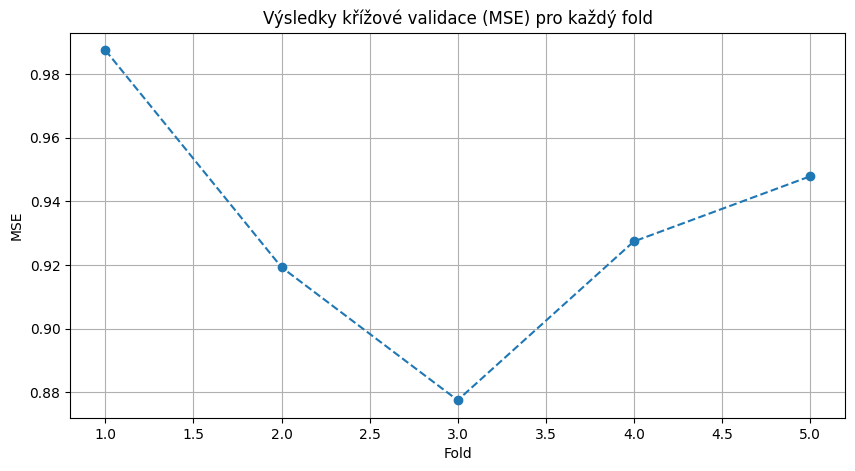

In [161]:
# Cross-validation visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cv_results_forest) + 1), -cv_results_forest, marker='o', linestyle='--')
plt.title('Cross-Validation Results (MSE) for Each Fold')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.grid(True)
plt.savefig('cross_validation_results_forest_bezgeo.png')
plt.show()


In [162]:
# Technology sector analysis
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Converting names to column indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Initialization for cumulative calculations across all trees
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_leaf_parent_counts = {feature: 0 for feature in geo_features}
geo_parent_nodes_set = set()  # Set to track parent nodes of leaves split by geo features

# Node counters
total_leaf_nodes = 0    
total_parent_nodes = 0 
total_nodes = 0

# Iteration through all trees in the Random Forest Regressor
for estimator in rf_regressor.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count

    parent_nodes = set()

    # Iteration through all nodes in the tree
    for node_id in range(tree.node_count):
        # Check if the node is a leaf
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
            total_leaf_nodes += 1

            # Finding the parent node
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if parent_id.size > 0:
                parent_nodes.add(parent_id[0])

                split_feature = tree.feature[parent_id[0]]

                # Checking if the splitting feature is geographic
                if split_feature in geo_feature_indices:
                    geo_feature_name = X_train.columns[split_feature]
                    geo_leaf_parent_counts[geo_feature_name] += 1
                    geo_parent_nodes_set.add(parent_id[0])

    total_parent_nodes += len(parent_nodes)

# Counting of unique parent nodes with geographic split features
total_geo_parent_nodes = len(geo_parent_nodes_set)

# Output -> results for geographic features
geo_results = [
    {
        'Feature': feature,
        'Leaf Parent Count': geo_leaf_parent_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# Summary table of node counts
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Saving results to Excel
with pd.ExcelWriter('rf_regressor_node_analysis_with_geo.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Leaf Parent Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# Printing the results
print("\nAnalysis of geographic features in parent nodes of leaves:")
print(geo_results_df)
print("\nSummary of node counts:")
print(summary_df)



Analýza geografických proměnných v rodičovských uzlech listů:
                                    Feature  Leaf Parent Count
0              country_code_organization_US               6999
1          country_code_organization_non-US               6811
2       city_organization_core-startup-city              23747
3   city_organization_non-core-startup-city              24239
4                 country_code_investors_US               5322
5             country_code_investors_non-US               5371
6          city_investors_core-startup-city              21801
7      city_investors_non-core-startup-city              21211
8                   country_code_funding_US               6832
9               country_code_funding_non-US               6768
10           city_funding_core-startup-city              24423
11       city_funding_non-core-startup-city              23629

Souhrnné počty uzlů:
               Metric    Value
0         Total Nodes  1881046
1    Total Leaf Nodes   940573
2  

In [163]:
# Technology sector analysis

tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Converting names to indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Identification geographic features
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_parent_node_counts = {feature: 0 for feature in geo_features}  # Counting of parent nodes for each geo feature
geo_parent_nodes_set = set()  # Unique geo parent node IDs

# Counters for all nodes
total_leaf_nodes = 0
total_parent_nodes = 0
total_nodes = 0

# Iteration through all trees in the Random Forest Regressor
for estimator in rf_regressor.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count  # Add total node count

    parent_nodes = set()  # Unique parent nodes in this tree

    # Iteration through all nodes
    for node_id in range(tree.node_count):
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:  # Leaf node
            total_leaf_nodes += 1

            # Finding the parent of the leaf node
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if parent_id.size > 0:
                parent_nodes.add(parent_id[0])

                split_feature = tree.feature[parent_id[0]]

                # If the splitting feature is geographic
                if split_feature in geo_feature_indices:
                    geo_feature_name = X_train.columns[split_feature]
                    geo_parent_node_counts[geo_feature_name] += 1
                    geo_parent_nodes_set.add(parent_id[0])

    total_parent_nodes += len(parent_nodes)

# Counting of unique parent nodes that split on geographic features
total_geo_parent_nodes = len(geo_parent_nodes_set)

# Preparing results for geographic features
geo_results = [
    {
        'Feature': feature,
        'Geo Parent Node Count': geo_parent_node_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# Summaring of overall node counts
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Unique Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Saving results to Excel
with pd.ExcelWriter('rf_regressor_geo_parent_analysis.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Parent Node Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# Printing the results
print("\nAnalysis of geographic parent nodes for leaf nodes:")
print(geo_results_df)
print("\nSummary of node counts:")
print(summary_df)



Analýza geografických rodičů listových uzlů:
                                    Feature  Geo Parent Node Count
0              country_code_organization_US                   6999
1          country_code_organization_non-US                   6811
2       city_organization_core-startup-city                  23747
3   city_organization_non-core-startup-city                  24239
4                 country_code_investors_US                   5322
5             country_code_investors_non-US                   5371
6          city_investors_core-startup-city                  21801
7      city_investors_non-core-startup-city                  21211
8                   country_code_funding_US                   6832
9               country_code_funding_non-US                   6768
10           city_funding_core-startup-city                  24423
11       city_funding_non-core-startup-city                  23629

Souhrnné počty uzlů:
                    Metric    Value
0              Total Node


FIRST MODEL WITH MODIFIED PARAMETERS

Výsledky pro model 4:
{'Model': 'Model 4', 'Params': {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42}, 'MSE Train': 0.992, 'RMSE Train': 0.996, 'MAE Train': 0.769, 'R2 Train': 0.815, 'MSE Test': 1.212, 'RMSE Test': 1.101, 'MAE Test': 0.847, 'R2 Test': 0.789}


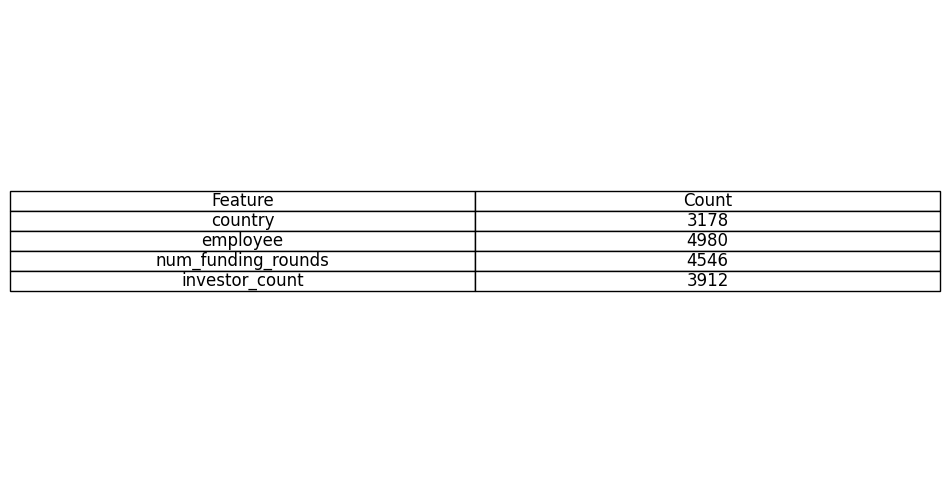

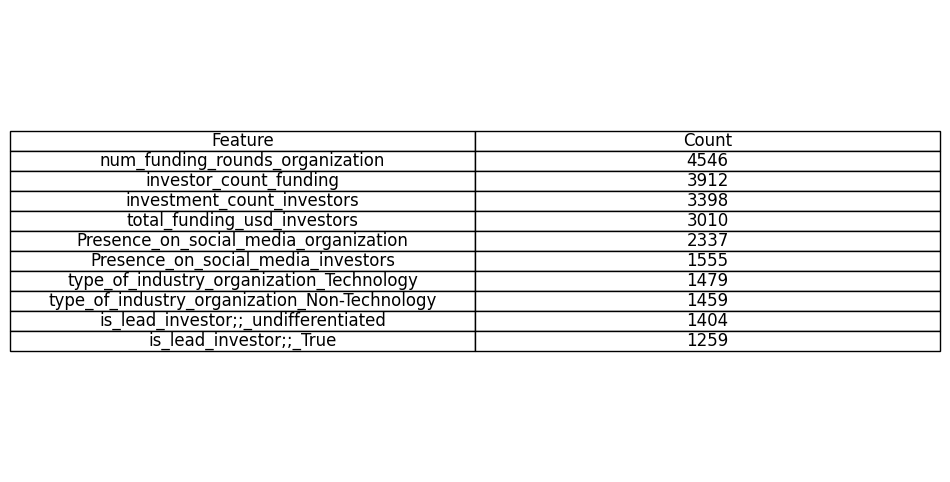

<Figure size 1500x1200 with 0 Axes>

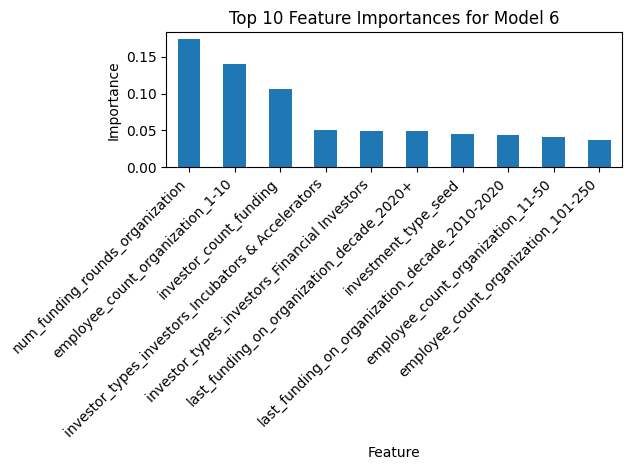

In [164]:
# Feature occurrence counting function
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # Not a leaf
            feature = feature_names[tree.feature[node]]
            feature_count[feature] = feature_count.get(feature, 0) + 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Model 4 parameters
params4 = {
    'n_estimators': 100,
    'max_features': 'sqrt',
    'max_depth': 10,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'random_state': 42
}

# Training Model 4
model4 = RandomForestRegressor(**params4).fit(X_train, y_train)

# Predictions for training and test sets
y_train_pred4 = model4.predict(X_train)
y_test_pred4 = model4.predict(X_test)

# Metrics for training set
mse_train4 = mean_squared_error(y_train, y_train_pred4)
rmse_train4 = np.sqrt(mse_train4)
mae_train4 = mean_absolute_error(y_train, y_train_pred4)
r2_train4 = r2_score(y_train, y_train_pred4)

# Metrics for test set
mse_test4 = mean_squared_error(y_test, y_test_pred4)
rmse_test4 = np.sqrt(mse_test4)
mae_test4 = mean_absolute_error(y_test, y_test_pred4)
r2_test4 = r2_score(y_test, y_test_pred4)

# Printing the results
results4 = {
    'Model': 'Model 4',
    'Params': params4,
    'MSE Train': round(mse_train4, 3),
    'RMSE Train': round(rmse_train4, 3),
    'MAE Train': round(mae_train4, 3),
    'R2 Train': round(r2_train4, 3),
    'MSE Test': round(mse_test4, 3),
    'RMSE Test': round(rmse_test4, 3),
    'MAE Test': round(mae_test4, 3),
    'R2 Test': round(r2_test4, 3)
}
print("Results for Model 4:")
print(results4)

# Feature importance
feature_importances4 = model4.feature_importances_

# Counting feature occurrences across all trees in Model 4
feature_count4 = {}
count_dict4 = {key: 0 for key in ["country", "employee", "num_funding_rounds", "investor_count"]}
for estimator in model4.estimators_:
    tree_feature_count, tree_count_dict = count_features_in_tree(estimator.tree_, X.columns)
    for feature, count in tree_feature_count.items():
        feature_count4[feature] = feature_count4.get(feature, 0) + count
    for key in count_dict4:
        count_dict4[key] += tree_count_dict[key]

# Creating DataFrame for specific keyword counts
search_features_df4 = pd.DataFrame(list(count_dict4.items()), columns=['Feature', 'Count'])

# Saving as table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df4.values, colLabels=search_features_df4.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig('search_keywords_count_table_model_4_bezgeo.png', bbox_inches='tight')
plt.show()

# Top occurring features
top_features4 = dict(sorted(feature_count4.items(), key=lambda item: item[1], reverse=True))

# DataFrame with top 10 most frequent features
top_features_df4 = pd.DataFrame(list(top_features4.items())[:10], columns=['Feature', 'Count'])

# Saving as table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df4.values, colLabels=top_features_df4.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig('top_features_count_table_model_4_geo.png', bbox_inches='tight')
plt.show()

# Creating DataFrame for feature importances
features_df4 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances4
}).sort_values(by='Importance', ascending=False)

# Plot - top 10 importances
plt.figure(figsize=(15, 12))
top_features_df4 = features_df4.head(10)
top_features_df4.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 6')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_6_bezgeo.png', bbox_inches='tight')
plt.show()


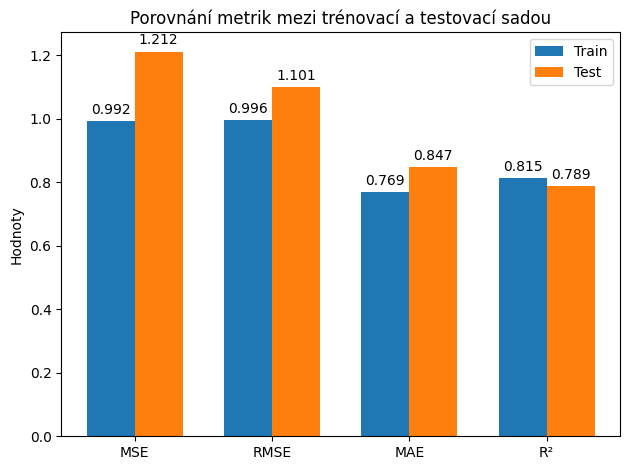

In [165]:
# Metrics for training and test sets
metrics_train = [mse_train4, rmse_train4, mae_train4, r2_train4]
metrics_test = [mse_test4, rmse_test4, mae_test4, r2_test4]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding labels, title, and axis ticks
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics Between Training and Test Set')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Add a label above each bar showing its value."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('metrics_comparison_random_forest_model4_bezgeo.png')
plt.show()


In [166]:
# Technology Sector Analysis
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Converting names to indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Initialization of the geographic feature tracking
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_leaf_parent_counts = {feature: 0 for feature in geo_features}
geo_parent_nodes_set = set()  # Unique parent nodes where geo features were used to split before a leaf

# Accumulators for overall node counts
total_leaf_nodes = 0
total_parent_nodes = 0
total_nodes = 0

# Iteration through all trees in the model
for estimator in model4.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count  # Counting total nodes in each tree

    parent_nodes = set()

    # Iteration through all nodes
    for node_id in range(tree.node_count):
        # Check if this is a leaf node
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
            total_leaf_nodes += 1

            # Finding parent node of the leaf
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if parent_id.size > 0:
                parent_nodes.add(parent_id[0])
                split_feature = tree.feature[parent_id[0]]

                # Checking if the splitting feature is geographic
                if split_feature in geo_feature_indices:
                    geo_feature_name = X_train.columns[split_feature]
                    geo_leaf_parent_counts[geo_feature_name] += 1
                    geo_parent_nodes_set.add(parent_id[0])

    total_parent_nodes += len(parent_nodes)

# Total number of unique parent nodes that used geo features
total_geo_parent_nodes = len(geo_parent_nodes_set)

# Creating dataframe of geo feature split counts
geo_results = [
    {
        'Feature': feature,
        'Leaf Parent Count': geo_leaf_parent_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# Summary of node counts
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Saving results to Excel
with pd.ExcelWriter('model4_node_analysis_with_geo.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Leaf Parent Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# Printing the results
print("\nAnalysis of geographic features in parent nodes of leaf nodes:")
print(geo_results_df)
print("\nSummary of node counts:")
print(summary_df)



Analýza geografických proměnných v rodičovských uzlech listů:
                                    Feature  Leaf Parent Count
0              country_code_organization_US                547
1          country_code_organization_non-US                590
2       city_organization_core-startup-city               1123
3   city_organization_non-core-startup-city               1212
4                 country_code_investors_US                574
5             country_code_investors_non-US                567
6          city_investors_core-startup-city               1267
7      city_investors_non-core-startup-city               1227
8                   country_code_funding_US                570
9               country_code_funding_non-US                548
10           city_funding_core-startup-city               1200
11       city_funding_non-core-startup-city               1221

Souhrnné počty uzlů:
               Metric   Value
0         Total Nodes  120222
1    Total Leaf Nodes   60161
2  Tot

SECOND MODEL WITH MODIFIED PARAMETERS

Výsledky pro model 5:
{'Model': 'Model 5', 'Params': {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 4, 'random_state': 42}, 'MSE Train': 0.868, 'RMSE Train': 0.932, 'MAE Train': 0.713, 'R2 Train': 0.838, 'MSE Test': 1.155, 'RMSE Test': 1.075, 'MAE Test': 0.823, 'R2 Test': 0.799}


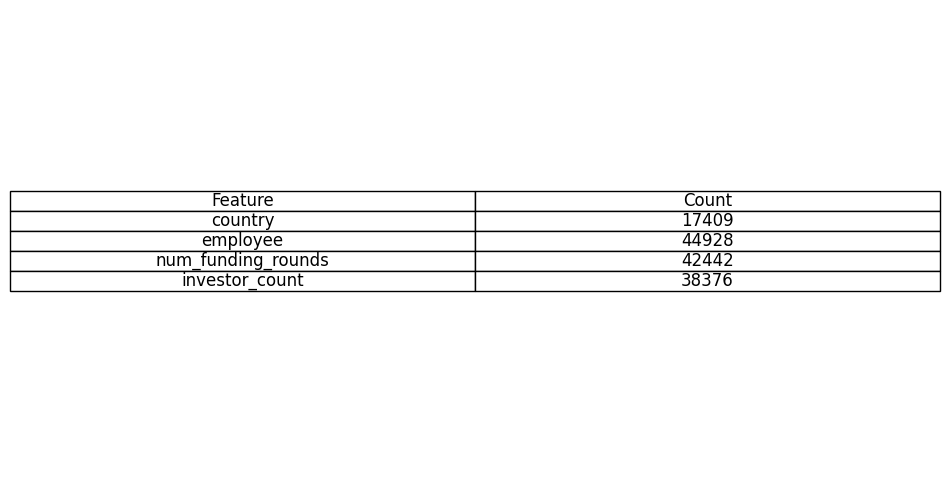

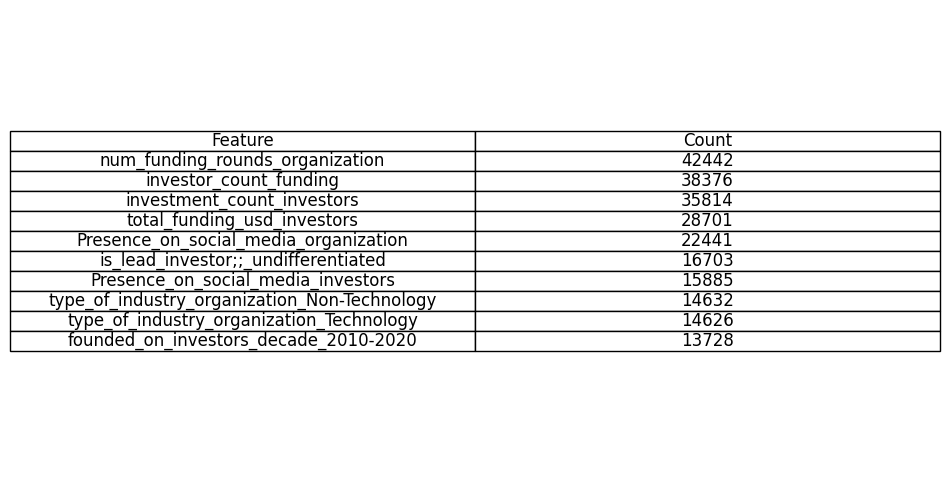

<Figure size 1500x1200 with 0 Axes>

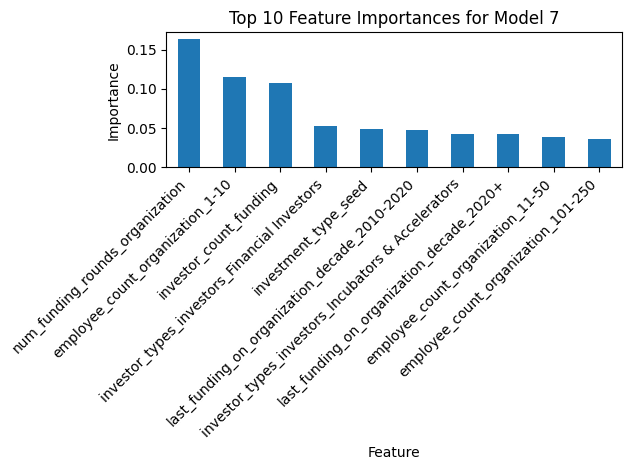

In [167]:
# Definition of a function to count feature occurrences
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # If not a leaf node
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

params_rf2 = {
    'n_estimators': 500,
    'max_features': 'log2',
    'max_depth': 30,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'random_state': 42
}

# Training Model 4
model5 = RandomForestRegressor(**params_rf2).fit(X_train, y_train)

# Predictions on the training and test sets
y_train_pred5 = model5.predict(X_train)
y_test_pred5 = model5.predict(X_test)

# Calculating metrics for the training and test sets
mse_train5 = mean_squared_error(y_train, y_train_pred5)
rmse_train5 = np.sqrt(mse_train5)
mae_train5 = mean_absolute_error(y_train, y_train_pred5)
r2_train5 = r2_score(y_train, y_train_pred5)

mse_train5_rounded = round(mse_train5, 3)
rmse_train5_rounded = round(rmse_train5, 3)
mae_train5_rounded = round(mae_train5, 3)
r2_train5_rounded = round(r2_train5, 3)

mse_test5 = mean_squared_error(y_test, y_test_pred5)
rmse_test5 = np.sqrt(mse_test5)
mae_test5 = mean_absolute_error(y_test, y_test_pred5)
r2_test5 = r2_score(y_test, y_test_pred5)

mse_test5_rounded = round(mse_test5, 3)
rmse_test5_rounded = round(rmse_test5, 3)
mae_test5_rounded = round(mae_test5, 3)
r2_test5_rounded = round(r2_test5, 3)

# Results for Model 5
results5 = {
    'Model': 'Model 5',
    'Params': params_rf2,
    'MSE Train': mse_train5_rounded,
    'RMSE Train': rmse_train5_rounded,
    'MAE Train': mae_train5_rounded,
    'R2 Train': r2_train5_rounded,
    'MSE Test': mse_test5_rounded,
    'RMSE Test': rmse_test5_rounded,
    'MAE Test': mae_test5_rounded,
    'R2 Test': r2_test5_rounded
}

# Print results for Model 5
print("Results for Model 5:")
print(results5)

# Feature importance for Model 5
feature_importances5 = model5.feature_importances_

# CountING the occurrences of searched features in all trees for Model 5
feature_count5 = {}
count_dict5 = {key: 0 for key in ["country", "employee", "num_funding_rounds", "investor_count"]}
for estimator in model5.estimators_:
    tree_feature_count, tree_count_dict = count_features_in_tree(estimator.tree_, X.columns)
    for feature, count in tree_feature_count.items():
        if feature in feature_count5:
            feature_count5[feature] += count
        else:
            feature_count5[feature] = count
    for key in count_dict5:
        count_dict5[key] += tree_count_dict[key]

# Creating a DataFrame with keyword counts for Model 5
search_features_df5 = pd.DataFrame(list(count_dict5.items()), columns=['Feature', 'Count'])

# Creating a table with keyword counts for Model 5
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df5.values, colLabels=search_features_df5.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the table as an image
plt.savefig('search_keywords_count_table_model_5_bezgeo.png', bbox_inches='tight')
plt.show()

# Most frequent features
top_features5 = {k: v for k, v in sorted(feature_count5.items(), key=lambda item: item[1], reverse=True)}

# Creating a DataFrame with the most frequent features for Model 5
top_features_df5 = pd.DataFrame(list(top_features5.items())[:10], columns=['Feature', 'Count'])

# Creating a table with the most frequent features for Model 5
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df5.values, colLabels=top_features_df5.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Savig the table as an image
plt.savefig('top_features_count_table_model_5_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating a DataFrame with feature importances for Model 5
features_df5 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances5
}).sort_values(by='Importance', ascending=False)

# Plot - feature importances for Model 5
plt.figure(figsize=(15, 12))
top_features_df5 = features_df5.head(10)
top_features_df5.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 7')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_7_bezgeo.png', bbox_inches='tight')
plt.show()


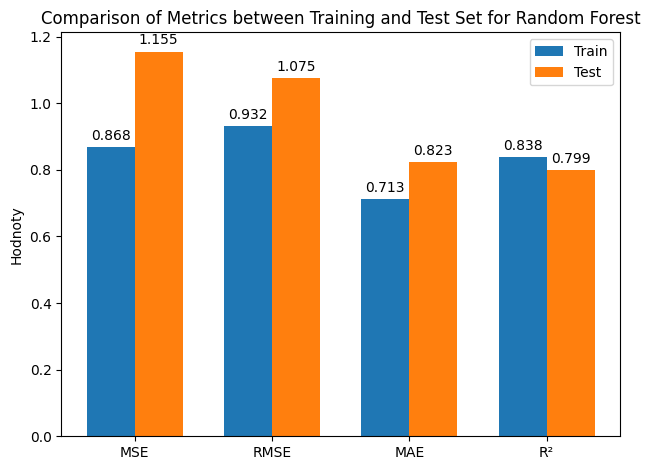

In [168]:
# Metrics for trainng and testing data set
metrics_train = [mse_train5, rmse_train5, mae_train5, r2_train5]
metrics_test = [mse_test5, rmse_test5, mae_test5, r2_test5]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Hodnoty')
ax.set_title('Comparison of Metrics between Training and Test Set for Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.show()

In [169]:
#  Technology Sector Analysis
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Converting feature names to indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Initialization of cumulative calculations across all trees
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

geo_leaf_parent_counts = {feature: 0 for feature in geo_features}
geo_parent_nodes_set = set()  # Setting for tracking parent nodes of leaf nodes split by geo features

# Node count accumulators
total_leaf_nodes = 0 
total_parent_nodes = 0 
total_nodes = 0 

# Iteration over all trees in the model
for estimator in model5.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count  # Accumulating total number of nodes in the tree

    parent_nodes = set()  # Setting for identifying parent nodes

    # Iteration over all nodes in the tree
    for node_id in range(tree.node_count):
        # Checkig if node is a leaf
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
            total_leaf_nodes += 1  # Increment leaf node count

            # Finding parent node of the leaf
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if parent_id.size > 0:  # If parent exists
                parent_nodes.add(parent_id[0])  # Adding parent to set

                split_feature = tree.feature[parent_id[0]]  # Feature used for split at parent

                # Checking if split feature is a geographic variable
                if split_feature in geo_feature_indices:
                    geo_feature_name = X_train.columns[split_feature]
                    geo_leaf_parent_counts[geo_feature_name] += 1
                    geo_parent_nodes_set.add(parent_id[0])  # Adding parent to geo-specific parent set

    total_parent_nodes += len(parent_nodes)  # Adding parent node count for current tree

# Counting of unique parent nodes with geographic split features
total_geo_parent_nodes = len(geo_parent_nodes_set)

# Output -> results for geographic features
geo_results = [
    {
        'Feature': feature,
        'Leaf Parent Count': geo_leaf_parent_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# Summary table of node counts
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Saving results to excel
with pd.ExcelWriter('model5_node_analysis_with_geo.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Leaf Parent Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# Printing the results
print("\nAnalysis of geographic features in parent nodes of leaves:")
print(geo_results_df)
print("\nSummary of node counts:")
print(summary_df)



Analýza geografických proměnných v rodičovských uzlech listů:
                                    Feature  Leaf Parent Count
0              country_code_organization_US               2624
1          country_code_organization_non-US               2712
2       city_organization_core-startup-city              13054
3   city_organization_non-core-startup-city              13027
4                 country_code_investors_US               2456
5             country_code_investors_non-US               2523
6          city_investors_core-startup-city              12976
7      city_investors_non-core-startup-city              12570
8                   country_code_funding_US               2642
9               country_code_funding_non-US               2596
10           city_funding_core-startup-city              12996
11       city_funding_non-core-startup-city              13033

Souhrnné počty uzlů:
               Metric    Value
0         Total Nodes  1086298
1    Total Leaf Nodes   543399
2  

THIRD MODEL WITH MODIFIED PARAMETERS

Výsledky pro model 8:
{'Model': 'Model 8', 'Params': {'n_estimators': 600, 'max_features': 'log2', 'max_depth': 50, 'min_samples_split': 10, 'min_samples_leaf': 10, 'random_state': 42}, 'MSE Train': 1.089, 'RMSE Train': 1.043, 'MAE Train': 0.8, 'R2 Train': 0.796, 'MSE Test': 1.284, 'RMSE Test': 1.133, 'MAE Test': 0.868, 'R2 Test': 0.776}


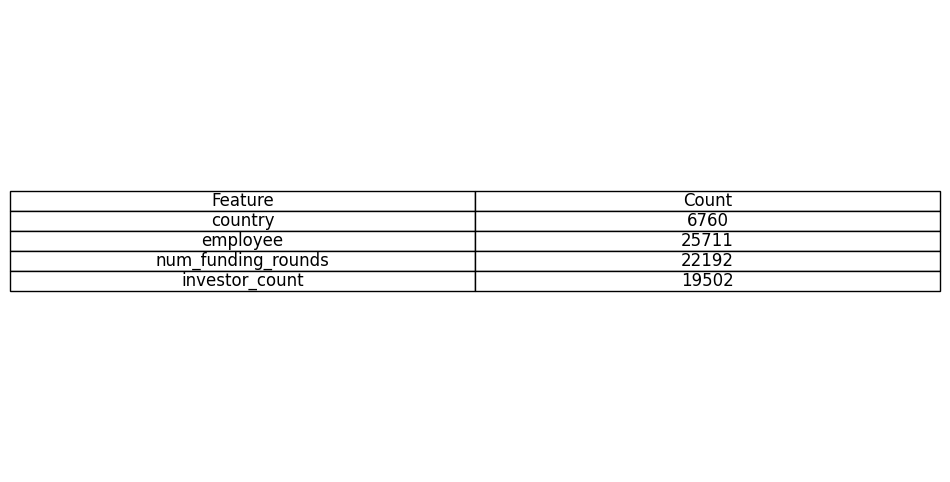

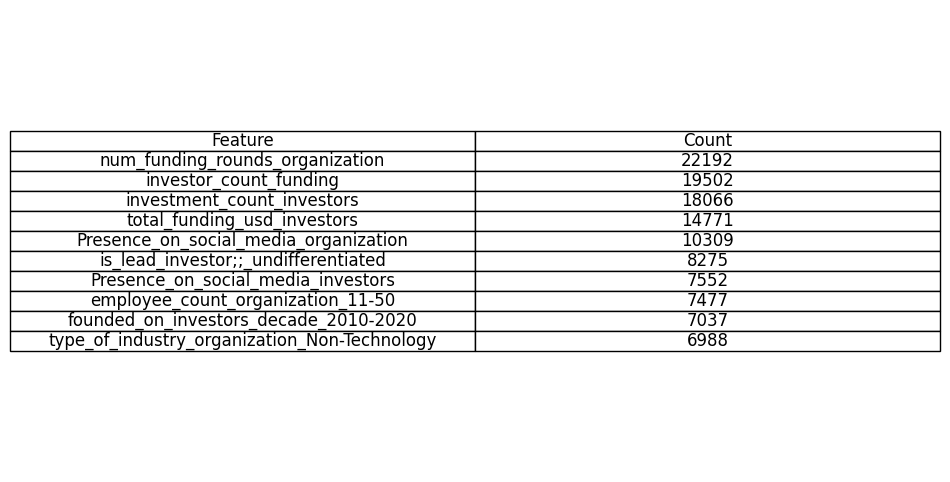

<Figure size 1500x1200 with 0 Axes>

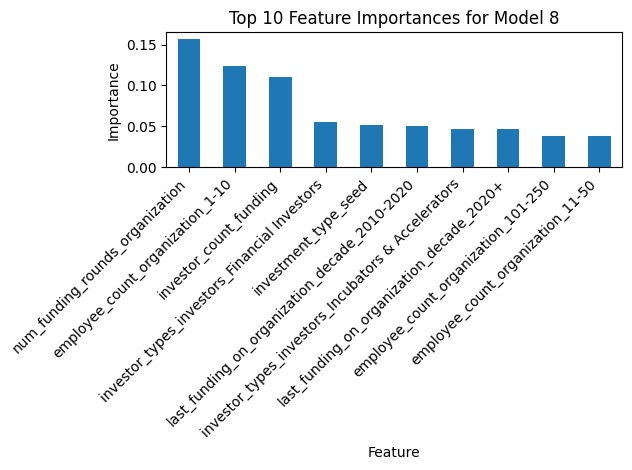

In [170]:
# Definition of a function to count feature occurrences in the tree
def count_features_in_tree(tree, feature_names):
    search_keywords = ["country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        if tree.children_left[node] != tree.children_right[node]:  # If it's not a leaf node
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

params_rf8 = {
    'n_estimators': 600,
    'max_features': 'log2',
    'max_depth': 50,
    'min_samples_split': 10,
    'min_samples_leaf': 10,
    'random_state': 42
}

# Training model 8
model8 = RandomForestRegressor(**params_rf8).fit(X_train, y_train)

# Predictions on the training and test sets
y_train_pred8 = model8.predict(X_train)
y_test_pred8 = model8.predict(X_test)

# Computing metrics for training and test sets
mse_train8 = mean_squared_error(y_train, y_train_pred8)
rmse_train8 = np.sqrt(mse_train8)
mae_train8 = mean_absolute_error(y_train, y_train_pred8)
r2_train8 = r2_score(y_train, y_train_pred8)

mse_train8_rounded = round(mse_train8, 3)
rmse_train8_rounded = round(rmse_train8, 3)
mae_train8_rounded = round(mae_train8, 3)
r2_train8_rounded = round(r2_train8, 3)

mse_test8 = mean_squared_error(y_test, y_test_pred8)
rmse_test8 = np.sqrt(mse_test8)
mae_test8 = mean_absolute_error(y_test, y_test_pred8)
r2_test8 = r2_score(y_test, y_test_pred8)

mse_test8_rounded = round(mse_test8, 3)
rmse_test8_rounded = round(rmse_test8, 3)
mae_test8_rounded = round(mae_test8, 3)
r2_test8_rounded = round(r2_test8, 3)

# Results for model 8
results8 = {
    'Model': 'Model 8',
    'Params': params_rf8,
    'MSE Train': mse_train8_rounded,
    'RMSE Train': rmse_train8_rounded,
    'MAE Train': mae_train8_rounded,
    'R2 Train': r2_train8_rounded,
    'MSE Test': mse_test8_rounded,
    'RMSE Test': rmse_test8_rounded,
    'MAE Test': mae_test8_rounded,
    'R2 Test': r2_test8_rounded
}

# Printing results for model 8
print("Results for model 8:")
print(results8)

# Feature importances for model 8
feature_importances8 = model8.feature_importances_

# Counting occurrences of target features in all trees for model 8
feature_count8 = {}
count_dict8 = {key: 0 for key in ["country", "employee", "num_funding_rounds", "investor_count"]}
for estimator in model8.estimators_:
    tree_feature_count, tree_count_dict = count_features_in_tree(estimator.tree_, X.columns)
    for feature, count in tree_feature_count.items():
        if feature in feature_count8:
            feature_count8[feature] += count
        else:
            feature_count8[feature] = count
    for key in count_dict8:
        count_dict8[key] += tree_count_dict[key]

# Creating a DataFrame with results for specific features for model 8
search_features_df8 = pd.DataFrame(list(count_dict8.items()), columns=['Feature', 'Count'])

# Creating a table with results for specific features for model 8
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df8.values, colLabels=search_features_df8.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the table as an image
plt.savefig('search_keywords_count_table_model_8.png', bbox_inches='tight')
plt.show()

# Most frequent features
top_features8 = {k: v for k, v in sorted(feature_count8.items(), key=lambda item: item[1], reverse=True)}

# Creating a DataFrame with the most frequent features for model 8
top_features_df8 = pd.DataFrame(list(top_features8.items())[:10], columns=['Feature', 'Count'])

# Creating a table with the most frequent features for model 8
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df8.values, colLabels=top_features_df8.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the table as an image
plt.savefig('top_features_count_table_model_8.png', bbox_inches='tight')
plt.show()

# Creating a DataFrame with feature importances and their names for model 8
features_df8 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances8
}).sort_values(by='Importance', ascending=False)

# Plotting feature importances for model 8
plt.figure(figsize=(15, 12))
top_features_df8 = features_df8.head(10)
top_features_df8.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 8')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_8.png', bbox_inches='tight')
plt.show()


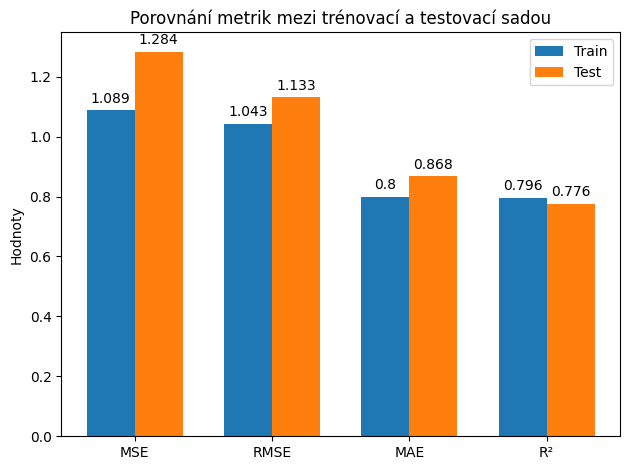

In [171]:
# Metriky pro trénovací a testovací sadu
metrics_train = [mse_train8, rmse_train8, mae_train8, r2_train8]
metrics_test = [mse_test8, rmse_test8, mae_test8, r2_test8]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Adding some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Hodnoty')
ax.set_title('Porovnání metrik mezi trénovací a testovací sadou')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects, ax):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('metrics_comparison_random_forest_model8_bezgeo.png')
plt.show()

In [172]:
#  Analysis of the Technology Sector
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# Feature names are converted to their corresponding column indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Preparing for cumulative calculations across all trees in the model
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

# Dictionary to track the number of times each geographic feature appears in a parent of a leaf node
geo_leaf_parent_counts = {feature: 0 for feature in geo_features}

# Set used to track unique parent nodes of leaves split on geographic features
geo_parent_nodes_set = set()

# Initializing counters for node statistics
total_leaf_nodes = 0
total_parent_nodes = 0       
total_nodes = 0              

# Iterating through all decision trees in the model
for estimator in model8.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count  # Adding the total number of nodes in the current tree

    parent_nodes = set()  # Temporary storage for parent nodes in the current tree

    # Iterating through all nodes of the current tree
    for node_id in range(tree.node_count):
        # Identifying leaf nodes
        if tree.children_left[node_id] == -1 and_]()_



Analýza geografických proměnných v rodičovských uzlech listů:
                                    Feature  Leaf Parent Count
0              country_code_organization_US                901
1          country_code_organization_non-US               1007
2       city_organization_core-startup-city               6871
3   city_organization_non-core-startup-city               6797
4                 country_code_investors_US                845
5             country_code_investors_non-US                908
6          city_investors_core-startup-city               6588
7      city_investors_non-core-startup-city               6647
8                   country_code_funding_US                922
9               country_code_funding_non-US               1038
10           city_funding_core-startup-city               6815
11       city_funding_non-core-startup-city               6937

Souhrnné počty uzlů:
               Metric   Value
0         Total Nodes  552082
1    Total Leaf Nodes  276341
2  Tot

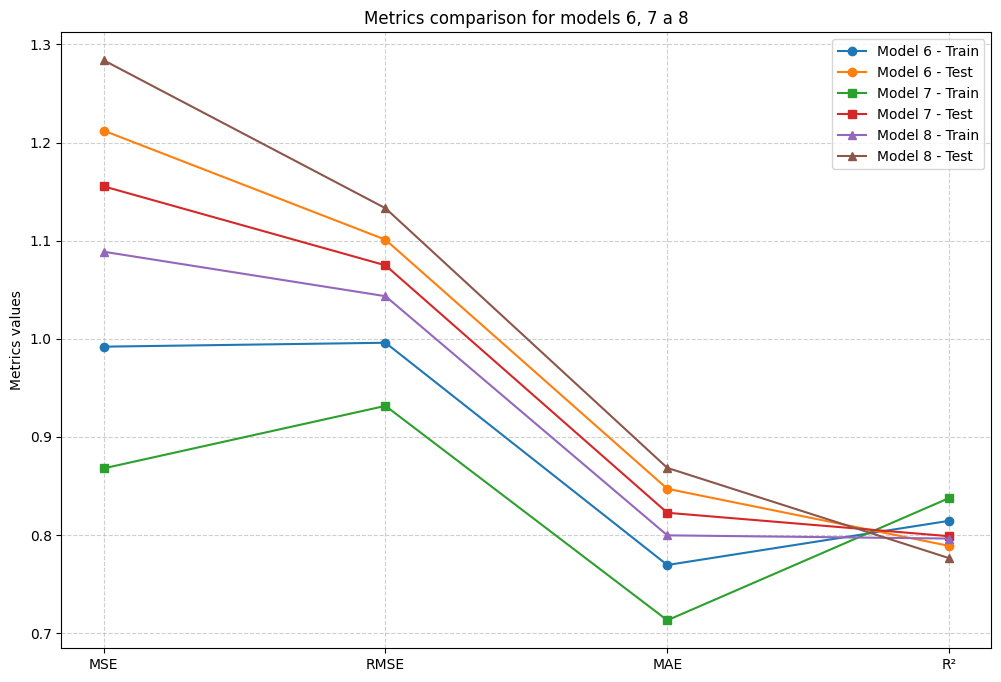

In [173]:

# Definition of metrics for each model( already counted above)
metrics_train4 = [mse_train4, rmse_train4, mae_train4, r2_train4]
metrics_test4 = [mse_test4, rmse_test4, mae_test4, r2_test4]

metrics_train5 = [mse_train5, rmse_train5, mae_train5, r2_train5]
metrics_test5 = [mse_test5, rmse_test5, mae_test5, r2_test5]

metrics_train8 = [mse_train8, rmse_train8, mae_train8, r2_train8]
metrics_test8 = [mse_test8, rmse_test8, mae_test8, r2_test8]



# Metrics labels
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# X-axis for each metric
x = np.arange(len(labels))

plt.figure(figsize=(12, 8))

# Line plot for each model
plt.plot(x, metrics_train4, marker='o', label='Model 6 - Train')
plt.plot(x, metrics_test4, marker='o', label='Model 6 - Test')

plt.plot(x, metrics_train5, marker='s', label='Model 7 - Train')
plt.plot(x, metrics_test5, marker='s', label='Model 7 - Test')

plt.plot(x, metrics_train8, marker='^', label='Model 8 - Train')
plt.plot(x, metrics_test8, marker='^', label='Model 8 - Test')

# Axis and legend
plt.xticks(x, labels)
plt.ylabel('Metrics values')
plt.title('Metrics comparison for models 6, 7 a 8')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Saving the plot
plt.savefig('metrics_comparison_models_forest.png', bbox_inches='tight')
plt.show()


In [174]:

# Defining metrics for each model(already counted above)
metrics_train_rf = [mse_train, rmse_train, mae_train, r2_train]
metrics_test_rf = [mse_test, rmse_test, mae_test, r2_test]

metrics_train4 = [mse_train4, rmse_train4, mae_train4, r2_train4]
metrics_test4 = [mse_test4, rmse_test4, mae_test4, r2_test4]

metrics_train5 = [mse_train5, rmse_train5, mae_train5, r2_train5]
metrics_test5 = [mse_test5, rmse_test5, mae_test5, r2_test5]

metrics_train8 = [mse_train8, rmse_train8, mae_train8, r2_train8]
metrics_test8 = [mse_test8, rmse_test8, mae_test8, r2_test8]

# Metrics labels
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# Metrics dataframe
metrics_data = {
    'Metric': labels,
    'Model 5 - Train': metrics_train_rf,
    'Model 5 - Test': metrics_test_rf,
    'Model 6 - Train': metrics_train4,
    'Model 6 - Test': metrics_test4,
    'Model 7 - Train': metrics_train5,
    'Model 7 - Test': metrics_test5,
    'Model 8 - Train': metrics_train8,
    'Model 8 - Test': metrics_test8,
}

metrics_df = pd.DataFrame(metrics_data)

# Output -> table to console
print("\nMetrics comparison table:")
print(metrics_df)

# Saving table to excel file
metrics_df.to_excel('metrics_comparison_models_forest.xlsx', index=False)





Metrics comparison table:
  Metric  Model 5 - Train  Model 5 - Test  Model 6 - Train  Model 6 - Test  \
0    MSE             0.15            0.98             0.99            1.21   
1   RMSE             0.39            0.99             1.00            1.10   
2    MAE             0.27            0.73             0.77            0.85   
3     R²             0.97            0.83             0.81            0.79   

   Model 7 - Train  Model 7 - Test  Model 8 - Train  Model 8 - Test  
0             0.87            1.16             1.09            1.28  
1             0.93            1.07             1.04            1.13  
2             0.71            0.82             0.80            0.87  
3             0.84            0.80             0.80            0.78  


GRID SEARCH RANDOM FOREST

In [175]:
#GRID SEARCH FOR RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Reduced hyperparameter grid
param_distributions = {
    'n_estimators': [100, 300, 500],  # Fewer options
    'max_features': ['sqrt', 'log2'],  # 'auto' removed as it's invalid
    'max_depth': [10, 30, None],  # Fewer options
    'min_samples_split': [2, 10],  # Fewer options
    'min_samples_leaf': [1, 4],  # Fewer options
}

# Initialization of the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=42)

# Initialization of the RandomizedSearchCV object with fewer iterations
rf_random_search = RandomizedSearchCV(estimator=rf_regressor, param_distributions=param_distributions,
                                      n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1,
                                      scoring='neg_mean_squared_error')

# Fiting the RandomizedSearchCV object to the training data

rf_random_search.fit(X_train, y_train)


# Best parameters and estimator
best_params = rf_random_search.best_params_
best_estimator = rf_random_search.best_estimator_

# Validation on the test set
predictions = best_estimator.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"The best parameters are {best_params} with a mean squared error of {mse}")



Fitting 3 folds for each of 10 candidates, totalling 30 fits
The best parameters are {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None} with a mean squared error of 1.0032022708600177


In [176]:
#RANDOM FOREST  OPTIMIZED


rf_regressor = RandomForestRegressor(n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=None, random_state=42)
# Fitting model on the training data
rf_regressor.fit(X_train, y_train)

# prediction on train data
y_train_pred = rf_regressor.predict(X_train)

# Metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)


# Printing the training metrics results
print("Trénovací sada:")
print(f'Mean Squared Error (MSE): {mse_train_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_train_rounded}')
print(f'Mean Absolute Error (MAE): {mae_train_rounded}')
print(f'R-squared (R²): {r2_train_rounded}')

# Prediction on test data
y_test_pred = rf_regressor.predict(X_test)

# Metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Printing the testing metrics
print("\nTestovací sada:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')




Trénovací sada:
Mean Squared Error (MSE): 0.15
Root Mean Squared Error (RMSE): 0.388
Mean Absolute Error (MAE): 0.279
R-squared (R²): 0.972

Testovací sada:
Mean Squared Error (MSE): 1.003
Root Mean Squared Error (RMSE): 1.002
Mean Absolute Error (MAE): 0.748
R-squared (R²): 0.825


Nejlepší parametry: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 323}
Nejlepší skóre (negativní MSE) na trénovacích datech (křížová validace): -0.921632100158859
MSE na testovací sadě: 0.9590509096733206


<Figure size 1000x800 with 0 Axes>

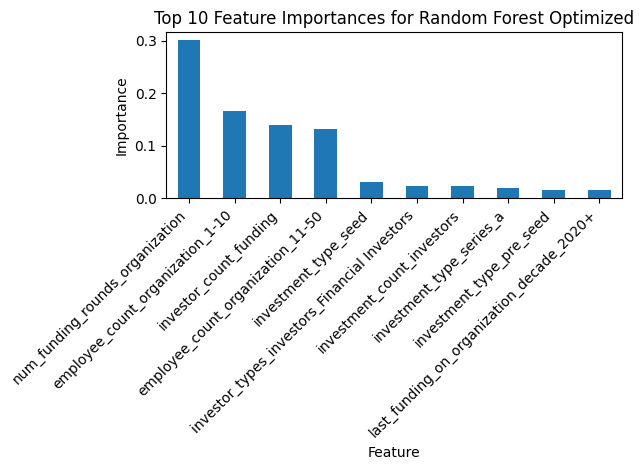

Výkon na trénovací sadě:
R2: 0.9719064774207512, MSE: 0.15025523309748415, RMSE: 0.3876276990844232, MAE: 0.27853201253667836

Výkon na testovací sadě:
R2: 0.8253375699263568, MSE: 1.0032022708600177, RMSE: 1.001599855660941, MAE: 0.7477935133430115


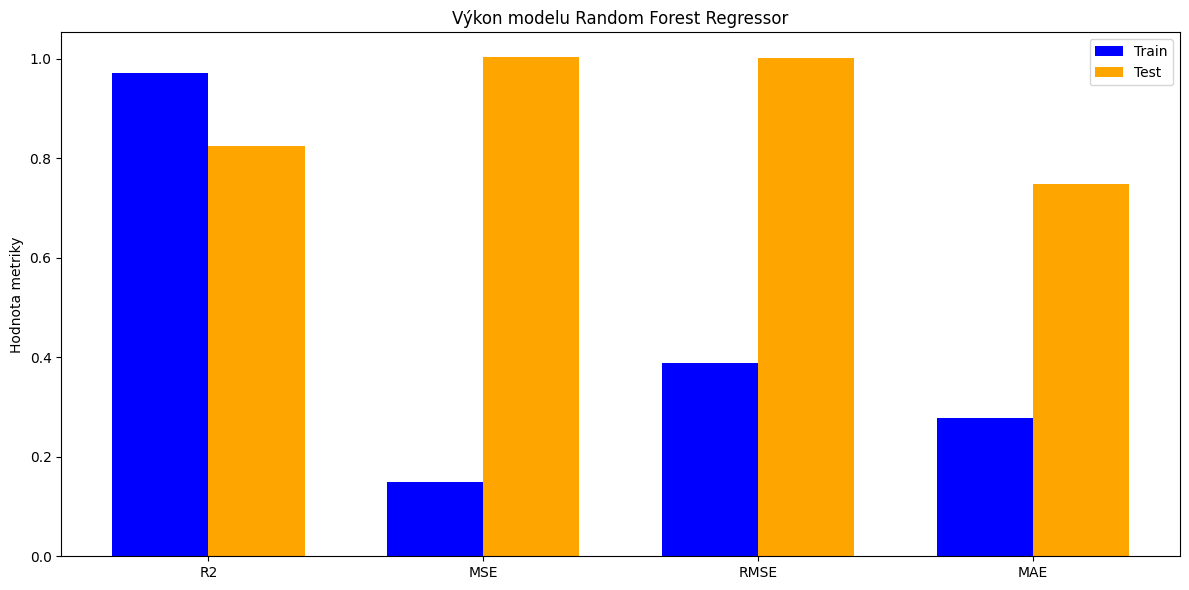

In [177]:
from scipy.stats import randint

# Defining the base model to be optimized
model = RandomForestRegressor(random_state=42)

# Creating a distribution of hyperparameters for RandomizedSearchCV to sample from
param_dist = {
    'n_estimators': randint(10, 500),
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
}

# Setting up the RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

# Performing the hyperparameter search on the training data
random_search.fit(X_train, y_train)

# Displaying the best combination of hyperparameters and the corresponding cross-validation score
print("Best parameters found:", random_search.best_params_)
print("Best (negative MSE) score on training data (via cross-validation):", random_search.best_score_)

# Using the best model found to evaluate performance on the test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print("MSE on the test set:", test_mse)

# Extracting feature importances from the optimized model
feature_importances = best_model.feature_importances_

# Creating a DataFrame to organize feature importance values
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plotting the top 10 most important features based on the optimized model
plt.figure(figsize=(10, 8))
top_features_df = features_df.head(10)
top_features_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Random Forest (Optimized)')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_random_forest_optimized.png', bbox_inches='tight')
plt.show()

# Calculating performance metrics on the training set
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Calculating performance metrics on the test set
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Printing model performance on the training and test sets
print("Performance on the training set:")
print(f"R2: {train_r2}, MSE: {train_mse}, RMSE: {train_rmse}, MAE: {train_mae}")
print("\nPerformance on the test set:")
print(f"R2: {test_r2}, MSE: {test_mse}, RMSE: {test_rmse}, MAE: {test_mae}")

# Plotting a comparison of performance metrics between training and test sets
metrics = ['R2', 'MSE', 'RMSE', 'MAE']
train_metrics = [train_r2, train_mse, train_rmse, train_mae]
test_metrics = [test_r2, test_mse, test_rmse, test_mae]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, train_metrics, width, label='Train', color='blue')
plt.bar(x + width / 2, test_metrics, width, label='Test', color='orange')
plt.xticks(x, metrics)
plt.title('Model Performance – Random Forest Regressor')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.savefig('top_ten_random_forest_optimized.png', bbox_inches='tight')
plt.show()


In [178]:
# Number of leaf nodes in all trees of Random Forest
total_leaf_nodes = 0

# Iteration through individual trees in Random Forest
for tree in best_model.estimators_:
    total_leaf_nodes += tree.tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Random Forestu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Random Forestu: 561127


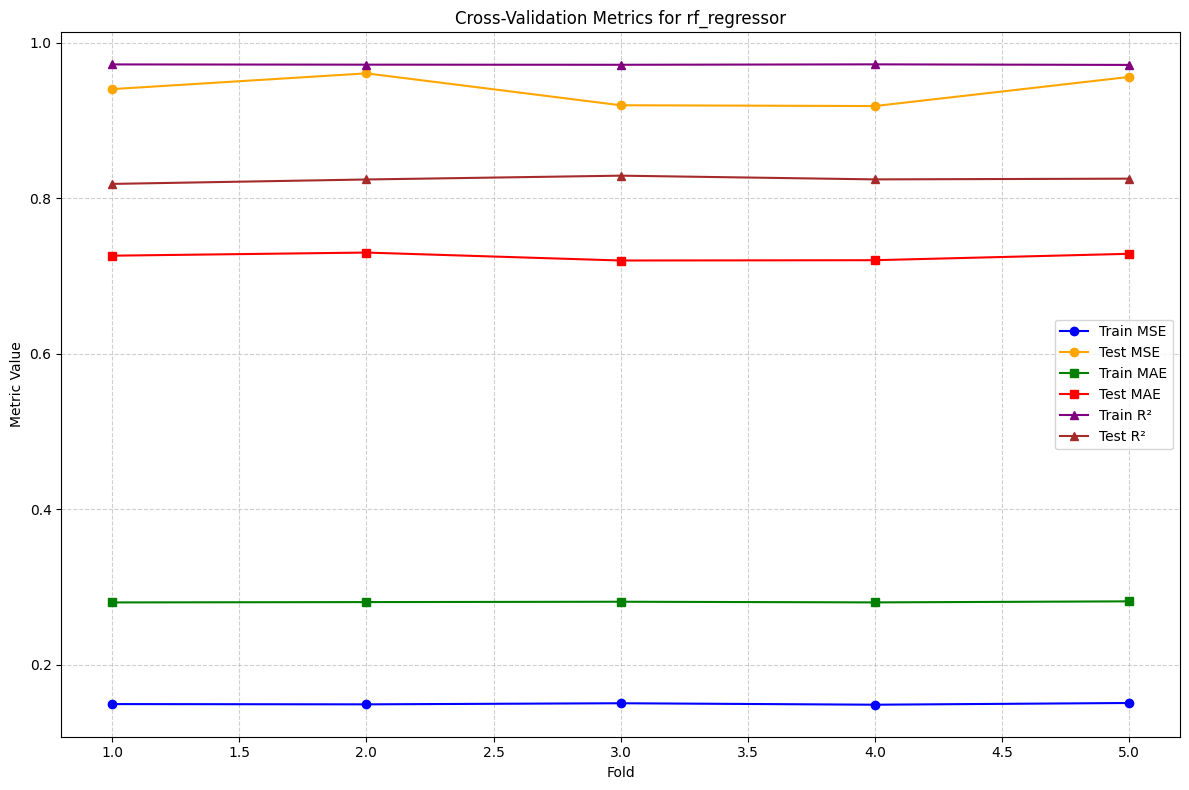

In [179]:


# Defining metrics
scoring = {
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

# Cross-validation
cv_results = cross_validate(
    rf_regressor, X_train, y_train, 
    cv=5, scoring=scoring, return_train_score=True, n_jobs=-1
)

# Extracting values for individual folds
train_mse = -cv_results['train_MSE']
test_mse = -cv_results['test_MSE']

train_mae = -cv_results['train_MAE']
test_mae = -cv_results['test_MAE']

train_r2 = cv_results['train_R2']
test_r2 = cv_results['test_R2']

# cREATING LINE PLOT
plt.figure(figsize=(12, 8))

# Line plot for MSE
plt.plot(range(1, 6), train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(range(1, 6), test_mse, marker='o', label='Test MSE', color='orange')

# Line plot for MAE
plt.plot(range(1, 6), train_mae, marker='s', label='Train MAE', color='green')
plt.plot(range(1, 6), test_mae, marker='s', label='Test MAE', color='red')

# Line plot for R²
plt.plot(range(1, 6), train_r2, marker='^', label='Train R²', color='purple')
plt.plot(range(1, 6), test_r2, marker='^', label='Test R²', color='brown')

# Plot setting
plt.xlabel('Fold')
plt.ylabel('Metric Value')
plt.title('Cross-Validation Metrics for rf_regressor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Saving the plot
plt.savefig('rf_regressor_cross_validation_line_plot.png', bbox_inches='tight', dpi=300)


plt.show()


In [180]:
# Technology sector feature setup
tech_feature_name = 'type_of_industry_organization_Technology'
non_tech_feature_name = 'type_of_industry_organization_Non-Technology'

# The selected feature names are converted to their corresponding column indices
tech_feature_index = list(X_train.columns).index(tech_feature_name)
non_tech_feature_index = list(X_train.columns).index(non_tech_feature_name)

# Geographic-related features (containing 'city' or 'country_code') are identified
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

# A dictionary is initialized to count how many times each geographic feature is used in a parent of a leaf node
geo_leaf_parent_counts = {feature: 0 for feature in geo_features}

# A set is used to track unique parent nodes that lead to leaves split on geographic features
geo_parent_nodes_set = set()

# Initial values are set for cumulative node statistics
total_leaf_nodes = 0         # Total number of leaf nodes across all trees
total_parent_nodes = 0       # Total number of unique parent nodes of leaves
total_nodes = 0              # Total number of nodes across all trees

# Each tree in the trained Random Forest Regressor is examined
for estimator in rf_regressor.estimators_:
    tree = estimator.tree_
    total_nodes += tree.node_count  # The total number of nodes in the current tree is added to the running total

    parent_nodes = set()  # Used to collect parent nodes in this specific tree

    # Looping through all nodes of the current tree
    for node_id in range(tree.node_count):
        # A leaf node is identified by having no children
        if tree.children_left[node_id] == -1 and tree.children_right[node_id] == -1:
            total_leaf_nodes += 1  # Updating the total number of leaf nodes

            # The parent node of this leaf is located
            parent_id = np.where((tree.children_left == node_id) | (tree.children_right == node_id))[0]
            if parent_id.size > 0:  # Checking that a parent actually exists
                parent_nodes.add(parent_id[0])  # The parent node is added to the set

                split_feature = tree.feature[parent_id[0]]  # The feature used to split in the parent node is extracted

                # If the feature is geographic, it is recorded accordingly
                if split_feature in geo_feature_indices:
                    geo_feature_name = X_train.columns[split_feature]
                    geo_leaf_parent_counts[geo_feature_name] += 1
                    geo_parent_nodes_set.add(parent_id[0])  # The geographic parent node is tracked

    total_parent_nodes += len(parent_nodes)  # The number of unique parent nodes in this tree is added

# The total number of unique parent nodes that involve geographic features is calculated
total_geo_parent_nodes = len(geo_parent_nodes_set)

# A list of results is prepared, showing how frequently each geographic feature appears as a parent of a leaf node
geo_results = [
    {
        'Feature': feature,
        'Leaf Parent Count': geo_leaf_parent_counts[feature],
    }
    for feature in geo_features
]
geo_results_df = pd.DataFrame(geo_results)

# A summary of key node statistics is assembled
summary_results = {
    'Metric': ['Total Nodes', 'Total Leaf Nodes', 'Total Parent Nodes', 'Geo Parent Nodes'],
    'Value': [total_nodes, total_leaf_nodes, total_parent_nodes, total_geo_parent_nodes]
}
summary_df = pd.DataFrame(summary_results)

# Both geographic results and overall node statistics are saved into an Excel file
with pd.ExcelWriter('rf_regressor_node_analysis_with_geo.xlsx') as writer:
    geo_results_df.to_excel(writer, sheet_name='Geo Leaf Parent Analysis', index=False)
    summary_df.to_excel(writer, sheet_name='Summary Node Counts', index=False)

# The analysis is printed for manual inspection
print("\nGeographic variable analysis in parent nodes of leaves:")
print(geo_results_df)
print("\nSummary of node counts across all trees:")
print(summary_df)


[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   8.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  19.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  20.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   2.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  18.1s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  12.6s
[CV] END max_depth=None, max_fea

Průměrná hodnota v levé větvi: 13.847366872049863
Průměrná hodnota v pravé větvi: 16.724047883779875
Celkový počet stromů: 500
Počet kořenových uzlů tvořených geografickými proměnnými: 3
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   2.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  18.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=  10.3s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  13.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.7s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_est

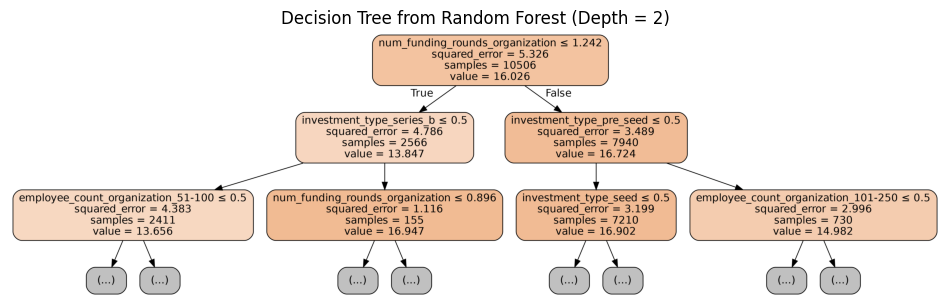

In [181]:

from sklearn.tree import export_graphviz
from subprocess import call

# Definition of geographic variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]
geo_feature_indices = [list(X_train.columns).index(col) for col in geo_features]

# Selecting one tree from a random forest
tree_index = 0
selected_tree = rf_regressor.estimators_[tree_index]
tree = selected_tree.tree_

#Root node
root_node = 0

# Average value of the explained variable in the left and right branches of the root node
left_child = tree.children_left[root_node]
right_child = tree.children_right[root_node]

left_avg = np.mean(tree.value[left_child])
right_avg = np.mean(tree.value[right_child])

print(f"Průměrná hodnota v levé větvi: {left_avg}")
print(f"Průměrná hodnota v pravé větvi: {right_avg}")

# Analysis of root nodes in all trees
geo_root_count = 0  # Number of root nodes formed by geographical variables
total_trees = len(rf_regressor.estimators_)

for estimator in rf_regressor.estimators_:
    root_feature_index = estimator.tree_.feature[0]  # Root node attribute index
    if root_feature_index in geo_feature_indices:
        geo_root_count += 1

print(f"Celkový počet stromů: {total_trees}")
print(f"Počet kořenových uzlů tvořených geografickými proměnnými: {geo_root_count}")

# Exporting selected tree with depth 2
export_graphviz(
    selected_tree,
    out_file="tree_depth2.dot",
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2,
    special_characters=True
)

# Conversion to PNG format
call(['dot', '-Tpng', 'tree_depth2.dot', '-o', 'tree_depth2.png', '-Gdpi=300'])

# Plot
plt.figure(figsize=(12, 12))
img = plt.imread('tree_depth2.png')
plt.imshow(img)
plt.axis('off')
plt.title("Decision Tree from Random Forest (Depth = 2)")
plt.show()


GRADIENT TREE BOOSTING

In [182]:
#Gradient Boosting basics algorithm

from sklearn.ensemble import GradientBoostingRegressor


# Creating gradient boosting regressor object
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Training the model using the training sets
gbr.fit(X_train, y_train)

# Prediction -training data
y_train_pred = gbr.predict(X_train)

#Metrics for training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)

# Printing the metrics
print("Trénovací sada:")
print(f'Mean Squared Error (MSE): {mse_train_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_train_rounded}')
print(f'Mean Absolute Error (MAE): {mae_train_rounded}')
print(f'R-squared (R²): {r2_train_rounded}')

# Prediction for testing set
y_pred = gbr.predict(X_test)


mse_test = mean_squared_error(y_test, y_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Printing the metrics for testing set
print("\nTestovací sada:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')




Trénovací sada:
Mean Squared Error (MSE): 0.978
Root Mean Squared Error (RMSE): 0.989
Mean Absolute Error (MAE): 0.757
R-squared (R²): 0.817

Testovací sada:
Mean Squared Error (MSE): 1.057
Root Mean Squared Error (RMSE): 1.028
Mean Absolute Error (MAE): 0.794
R-squared (R²): 0.816


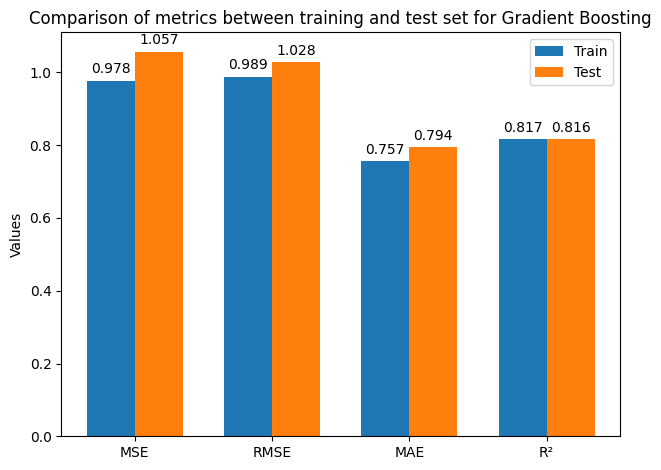

In [183]:
# Preparing the data to be used for plotting the metric comparison
metrics_train = [mse_train, rmse_train, mae_train, r2_train]
metrics_test = [mse_test, rmse_test, mae_test, r2_test]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # Positions for each metric on the x-axis
width = 0.35  # Width of the bars in the chart

# Creating the bar chart comparing training and test metrics
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Customizing the chart appearance
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics Between Training and Test Set for Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function used to display metric values above each bar for clarity
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Vertical offset in points
                    textcoords="offset points",
                    ha='center', va='bottom')

# Annotating bars with metric values
autolabel(rects1, ax)
autolabel(rects2, ax)

# Adjusting layout to avoid clipping
fig.tight_layout()
plt.savefig('metrics_comparison_gradient_boosting_bezgeo.png')
plt.show()


První strom GBR

In [184]:
# Baseline (average or median of the target variable at baseline)
initial_prediction = gbr.init_.constant_
print("Základní hodnota (F0):", initial_prediction)


Základní hodnota (F0): [[16.02139067]]


In [185]:
#Total number of leaf nodes in Gradient Boosting
total_leaf_nodes = 0

# Iteration through GBR trees
for tree in gbr.estimators_:
    
    total_leaf_nodes += tree[0].tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: 800


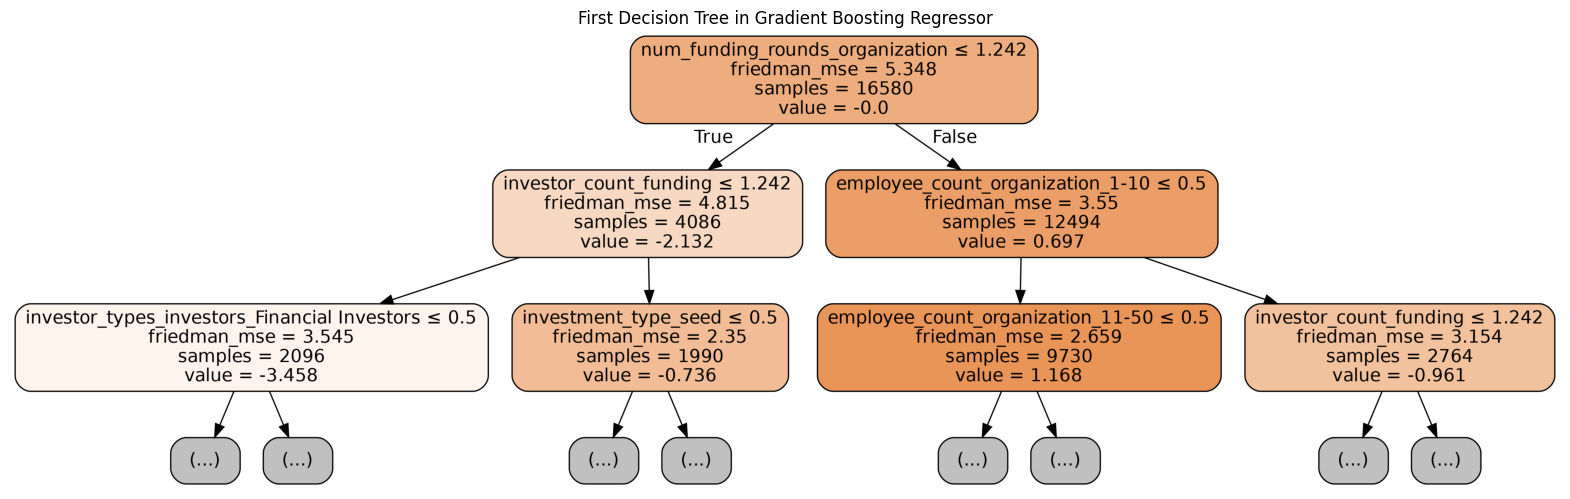

In [186]:


# Selecting the first tree from the gbr model
first_tree = gbr.estimators_[0][0]  # Vyberte první strom z prvního cyklu modelu

# Exporting of the first tree to DOT format
export_graphviz(
    first_tree,
    out_file="first_tree.dot",
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=2
)

#Export of the first tree to DOT format
call(['dot', '-Tpng', 'first_tree.dot', '-o', 'first_tree.png', '-Gdpi=300'])

# Plot
plt.figure(figsize=(20, 20))
img = plt.imread('first_tree.png')
plt.imshow(img)
plt.axis('off')
plt.title("First Decision Tree in Gradient Boosting Regressor")
plt.show()


Poslední strom GBR

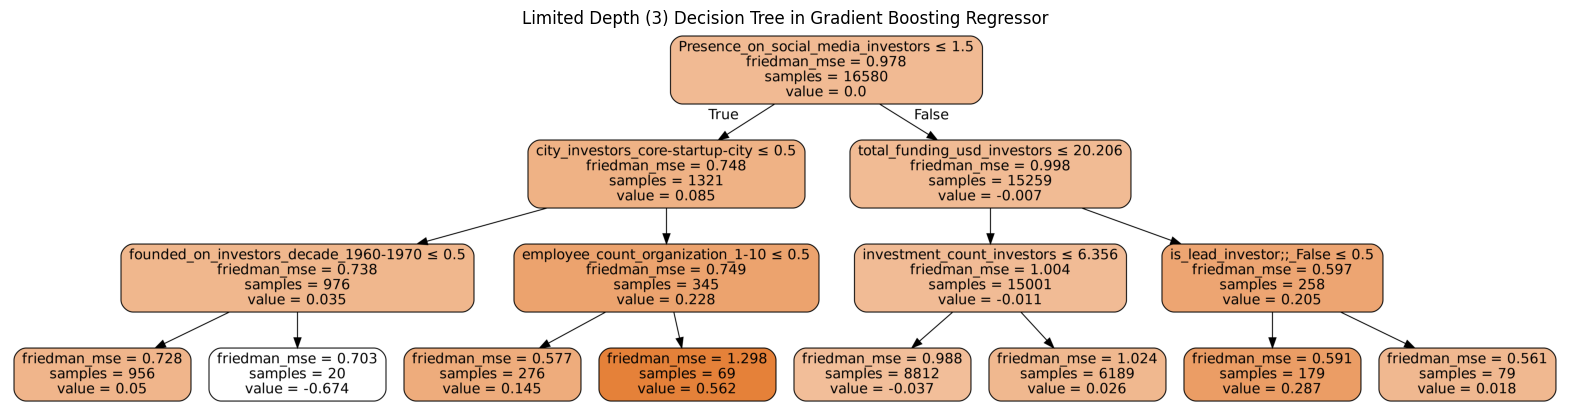

In [187]:


# Last tree from GBR model
last_tree_index = -1
last_tree = gbr.estimators_[last_tree_index][0]

# Export of the last tree in DOT format, max_depth is 3
export_graphviz(
    last_tree,
    out_file="last_tree_limited_depth.dot",
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3
)

# Converting DOT file to higher resolution PNG format
call(['dot', '-Tpng', 'last_tree_limited_depth.dot', '-o', 'last_tree_limited_depth_highres.png', '-Gdpi=600'])

# Plot
plt.figure(figsize=(20, 20))
img = plt.imread('last_tree_limited_depth_highres.png')
plt.imshow(img)
plt.axis('off')
plt.title("Limited Depth (3) Decision Tree in Gradient Boosting Regressor")
plt.show()


In [188]:
from collections import Counter


# Defining the geographical variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]

# Tracking root nodes and all nodes
root_features = []
all_features = []

for tree in gbr.estimators_[:, 0]:  # For each tree (first tree for each iteration)
    tree_features = tree.tree_.feature
    for feature_index in tree_features:
        if feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
            all_features.append(X_train.columns[feature_index])
    root_feature_index = tree.tree_.feature[0]  # Root node feature index
    if root_feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
        root_features.append(X_train.columns[root_feature_index])

# Counting occurrences of root nodes
root_feature_counts = Counter(root_features)

# Counting occurrences of all nodes
all_feature_counts = Counter(all_features)

# Calculating total numbers
total_root_nodes = len(root_features)
total_geo_root_nodes = sum(1 for feature in root_features if feature in geo_features)

total_nodes = len(all_features)
total_geo_nodes = sum(1 for feature in all_features if feature in geo_features)

# Counting how many of the root or all nodes contain 'city' or 'country_code'
geo_city_nodes = sum(1 for feature in all_features if 'city' in feature.lower())
geo_country_code_nodes = sum(1 for feature in all_features if 'country_code' in feature.lower())

geo_city_root_nodes = sum(1 for feature in root_features if 'city' in feature.lower())
geo_country_code_root_nodes = sum(1 for feature in root_features if 'country_code' in feature.lower())

# Extracting the top 20 most common root nodes
top_20_root_features = root_feature_counts.most_common(20)

# Creating DataFrames for better visualization
top_20_root_features_df = pd.DataFrame(top_20_root_features, columns=['Feature', 'Count'])

# Displaying results
print("Top 20 most common root nodes:")
print(top_20_root_features_df)

print(f"\nTotal number of root nodes: {total_root_nodes}")
print(f"Number of geographical root nodes: {total_geo_root_nodes}")
print(f"Number of root nodes containing 'city': {geo_city_root_nodes}")
print(f"Number of root nodes containing 'country_code': {geo_country_code_root_nodes}")

print(f"\nTotal number of nodes: {total_nodes}")
print(f"Number of geographical nodes: {total_geo_nodes}")
print(f"Number of nodes containing 'city': {geo_city_nodes}")
print(f"Number of nodes containing 'country_code': {geo_country_code_nodes}")

# Saving the results to CSV
top_20_root_features_df.to_csv('top_20_root_features_with_geo.csv', index=False)

# Summary results
summary_results = {
    'Metric': [
        'Total Root Nodes', 
        'Geographical Root Nodes', 
        'Root Nodes Containing "City"', 
        'Root Nodes Containing "Country Code"',
        'Total Nodes', 
        'Geographical Nodes', 
        'Nodes Containing "City"', 
        'Nodes Containing "Country Code"'
    ],
    'Value': [
        total_root_nodes, 
        total_geo_root_nodes, 
        geo_city_root_nodes, 
        geo_country_code_root_nodes,
        total_nodes, 
        total_geo_nodes, 
        geo_city_nodes, 
        geo_country_code_nodes
    ]
}
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('summary_node_analysis_with_city_country.csv', index=False)

print("\nSummary results saved to 'summary_node_analysis_with_city_country.csv'")


Top 20 most common root nodes:
                                          Feature  Count
0                 num_funding_rounds_organization     22
1                          investor_count_funding     16
2       last_funding_on_organization_decade_2020+     11
3                employee_count_organization_1-10      7
4              Presence_on_social_media_investors      6
5                           investment_type_angel      5
6             employee_count_organization_251-500      4
7             investment_type_equity_crowdfunding      4
8             employee_count_organization_unknown      4
9   last_funding_on_organization_decade_2010-2020      3
10          employee_count_organization_1001-5000      3
11             employee_count_organization_51-100      3
12                       investment_type_series_c      2
13                    total_funding_usd_investors      2
14       type_of_industry_organization_Technology      2
15              founded_on_investors_decade_<1960      1


In [189]:

# Getting the last tree
last_tree = gbr.estimators_[-1][0]

# Accessing the values of the variable being explained in the leaf nodes
leaf_values = []

# Iteration over all tree nodes
for node_id in range(last_tree.tree_.node_count):
    # Checking if the leaf node is
 if last_tree.tree_.children_left[node_id] == -1 and last_tree.tree_.children_right[node_id] == -1:
        # Adding the value of the explained variable to the list
        leaf_values.append(last_tree.tree_.value[node_id][0][0])

# Calculating the range of the explained variable
leaf_min = np.min(leaf_values)
leaf_max = np.max(leaf_values)
leaf_range = leaf_max - leaf_min

print(f"Minimum value in leaf nodes: {leaf_min}")
print(f"Maximum value in leaf nodes: {leaf_max}")
print(f"Explanation variable range: {leaf_range}")

Minimální hodnota v listových uzlech: -0.67373941297546
Maximální hodnota v listových uzlech: 0.5618154687301871
Rozsah vysvětlované proměnné: 1.2355548817056472


In [190]:

# Defining the k-fold cross-validation method
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# cross-validation
cv_results = cross_val_score(gbr, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Output-> the mean and standard deviation of the cross-validation scores
print(f"Mean Squared Error (MSE) for Gradient Boosting Regressor: {-np.mean(cv_results):.2f} (+/- {np.std(cv_results):.2f})")

Mean Squared Error (MSE) for Gradient Boosting Regressor: 1.02 (+/- 0.02)


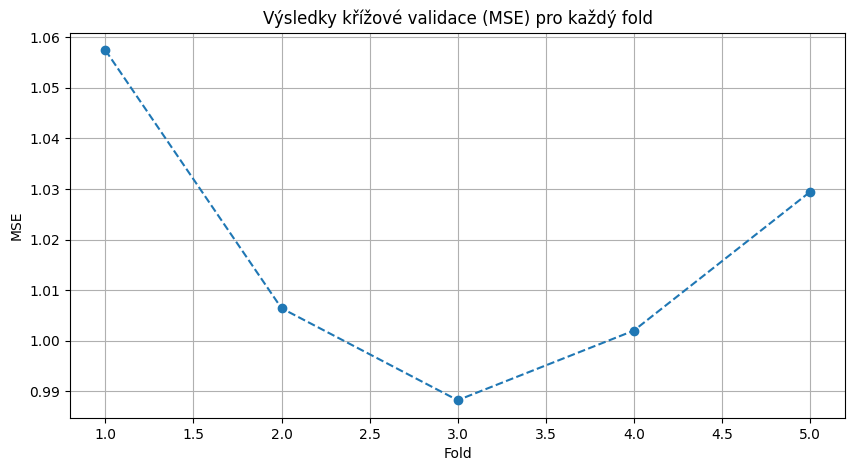

In [191]:
# Cross-validation vizualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cv_results) + 1), -cv_results, marker='o', linestyle='--')
plt.title('Výsledky křížové validace (MSE) pro každý fold')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.grid(True)
plt.savefig('cross_validation_results_gbr_bezgeo.png')
plt.show()



<Figure size 1500x1200 with 0 Axes>

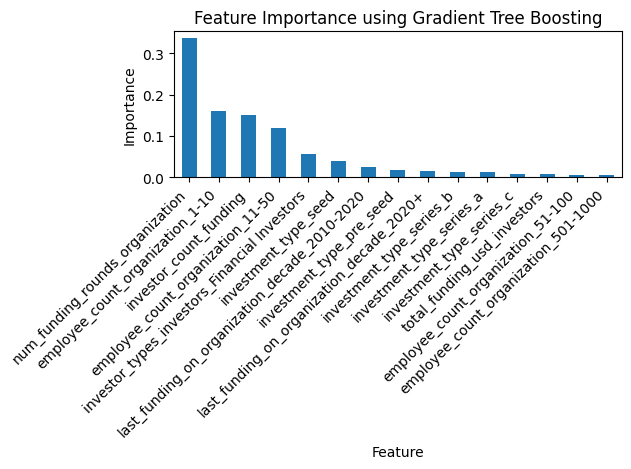

In [192]:
#GradientTreeBoosting Feature Importance

# Creating a DataFrame with flag meanings and flag names
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gbr.feature_importances_
}).sort_values(by='Importance', ascending=False)


#Feature Importance plot
plt.figure(figsize=(15, 12))
top_features_df = features_df.head(15)
top_features_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance using Gradient Tree Boosting')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)

plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
 
plt.savefig('new_feature_importance_gbr_bezgeo.png', bbox_inches='tight')
plt.show()

GRID SEARCH GBR FIRST

Výsledky pro model 6:
{'Model': 'Gradient Boosting Regressor Model 6', 'Params': {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'random_state': 42}, 'MSE Train': 3.035, 'RMSE Train': 1.742, 'MAE Train': 1.367, 'R2 Train': 0.433, 'MSE Test': 3.284, 'RMSE Test': 1.812, 'MAE Test': 1.431, 'R2 Test': 0.428}


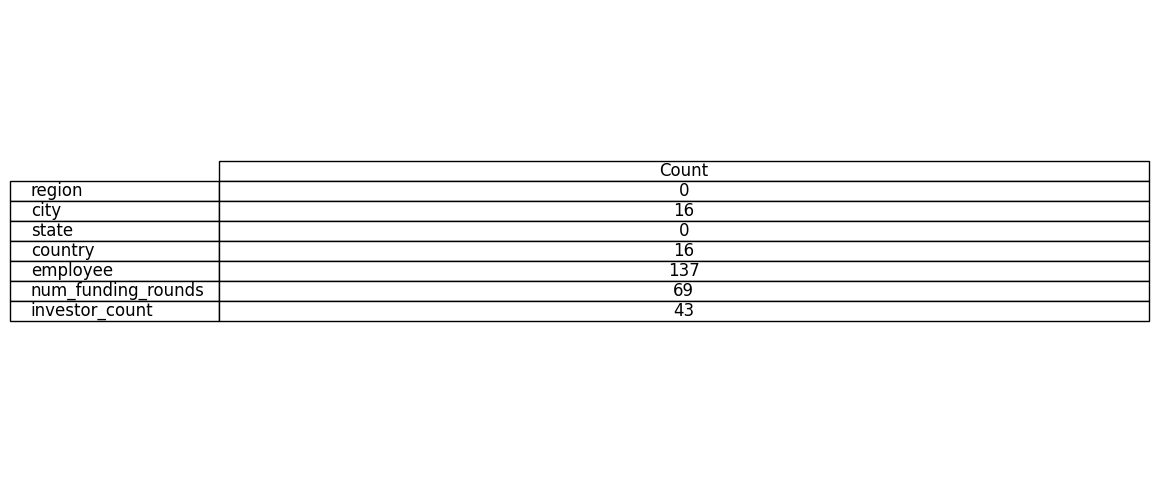

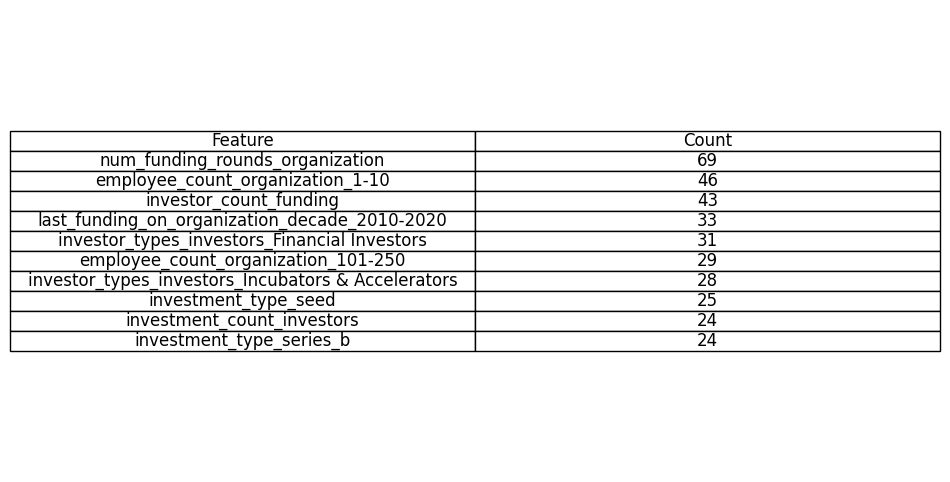

<Figure size 1500x1200 with 0 Axes>

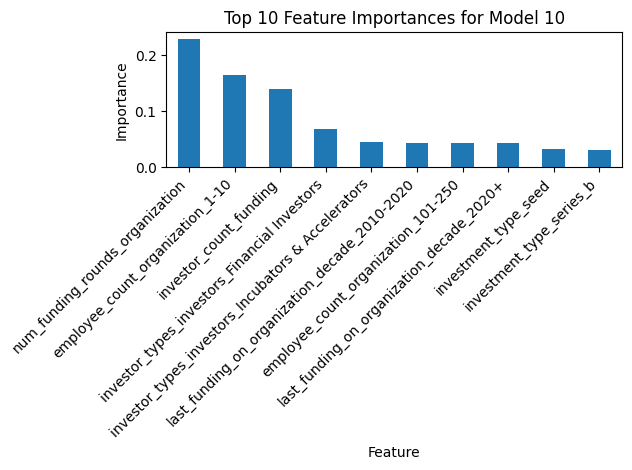

In [193]:
# Function that counts how often specific features are used for splits in a decision tree
def count_features_in_tree(tree, feature_names):
    search_keywords = ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        # Internal nodes (non-leaf) are identified for split analysis
        if tree.children_left[node] != tree.children_right[node]:
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Parameters defined for Gradient Boosting Regressor model 6
params_gbr6 = {
    'n_estimators': 100,
    'learning_rate': 0.01,
    'max_depth': 3,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'log2',
    'random_state': 42
}

# Training Gradient Boosting Regressor (Model 6) on training data
model6 = GradientBoostingRegressor(**params_gbr6).fit(X_train, y_train)

# Generating predictions for both training and test sets
y_train_pred6 = model6.predict(X_train)
y_test_pred6 = model6.predict(X_test)

# Calculating evaluation metrics for the training set
mse_train6 = mean_squared_error(y_train, y_train_pred6)
rmse_train6 = np.sqrt(mse_train6)
mae_train6 = mean_absolute_error(y_train, y_train_pred6)
r2_train6 = r2_score(y_train, y_train_pred6)

# Rounding metrics for cleaner presentation
mse_train6_rounded = round(mse_train6, 3)
rmse_train6_rounded = round(rmse_train6, 3)
mae_train6_rounded = round(mae_train6, 3)
r2_train6_rounded = round(r2_train6, 3)

# Calculating evaluation metrics for the test set
mse_test6 = mean_squared_error(y_test, y_test_pred6)
rmse_test6 = np.sqrt(mse_test6)
mae_test6 = mean_absolute_error(y_test, y_test_pred6)
r2_test6 = r2_score(y_test, y_test_pred6)

# Rounding metrics for cleaner presentation
mse_test6_rounded = round(mse_test6, 3)
rmse_test6_rounded = round(rmse_test6, 3)
mae_test6_rounded = round(mae_test6, 3)
r2_test6_rounded = round(r2_test6, 3)

# Storing the evaluation results for model 6 in a dictionary
results6 = {
    'Model': 'Gradient Boosting Regressor Model 6',
    'Params': params_gbr6,
    'MSE Train': mse_train6_rounded,
    'RMSE Train': rmse_train6_rounded,
    'MAE Train': mae_train6_rounded,
    'R2 Train': r2_train6_rounded,
    'MSE Test': mse_test6_rounded,
    'RMSE Test': rmse_test6_rounded,
    'MAE Test': mae_test6_rounded,
    'R2 Test': r2_test6_rounded
}

# Displaying evaluation results for model 6
print("Results for Model 6:")
print(results6)

# Extracting feature importances from the trained model
feature_importances6 = model6.feature_importances_

# Analyzing how often selected features appear in splits across all trees in the model
feature_count6 = {}
count_dict6 = {key: 0 for key in ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]}

# GradientBoostingRegressor stores trees in estimators_ as [n_estimators, 1], so we iterate over inner estimators
for estimator in model6.estimators_:
    for tree in estimator:
        tree_feature_count, tree_count_dict = count_features_in_tree(tree.tree_, X.columns)
        for feature, count in tree_feature_count.items():
            if feature in feature_count6:
                feature_count6[feature] += count
            else:
                feature_count6[feature] = count
        for key, count in tree_count_dict.items():
            count_dict6[key] += count

# Creating a DataFrame showing how often each keyword-related feature appears in the model
search_features_df6 = pd.DataFrame([count_dict6], index=['Model 6']).T
search_features_df6.columns = ['Count']

# Displaying the keyword feature usage in a table format
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df6.values, colLabels=search_features_df6.columns, rowLabels=search_features_df6.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the keyword feature usage table as an image
plt.savefig('search_keywords_count_table_model_6_bezgeo.png', bbox_inches='tight')
plt.show()

# Sorting all features by frequency of usage in the model to find the most commonly used ones
top_features6 = {k: v for k, v in sorted(feature_count6.items(), key=lambda item: item[1], reverse=True)}

# Creating a DataFrame with the top 10 most frequently used features in the model
top_features_df6 = pd.DataFrame(list(top_features6.items())[:10], columns=['Feature', 'Count'])

# Displaying the top features in a visual table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df6.values, colLabels=top_features_df6.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the top features table as an image
plt.savefig('top_features_count_table_model_10_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating a DataFrame that pairs each feature with its importance score from the trained model
features_df6 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances6
}).sort_values(by='Importance', ascending=False)

# Plotting the top 10 most important features based on importance scores
plt.figure(figsize=(15, 12))
top_features_df6 = features_df6.head(10)
top_features_df6.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 10')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_10_bezgeo.png', bbox_inches='tight')
plt.show()


In [194]:
# Celkový počet listových uzlů ve všech stromech Gradient Boostingu (regrese)
total_leaf_nodes = 0

# Iterace přes jednotlivé stromy
for tree in model6.estimators_:
    # Každý strom je jednorozměrné pole, vezmeme první prvek (pro regresi je jeden výstup)
    total_leaf_nodes += tree[0].tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: 795


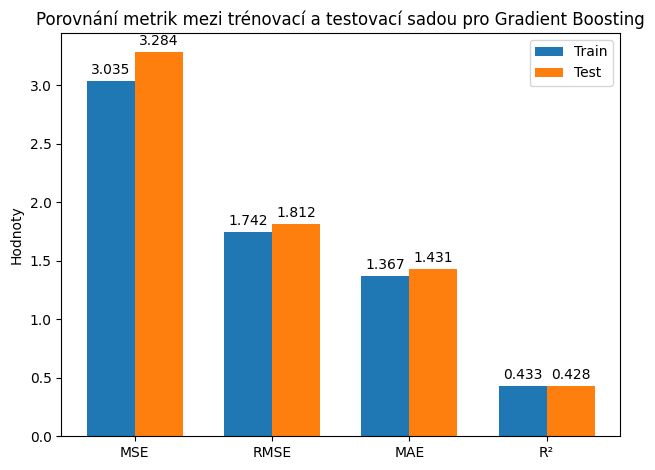

In [195]:

metrics_train = [mse_train6, rmse_train6, mae_train6, r2_train6]
metrics_test = [mse_test6, rmse_test6, mae_test6, r2_test6]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Ax setting
ax.set_ylabel('Hodnoty')
ax.set_title('Porovnání metrik mezi trénovací a testovací sadou pro Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function for displaying values above columns
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)

fig.tight_layout()
plt.savefig('GBR_1_METRICS_bezgeo.png')
plt.show()

In [196]:
from collections import Counter


# Defining geographical variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]

# Tracking root nodes and all nodes
root_features = []
all_features = []

for tree in model6.estimators_[:, 0]:  # For each tree (first tree for each iteration)
    tree_features = tree.tree_.feature
    for feature_index in tree_features:
        if feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
            all_features.append(X_train.columns[feature_index])
    root_feature_index = tree.tree_.feature[0]  # Root node feature index
    if root_feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
        root_features.append(X_train.columns[root_feature_index])

# Counting occurrences of root nodes
root_feature_counts = Counter(root_features)

# Counting occurrences of all nodes
all_feature_counts = Counter(all_features)

# Calculating total numbers
total_root_nodes = len(root_features)
total_geo_root_nodes = sum(1 for feature in root_features if feature in geo_features)

total_nodes = len(all_features)
total_geo_nodes = sum(1 for feature in all_features if feature in geo_features)

# Counting how many of the root or all nodes contain 'city' or 'country_code'
geo_city_nodes = sum(1 for feature in all_features if 'city' in feature.lower())
geo_country_code_nodes = sum(1 for feature in all_features if 'country_code' in feature.lower())

geo_city_root_nodes = sum(1 for feature in root_features if 'city' in feature.lower())
geo_country_code_root_nodes = sum(1 for feature in root_features if 'country_code' in feature.lower())

# Extracting the top 20 most common root nodes
top_20_root_features = root_feature_counts.most_common(20)

# Creating DataFrames for better visualization
top_20_root_features_df = pd.DataFrame(top_20_root_features, columns=['Feature', 'Count'])

# Displaying results
print("Top 20 most common root nodes:")
print(top_20_root_features_df)

print(f"\nTotal number of root nodes: {total_root_nodes}")
print(f"Number of geographical root nodes: {total_geo_root_nodes}")
print(f"Number of root nodes containing 'city': {geo_city_root_nodes}")
print(f"Number of root nodes containing 'country_code': {geo_country_code_root_nodes}")

print(f"\nTotal number of nodes: {total_nodes}")
print(f"Number of geographical nodes: {total_geo_nodes}")
print(f"Number of nodes containing 'city': {geo_city_nodes}")
print(f"Number of nodes containing 'country_code': {geo_country_code_nodes}")

# Saving the results to CSV
top_20_root_features_df.to_csv('top_20_root_features_with_geo_6.csv', index=False)

# Summary results
summary_results = {
    'Metric': [
        'Total Root Nodes', 
        'Geographical Root Nodes', 
        'Root Nodes Containing "City"', 
        'Root Nodes Containing "Country Code"',
        'Total Nodes', 
        'Geographical Nodes', 
        'Nodes Containing "City"', 
        'Nodes Containing "Country Code"'
    ],
    'Value': [
        total_root_nodes, 
        total_geo_root_nodes, 
        geo_city_root_nodes, 
        geo_country_code_root_nodes,
        total_nodes, 
        total_geo_nodes, 
        geo_city_nodes, 
        geo_country_code_nodes
    ]
}
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('summary_node_analysis_with_city_country_6.csv', index=False)

print("\nSummary results saved to 'summary_node_analysis_with_city_country_6.csv'")


Top 20 most common root nodes:
                                              Feature  Count
0                     num_funding_rounds_organization     15
1                    employee_count_organization_1-10      9
2                              investor_count_funding      7
3        investor_types_investors_Financial Investors      6
4                            investment_type_series_a      6
5       last_funding_on_organization_decade_2010-2020      5
6               Presence_on_social_media_organization      5
7           last_funding_on_organization_decade_2020+      4
8                employee_count_organization_501-1000      3
9                          investment_count_investors      3
10                employee_count_organization_101-250      3
11                           investment_type_series_b      3
12                 Presence_on_social_media_investors      3
13                  founded_on_investors_decade_<1960      3
14                 employee_count_organization_51-100 

GBR SECOND ONE

Výsledky pro model 7:
{'Model': 'Gradient Boosting Regressor Model 7', 'Params': {'n_estimators': 500, 'learning_rate': 0.2, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2'}, 'MSE Train': 0.406, 'RMSE Train': 0.637, 'MAE Train': 0.448, 'R2 Train': 0.924, 'MSE Test': 0.94, 'RMSE Test': 0.97, 'MAE Test': 0.734, 'R2 Test': 0.836}


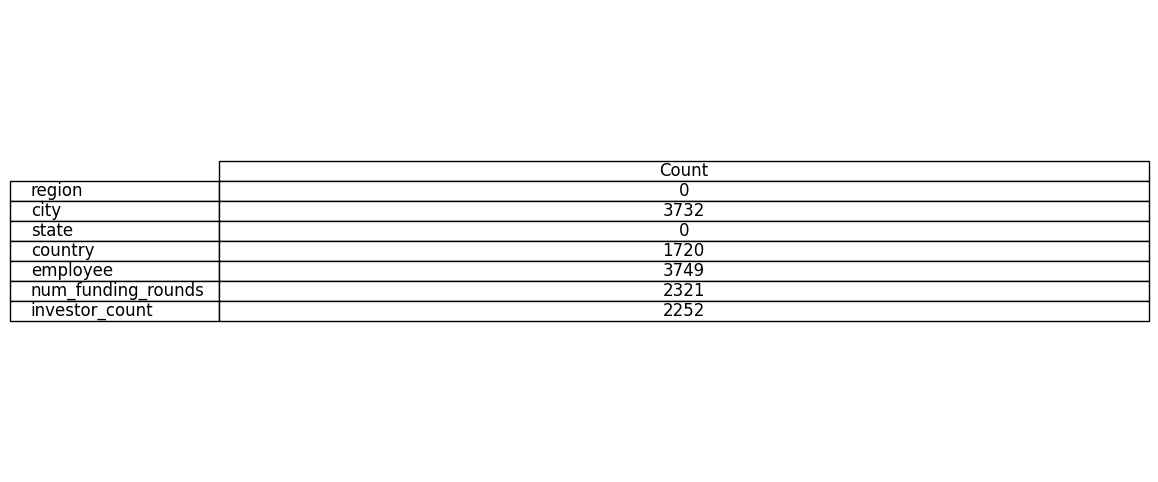

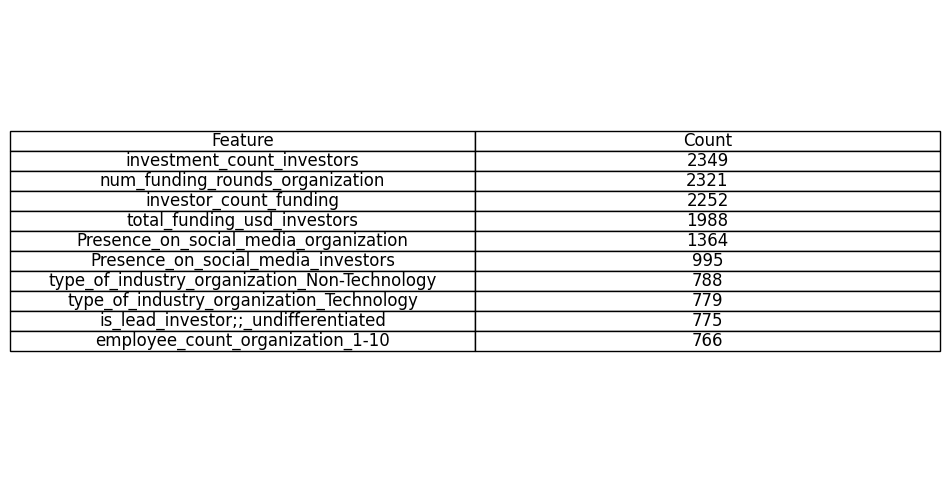

<Figure size 1500x1200 with 0 Axes>

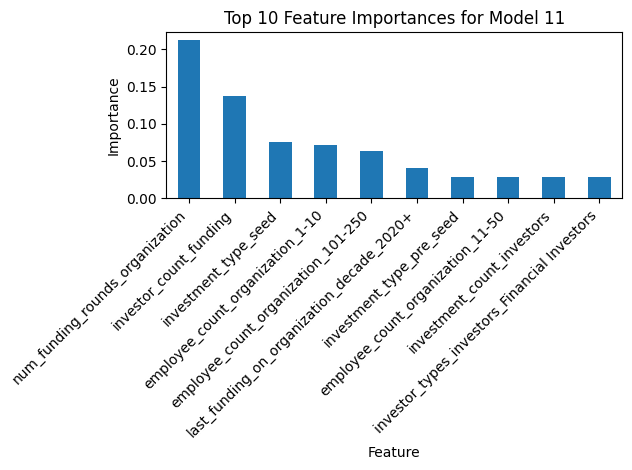

In [197]:
# Function that counts how often certain features are used for splits in a single decision tree
def count_features_in_tree(tree, feature_names):
    search_keywords = ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        # Checking whether the current node is a non-leaf node
        if tree.children_left[node] != tree.children_right[node]:
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Defining hyperparameters for Gradient Boosting Regressor model 7
params_gbr7 = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 7,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'log2'
}

# Training model 7 using the Gradient Boosting Regressor on training data
model7 = GradientBoostingRegressor(**params_gbr7).fit(X_train, y_train)

# Generating predictions for both training and test sets
y_train_pred7 = model7.predict(X_train)
y_test_pred7 = model7.predict(X_test)

# Calculating evaluation metrics for the training set
mse_train7 = mean_squared_error(y_train, y_train_pred7)
rmse_train7 = np.sqrt(mse_train7)
mae_train7 = mean_absolute_error(y_train, y_train_pred7)
r2_train7 = r2_score(y_train, y_train_pred7)

# Rounding training metrics for better readability
mse_train7_rounded = round(mse_train7, 3)
rmse_train7_rounded = round(rmse_train7, 3)
mae_train7_rounded = round(mae_train7, 3)
r2_train7_rounded = round(r2_train7, 3)

# Calculating evaluation metrics for the test set
mse_test7 = mean_squared_error(y_test, y_test_pred7)
rmse_test7 = np.sqrt(mse_test7)
mae_test7 = mean_absolute_error(y_test, y_test_pred7)
r2_test7 = r2_score(y_test, y_test_pred7)

# Rounding test metrics for better readability
mse_test7_rounded = round(mse_test7, 3)
rmse_test7_rounded = round(rmse_test7, 3)
mae_test7_rounded = round(mae_test7, 3)
r2_test7_rounded = round(r2_test7, 3)

# Organizing the model's evaluation results in a dictionary for reference
results7 = {
    'Model': 'Gradient Boosting Regressor Model 7',
    'Params': params_gbr7,
    'MSE Train': mse_train7_rounded,
    'RMSE Train': rmse_train7_rounded,
    'MAE Train': mae_train7_rounded,
    'R2 Train': r2_train7_rounded,
    'MSE Test': mse_test7_rounded,
    'RMSE Test': rmse_test7_rounded,
    'MAE Test': mae_test7_rounded,
    'R2 Test': r2_test7_rounded
}

# Displaying results for model 7
print("Results for Model 7:")
print(results7)

# Extracting feature importances from the trained Gradient Boosting model
feature_importances7 = model7.feature_importances_

# Analyzing how frequently key features appear in all decision trees of the model
feature_count7 = {}
count_dict7 = {key: 0 for key in ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]}

# Gradient Boosting stores trees in estimators_ as [n_estimators, 1]; we iterate over each tree
for estimator in model7.estimators_:
    for tree in estimator:
        tree_feature_count, tree_count_dict = count_features_in_tree(tree.tree_, X.columns)
        for feature, count in tree_feature_count.items():
            if feature in feature_count7:
                feature_count7[feature] += count
            else:
                feature_count7[feature] = count
        for key, count in tree_count_dict.items():
            count_dict7[key] += count

# Creating a DataFrame summarizing how often each target feature appears in splits
search_features_df7 = pd.DataFrame([count_dict7], index=['Model 7']).T
search_features_df7.columns = ['Count']

# Visualizing the keyword feature frequencies in a formatted table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(
    cellText=search_features_df7.values,
    colLabels=search_features_df7.columns,
    rowLabels=search_features_df7.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the keyword frequency table as an image file
plt.savefig('search_keywords_count_table_model_7_bezgeo.png', bbox_inches='tight')
plt.show()

# Sorting features by usage frequency to identify the most frequently used ones
top_features7 = {k: v for k, v in sorted(feature_count7.items(), key=lambda item: item[1], reverse=True)}

# Creating a DataFrame with the top 10 most frequently used features
top_features_df7 = pd.DataFrame(list(top_features7.items())[:10], columns=['Feature', 'Count'])

# Visualizing the most frequent features in a table format
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(
    cellText=top_features_df7.values,
    colLabels=top_features_df7.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the top features table as an image
plt.savefig('top_features_count_table_model_11_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating a DataFrame that combines feature names and their importance values
features_df7 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances7
}).sort_values(by='Importance', ascending=False)

# Plotting the top 10 features by importance score from model 7
plt.figure(figsize=(15, 12))
top_features_df7 = features_df7.head(10)
top_features_df7.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 11')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_11_bezgeo.png', bbox_inches='tight')
plt.show()


In [198]:
# Total number of leaf nodes in all trees Gradient Boosting (regression)
total_leaf_nodes = 0

# Iteration through each tree
for tree in model7.estimators_:
    # Each tree is a one-dimensional array, taking the first element (there is one output for regression)
    total_leaf_nodes += tree[0].tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: 38109


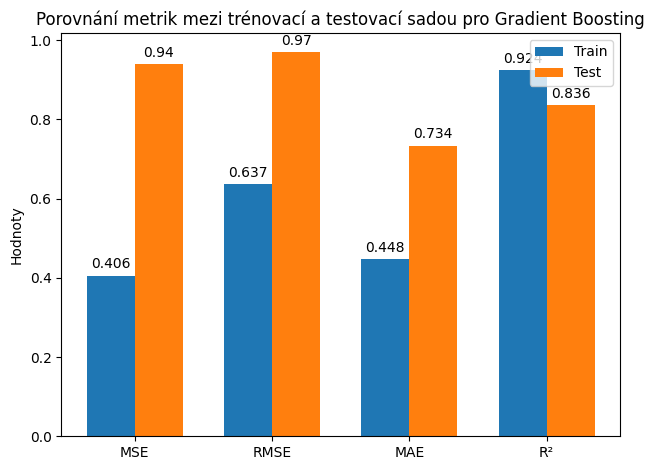

In [199]:
# Preparing metric values for visual comparison between training and test sets
metrics_train = [mse_train7, rmse_train7, mae_train7, r2_train7]
metrics_test = [mse_test7, rmse_test7, mae_test7, r2_test7]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # Positions for each metric on the x-axis
width = 0.35  # Width of each bar in the chart

# Creating the bar chart to compare model performance
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width/2, metrics_test, width, label='Test')

# Customizing the chart layout and labels
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics Between Training and Test Set for Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Defining a helper function to annotate bars with their exact values
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Offset for text positioning
                    textcoords="offset points",
                    ha='center', va='bottom')

# Applying annotations to both training and test bars
autolabel(rects1, ax)
autolabel(rects2, ax)

# Final layout adjustments and saving the figure as an image
fig.tight_layout()
plt.savefig('GBR_7_METRICS_bezgeo.png')
plt.show()


In [200]:

# Definition of geographical variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]

# Tracking root nodes and all nodes
root_features = []
all_features = []

for tree in model7.estimators_[:, 0]:  # For each tree (first tree for each iteration)
    tree_features = tree.tree_.feature
    for feature_index in tree_features:
        if feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
            all_features.append(X_train.columns[feature_index])
    root_feature_index = tree.tree_.feature[0]  # Root node feature index
    if root_feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
        root_features.append(X_train.columns[root_feature_index])

# Counting occurrences of root nodes
root_feature_counts = Counter(root_features)

# Counting occurrences of all nodes
all_feature_counts = Counter(all_features)

# Calculating total numbers
total_root_nodes = len(root_features)
total_geo_root_nodes = sum(1 for feature in root_features if feature in geo_features)

total_nodes = len(all_features)
total_geo_nodes = sum(1 for feature in all_features if feature in geo_features)

# Counting how many of the root or all nodes contain 'city' or 'country_code'
geo_city_nodes = sum(1 for feature in all_features if 'city' in feature.lower())
geo_country_code_nodes = sum(1 for feature in all_features if 'country_code' in feature.lower())

geo_city_root_nodes = sum(1 for feature in root_features if 'city' in feature.lower())
geo_country_code_root_nodes = sum(1 for feature in root_features if 'country_code' in feature.lower())

# Extracting the top 20 most common root nodes
top_20_root_features = root_feature_counts.most_common(20)

# Creating DataFrames for better visualization
top_20_root_features_df = pd.DataFrame(top_20_root_features, columns=['Feature', 'Count'])

# Displaying results
print("Top 20 most common root nodes:")
print(top_20_root_features_df)

print(f"\nTotal number of root nodes: {total_root_nodes}")
print(f"Number of geographical root nodes: {total_geo_root_nodes}")
print(f"Number of root nodes containing 'city': {geo_city_root_nodes}")
print(f"Number of root nodes containing 'country_code': {geo_country_code_root_nodes}")

print(f"\nTotal number of nodes: {total_nodes}")
print(f"Number of geographical nodes: {total_geo_nodes}")
print(f"Number of nodes containing 'city': {geo_city_nodes}")
print(f"Number of nodes containing 'country_code': {geo_country_code_nodes}")

# Saving the results to CSV
top_20_root_features_df.to_csv('top_20_root_features_with_geo_7.csv', index=False)

# Summary results
summary_results = {
    'Metric': [
        'Total Root Nodes', 
        'Geographical Root Nodes', 
        'Root Nodes Containing "City"', 
        'Root Nodes Containing "Country Code"',
        'Total Nodes', 
        'Geographical Nodes', 
        'Nodes Containing "City"', 
        'Nodes Containing "Country Code"'
    ],
    'Value': [
        total_root_nodes, 
        total_geo_root_nodes, 
        geo_city_root_nodes, 
        geo_country_code_root_nodes,
        total_nodes, 
        total_geo_nodes, 
        geo_city_nodes, 
        geo_country_code_nodes
    ]
}
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('summary_node_analysis_with_city_country_7.csv', index=False)

print("\nSummary results saved to 'summary_node_analysis_with_city_country_7.csv'")


Top 20 most common root nodes:
                                          Feature  Count
0                      investment_count_investors     38
1                     total_funding_usd_investors     33
2                 num_funding_rounds_organization     31
3                          investor_count_funding     29
4                        investment_type_series_b     15
5                        investment_type_series_c     14
6              Presence_on_social_media_investors     14
7   last_funding_on_organization_decade_2000-2010     12
8                        investment_type_pre_seed     11
9           Presence_on_social_media_organization     11
10            is_lead_investor;;_undifferentiated     11
11                           investment_type_seed     10
12  last_funding_on_organization_decade_2010-2020     10
13         employee_count_organization_5001-10000     10
14              employee_count_organization_11-50     10
15      last_funding_on_organization_decade_2020+      9


Third model with adjusted parameters

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   8.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   6.8s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   9.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   9.3s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   7.6s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=  12.4s
[CV] END max_depth=None, max_featu

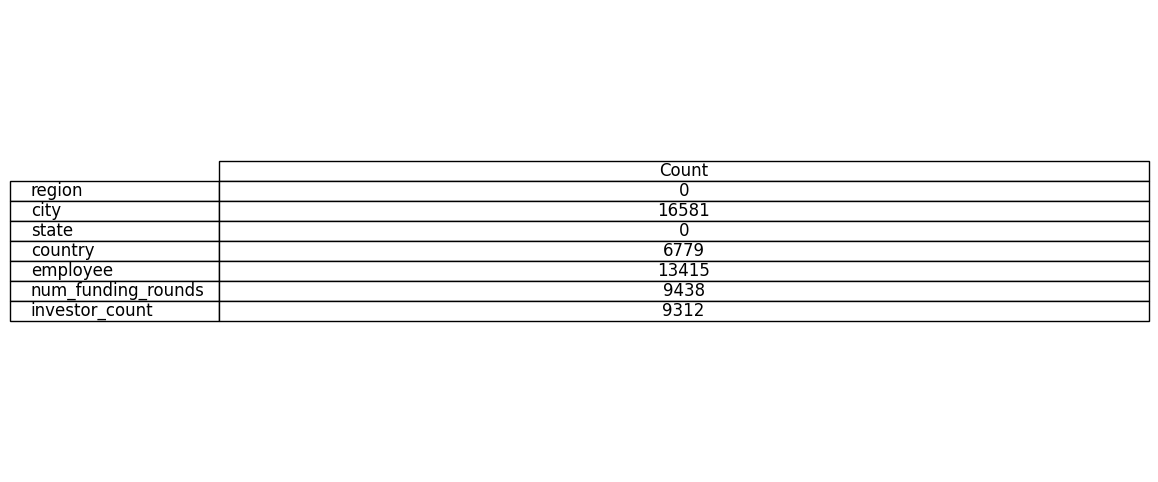

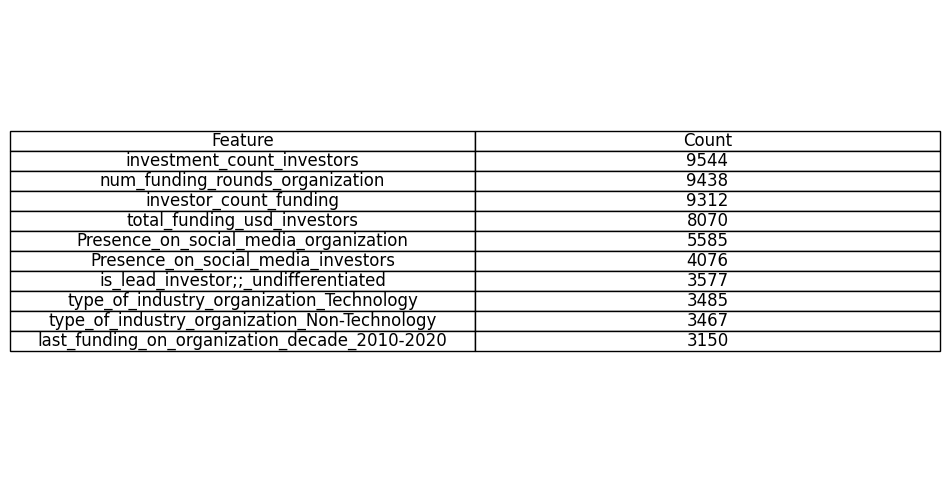

<Figure size 1500x1200 with 0 Axes>

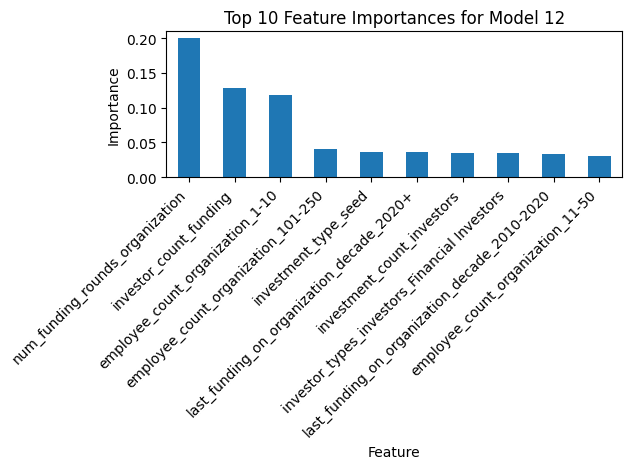

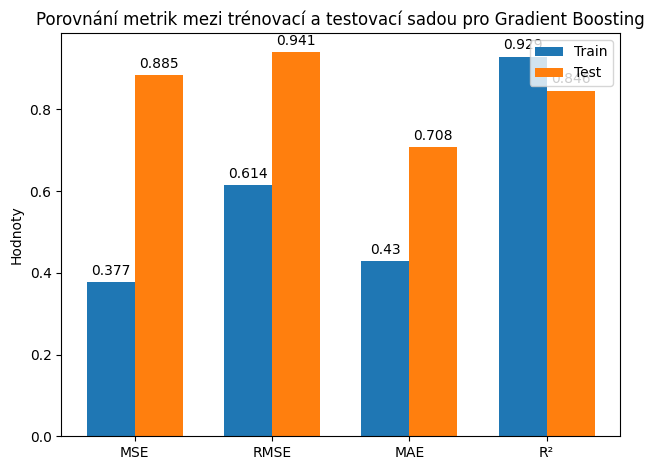

In [201]:
# Function to count how often specific features are used for splits in a decision tree
def count_features_in_tree(tree, feature_names):
    search_keywords = ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]
    count_dict = {key: 0 for key in search_keywords}
    feature_count = {}
    for node in range(tree.node_count):
        # Non-leaf nodes are examined to extract split features
        if tree.children_left[node] != tree.children_right[node]:
            feature = feature_names[tree.feature[node]]
            if feature in feature_count:
                feature_count[feature] += 1
            else:
                feature_count[feature] = 1
            for key in search_keywords:
                if key in feature:
                    count_dict[key] += 1
    return feature_count, count_dict

# Defining parameters for Gradient Boosting Regressor (Model 9)
params_gbr9 = {
    'n_estimators': 600,
    'learning_rate': 0.04,
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'log2',
    'random_state': 42
}

# Training the Gradient Boosting Regressor (Model 9)
model9 = GradientBoostingRegressor(**params_gbr9).fit(X_train, y_train)

# Generating predictions for training and test sets
y_train_pred9 = model9.predict(X_train)
y_test_pred9 = model9.predict(X_test)

# Calculating performance metrics on the training set
mse_train9 = mean_squared_error(y_train, y_train_pred9)
rmse_train9 = np.sqrt(mse_train9)
mae_train9 = mean_absolute_error(y_train, y_train_pred9)
r2_train9 = r2_score(y_train, y_train_pred9)

# Rounding metrics for cleaner output
mse_train9_rounded = round(mse_train9, 3)
rmse_train9_rounded = round(rmse_train9, 3)
mae_train9_rounded = round(mae_train9, 3)
r2_train9_rounded = round(r2_train9, 3)

# Calculating performance metrics on the test set
mse_test9 = mean_squared_error(y_test, y_test_pred9)
rmse_test9 = np.sqrt(mse_test9)
mae_test9 = mean_absolute_error(y_test, y_test_pred9)
r2_test9 = r2_score(y_test, y_test_pred9)

# Rounding metrics for clearer presentation
mse_test9_rounded = round(mse_test9, 3)
rmse_test9_rounded = round(rmse_test9, 3)
mae_test9_rounded = round(mae_test9, 3)
r2_test9_rounded = round(r2_test9, 3)

# Compiling model performance results
results9 = {
    'Model': 'Gradient Boosting Regressor Model 9',
    'Params': params_gbr9,
    'MSE Train': mse_train9_rounded,
    'RMSE Train': rmse_train9_rounded,
    'MAE Train': mae_train9_rounded,
    'R2 Train': r2_train9_rounded,
    'MSE Test': mse_test9_rounded,
    'RMSE Test': rmse_test9_rounded,
    'MAE Test': mae_test9_rounded,
    'R2 Test': r2_test9_rounded
}

# Printing the evaluation results for Model 9
print("Results for Model 9:")
print(results9)

# Extracting feature importances from Model 9
feature_importances9 = model9.feature_importances_

# Counting occurrences of search keywords and all features across trees in the ensemble
feature_count9 = {}
count_dict9 = {key: 0 for key in ["region", "city", "state", "country", "employee", "num_funding_rounds", "investor_count"]}
for estimator in model9.estimators_:
    for tree in estimator:
        tree_feature_count, tree_count_dict = count_features_in_tree(tree.tree_, X.columns)
        for feature, count in tree_feature_count.items():
            if feature in feature_count9:
                feature_count9[feature] += count
            else:
                feature_count9[feature] = count
        for key, count in tree_count_dict.items():
            count_dict9[key] += count

# Creating a DataFrame summarizing counts for search keywords
search_features_df9 = pd.DataFrame([count_dict9], index=['Model 9']).T
search_features_df9.columns = ['Count']

# Displaying the keyword counts in a visual table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=search_features_df9.values,
                 colLabels=search_features_df9.columns,
                 rowLabels=search_features_df9.index,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the table as an image
plt.savefig('search_keywords_count_table_model_9_bezgeo.png', bbox_inches='tight')
plt.show()

# Sorting features by usage frequency to identify most used ones
top_features9 = {k: v for k, v in sorted(feature_count9.items(), key=lambda item: item[1], reverse=True)}

# Creating a DataFrame of the top 10 most frequently used features
top_features_df9 = pd.DataFrame(list(top_features9.items())[:10], columns=['Feature', 'Count'])

# Displaying the top features in a summary table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=top_features_df9.values,
                 colLabels=top_features_df9.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Saving the top features table as an image
plt.savefig('top_features_count_table_model_9_bezgeo.png', bbox_inches='tight')
plt.show()

# Creating a DataFrame pairing features with their importance scores
features_df9 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances9
}).sort_values(by='Importance', ascending=False)

# Plotting the top 10 features based on importance
plt.figure(figsize=(15, 12))
top_features_df9 = features_df9.head(10)
top_features_df9.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Feature Importances for Model 12')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, ha='center')
plt.subplots_adjust(bottom=0.3, top=0.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_feature_importances_model_12_bezgeo.png', bbox_inches='tight')
plt.show()

# Preparing metric data for chart comparison
metrics_train = [mse_train9, rmse_train9, mae_train9, r2_train9]
metrics_test = [mse_test9, rmse_test9, mae_test9, r2_test9]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

x = np.arange(len(labels))  # Position of each metric on the x-axis
width = 0.35  # Width of each bar

# Creating a grouped bar chart comparing training and test metrics
fig, ax = plt.subplots()
rects1 = ax.bar(x - width / 2, metrics_train, width, label='Train')
rects2 = ax.bar(x + width / 2, metrics_test, width, label='Test')

# Customizing chart labels and layout
ax.set_ylabel('Values')
ax.set_title('Comparison of Metrics Between Training and Test Set for Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Helper function to display numeric values above each bar
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Vertical text offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Annotating bars with values
autolabel(rects1, ax)
autolabel(rects2, ax)

# Final layout adjustments and image export
fig.tight_layout()
plt.savefig('GBR_9_METRICS_bezgeo.png', bbox_inches='tight')
plt.show()


In [202]:
# Total number of leaf nodes in all trees Gradient Boosting (regression)
total_leaf_nodes = 0

# Iteration through individual trees
for tree in model9.estimators_:
    # Each tree is a one-dimensional array, taking the first element (there is one output for regression)
    total_leaf_nodes += tree[0].tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: 152803


In [203]:
# Defining geographical variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]

# Tracking root nodes and all nodes
root_features = []
all_features = []

for tree in model9.estimators_[:, 0]:  # For each tree (first tree for each iteration)
    tree_features = tree.tree_.feature
    for feature_index in tree_features:
        if feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
            all_features.append(X_train.columns[feature_index])
    root_feature_index = tree.tree_.feature[0]  # Root node feature index
    if root_feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
        root_features.append(X_train.columns[root_feature_index])

# Counting occurrences of root nodes
root_feature_counts = Counter(root_features)

# Counting occurrences of all nodes
all_feature_counts = Counter(all_features)

# Calculating total numbers
total_root_nodes = len(root_features)
total_geo_root_nodes = sum(1 for feature in root_features if feature in geo_features)

total_nodes = len(all_features)
total_geo_nodes = sum(1 for feature in all_features if feature in geo_features)

# Counting how many of the root or all nodes contain 'city' or 'country_code'
geo_city_nodes = sum(1 for feature in all_features if 'city' in feature.lower())
geo_country_code_nodes = sum(1 for feature in all_features if 'country_code' in feature.lower())

geo_city_root_nodes = sum(1 for feature in root_features if 'city' in feature.lower())
geo_country_code_root_nodes = sum(1 for feature in root_features if 'country_code' in feature.lower())

# Extracting the top 20 most common root nodes
top_20_root_features = root_feature_counts.most_common(20)

# Creating DataFrames for better visualization
top_20_root_features_df = pd.DataFrame(top_20_root_features, columns=['Feature', 'Count'])

# Displaying results
print("Top 20 most common root nodes:")
print(top_20_root_features_df)

print(f"\nTotal number of root nodes: {total_root_nodes}")
print(f"Number of geographical root nodes: {total_geo_root_nodes}")
print(f"Number of root nodes containing 'city': {geo_city_root_nodes}")
print(f"Number of root nodes containing 'country_code': {geo_country_code_root_nodes}")

print(f"\nTotal number of nodes: {total_nodes}")
print(f"Number of geographical nodes: {total_geo_nodes}")
print(f"Number of nodes containing 'city': {geo_city_nodes}")
print(f"Number of nodes containing 'country_code': {geo_country_code_nodes}")

# Saving the results to CSV
top_20_root_features_df.to_csv('top_20_root_features_with_geo_9.csv', index=False)

# Summary results
summary_results = {
    'Metric': [
        'Total Root Nodes', 
        'Geographical Root Nodes', 
        'Root Nodes Containing "City"', 
        'Root Nodes Containing "Country Code"',
        'Total Nodes', 
        'Geographical Nodes', 
        'Nodes Containing "City"', 
        'Nodes Containing "Country Code"'
    ],
    'Value': [
        total_root_nodes, 
        total_geo_root_nodes, 
        geo_city_root_nodes, 
        geo_country_code_root_nodes,
        total_nodes, 
        total_geo_nodes, 
        geo_city_nodes, 
        geo_country_code_nodes
    ]
}
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('summary_node_analysis_with_city_country_9.csv', index=False)

print("\nSummary results saved to 'summary_node_analysis_with_city_country_9.csv'")


Top 20 most common root nodes:
                                     Feature  Count
0            num_funding_rounds_organization     55
1                     investor_count_funding     51
2                 investment_count_investors     37
3                total_funding_usd_investors     36
4         Presence_on_social_media_investors     32
5      Presence_on_social_media_organization     30
6       employee_count_organization_501-1000     28
7          employee_count_organization_11-50     22
8                   investment_type_series_b     21
9      announced_on_funding_decade_1990-2000     21
10          employee_count_organization_1-10     19
11         founded_on_investors_decade_<1960     17
12                      investment_type_seed     16
13                  investment_type_series_c     15
14       employee_count_organization_251-500     13
15  founded_on_organization_decade_1970-1980     13
16       investment_type_equity_crowdfunding     11
17       is_lead_investor;;_undif

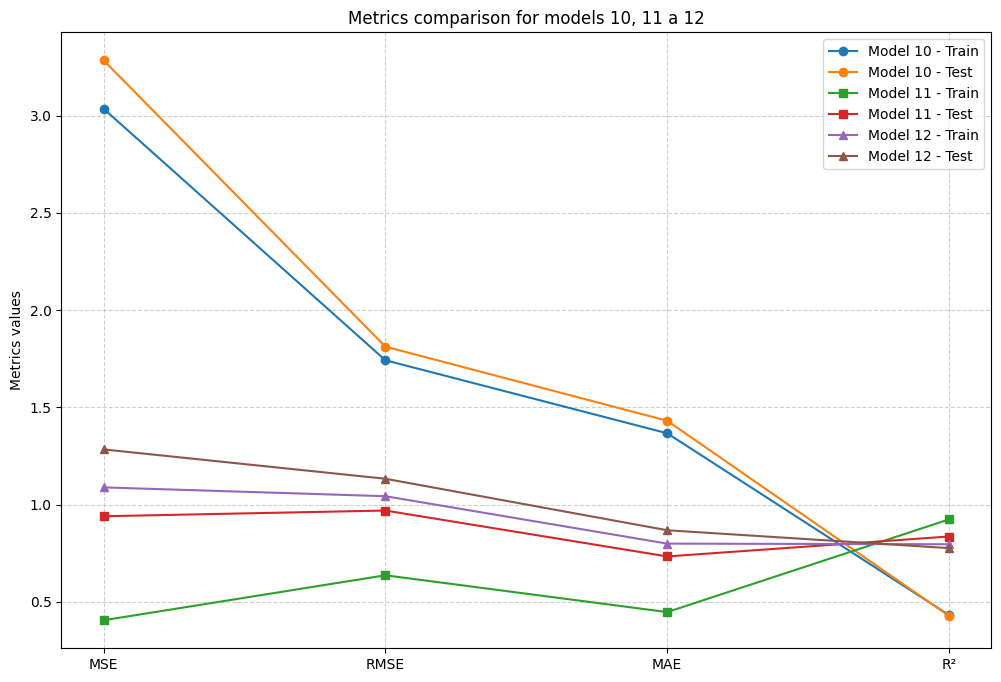

In [204]:


# Defining metrics for each model

metrics_train6 = [mse_train6, rmse_train6, mae_train6, r2_train6]
metrics_test6 = [mse_test6, rmse_test6, mae_test6, r2_test6]

metrics_train7 = [mse_train7, rmse_train7, mae_train7, r2_train7]
metrics_test7 = [mse_test7, rmse_test7, mae_test7, r2_test7]

metrics_train9 = [mse_train9, rmse_train9, mae_train9, r2_train9]
metrics_test9 = [mse_test9, rmse_test9, mae_test9, r2_test9]



# Metrics labels
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# X-axis for each metrics
x = np.arange(len(labels))

plt.figure(figsize=(12, 8))

# Line plot for each model
plt.plot(x, metrics_train6, marker='o', label='Model 10 - Train')
plt.plot(x, metrics_test6, marker='o', label='Model 10 - Test')

plt.plot(x, metrics_train7, marker='s', label='Model 11 - Train')
plt.plot(x, metrics_test7, marker='s', label='Model 11 - Test')

plt.plot(x, metrics_train8, marker='^', label='Model 12 - Train')
plt.plot(x, metrics_test8, marker='^', label='Model 12 - Test')

# Setting
plt.xticks(x, labels)
plt.ylabel('Metrics values')
plt.title('Metrics comparison for models 10, 11 a 12')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot saved
plt.savefig('metrics_comparison_models_gbr.png', bbox_inches='tight')
plt.show()


In [205]:
# Defining evaluation metrics for each model (training and test sets)
metrics_train_gbr = [mse_train, rmse_train, mae_train, r2_train]
metrics_test_gbr = [mse_test, rmse_test, mae_test, r2_test]

metrics_train6 = [mse_train6, rmse_train6, mae_train6, r2_train6]
metrics_test6 = [mse_test6, rmse_test6, mae_test6, r2_test6]

metrics_train7 = [mse_train7, rmse_train7, mae_train7, r2_train7]
metrics_test7 = [mse_test7, rmse_test7, mae_test7, r2_test7]

metrics_train9 = [mse_train9, rmse_train9, mae_train9, r2_train9]
metrics_test9 = [mse_test9, rmse_test9, mae_test9, r2_test9]

# Labels corresponding to the metrics being evaluated
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# Constructing a DataFrame that compares metrics across multiple models
metrics_data = {
    'Metric': labels,
    'Model 7 - Train': metrics_train_gbr,
    'Model 7 - Test': metrics_test_gbr,
    'Model 8 - Train': metrics_train6,
    'Model 8 - Test': metrics_test6,
    'Model 9 - Train': metrics_train7,
    'Model 9 - Test': metrics_test7,
    'Model 10 - Train': metrics_train9,
    'Model 10 - Test': metrics_test9,
}

metrics_df = pd.DataFrame(metrics_data)

# Displaying the comparison table in the console
print("\nMetrics comparison table:")
print(metrics_df)

# Saving the comparison table to an Excel file for later reference
metrics_df.to_excel('metrics_comparison_models_gbr_table.xlsx', index=False)


Metrics comparison table:
  Metric  Model 7 - Train  Model 7 - Test  Model 8 - Train  Model 8 - Test  \
0    MSE             0.98            1.06             3.04            3.28   
1   RMSE             0.99            1.03             1.74            1.81   
2    MAE             0.76            0.79             1.37            1.43   
3     R²             0.82            0.82             0.43            0.43   

   Model 9 - Train  Model 9 - Test  Model 10 - Train  Model 10 - Test  
0             0.41            0.94              0.38             0.88  
1             0.64            0.97              0.61             0.94  
2             0.45            0.73              0.43             0.71  
3             0.92            0.84              0.93             0.85  


GRID SEARCH

In [206]:
# Hyperparameter grid for GradientBoostingRegressor
param_distributions = {
    'n_estimators': [100, 300, 500, 600], 
    'learning_rate': [0.01, 0.1, 0.2,0.04],  
    'max_depth': [3, 5, 7,10], 
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'],  
}

# Initialization the GradientBoostingRegressor
gbr_regressor = GradientBoostingRegressor(random_state=42)

# Initialization the RandomizedSearchCV object
gbr_random_search = RandomizedSearchCV(estimator=gbr_regressor, param_distributions=param_distributions,
                                       n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1,
                                       scoring='neg_mean_squared_error')

# Fitting the RandomizedSearchCV object to the training data
gbr_random_search.fit(X_train, y_train)

# Best parameters and estimator
best_params = gbr_random_search.best_params_
best_estimator = gbr_random_search.best_estimator_

# Validation on the test set
predictions = best_estimator.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"The best parameters are {best_params} with a mean squared error of {mse}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
The best parameters are {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'learning_rate': 0.04} with a mean squared error of 0.8836407388805344


Gradient Boosting basics algorithm optimized

In [207]:
# Creating the gradient boosting regressor object
gbr = GradientBoostingRegressor(
    n_estimators=600,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    learning_rate=0.04,
    random_state=42
)
# Training the model using the training sets
gbr.fit(X_train, y_train)

# Prediction( train data)
y_train_pred = gbr.predict(X_train)

# Metrics for train data
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_train_rounded = round(mse_train, 3)
rmse_train_rounded = round(rmse_train, 3)
mae_train_rounded = round(mae_train, 3)
r2_train_rounded = round(r2_train, 3)

# Printing the metrics results
print(f'Train MSE: {mse_train_rounded}')
print(f'Train RMSE: {rmse_train_rounded}')
print(f'Train MAE: {mae_train_rounded}')
print(f'Train R^2: {r2_train_rounded}')

# Making predictions using the testing set
y_pred = gbr.predict(X_test)


mse_test = mean_squared_error(y_test, y_pred)
rmse_test = sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

mse_test_rounded = round(mse_test, 3)
rmse_test_rounded = round(rmse_test, 3)
mae_test_rounded = round(mae_test, 3)
r2_test_rounded = round(r2_test, 3)

# Printing the result for test data
print("\nTestovací sada:")
print(f'Mean Squared Error (MSE): {mse_test_rounded}')
print(f'Root Mean Squared Error (RMSE): {rmse_test_rounded}')
print(f'Mean Absolute Error (MAE): {mae_test_rounded}')
print(f'R-squared (R²): {r2_test_rounded}')




Train MSE: 0.269
Train RMSE: 0.519
Train MAE: 0.338
Train R^2: 0.95

Testovací sada:
Mean Squared Error (MSE): 0.885
Root Mean Squared Error (RMSE): 0.941
Mean Absolute Error (MAE): 0.705
R-squared (R²): 0.846


In [208]:
# Celkový počet listových uzlů ve všech stromech Gradient Boostingu (regrese)
total_leaf_nodes = 0

# Iterace přes jednotlivé stromy
for tree in gbr.estimators_:
    # Každý strom je jednorozměrné pole, vezmeme první prvek (pro regresi je jeden výstup)
    total_leaf_nodes += tree[0].tree_.n_leaves

print(f"Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: {total_leaf_nodes}")


Celkový počet listových uzlů (listových regionů) ve všech stromech Gradient Boostingu: 237921


Top 10 most important features:
                                         Feature  Importance
0                num_funding_rounds_organization        0.30
11              employee_count_organization_1-10        0.17
3                         investor_count_funding        0.14
15             employee_count_organization_11-50        0.13
46                          investment_type_seed        0.03
35  investor_types_investors_Financial Investors        0.02
1                     investment_count_investors        0.02
47                      investment_type_series_a        0.02
44                      investment_type_pre_seed        0.02
62     last_funding_on_organization_decade_2020+        0.02


<Figure size 1000x800 with 0 Axes>

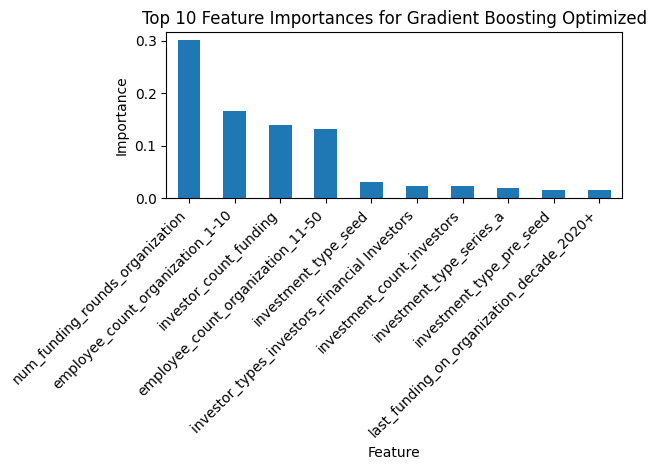

In [209]:
# Creating a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sorting features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Displaying the top 10 most important features
top_features = features_df.head(10)
print("Top 10 most important features:")
print(top_features)

# Plotting the top 10 significant feature importances (vertical chart)
plt.figure(figsize=(10, 8))
top_features_df = features_df.head(10)
top_features_df.plot(kind='bar', x='Feature', y='Importance', legend=False)  # Change to bar for vertical chart
plt.title('Top 10 Feature Importances for Gradient Boosting Optimized')
plt.ylabel('Importance')  
plt.xlabel('Feature') 
plt.xticks(rotation=45, ha='right')  # Names rotation
plt.tight_layout()
plt.savefig('top_10_feature_importances_gradient_boosting_optimized.png', bbox_inches='tight')
plt.show()


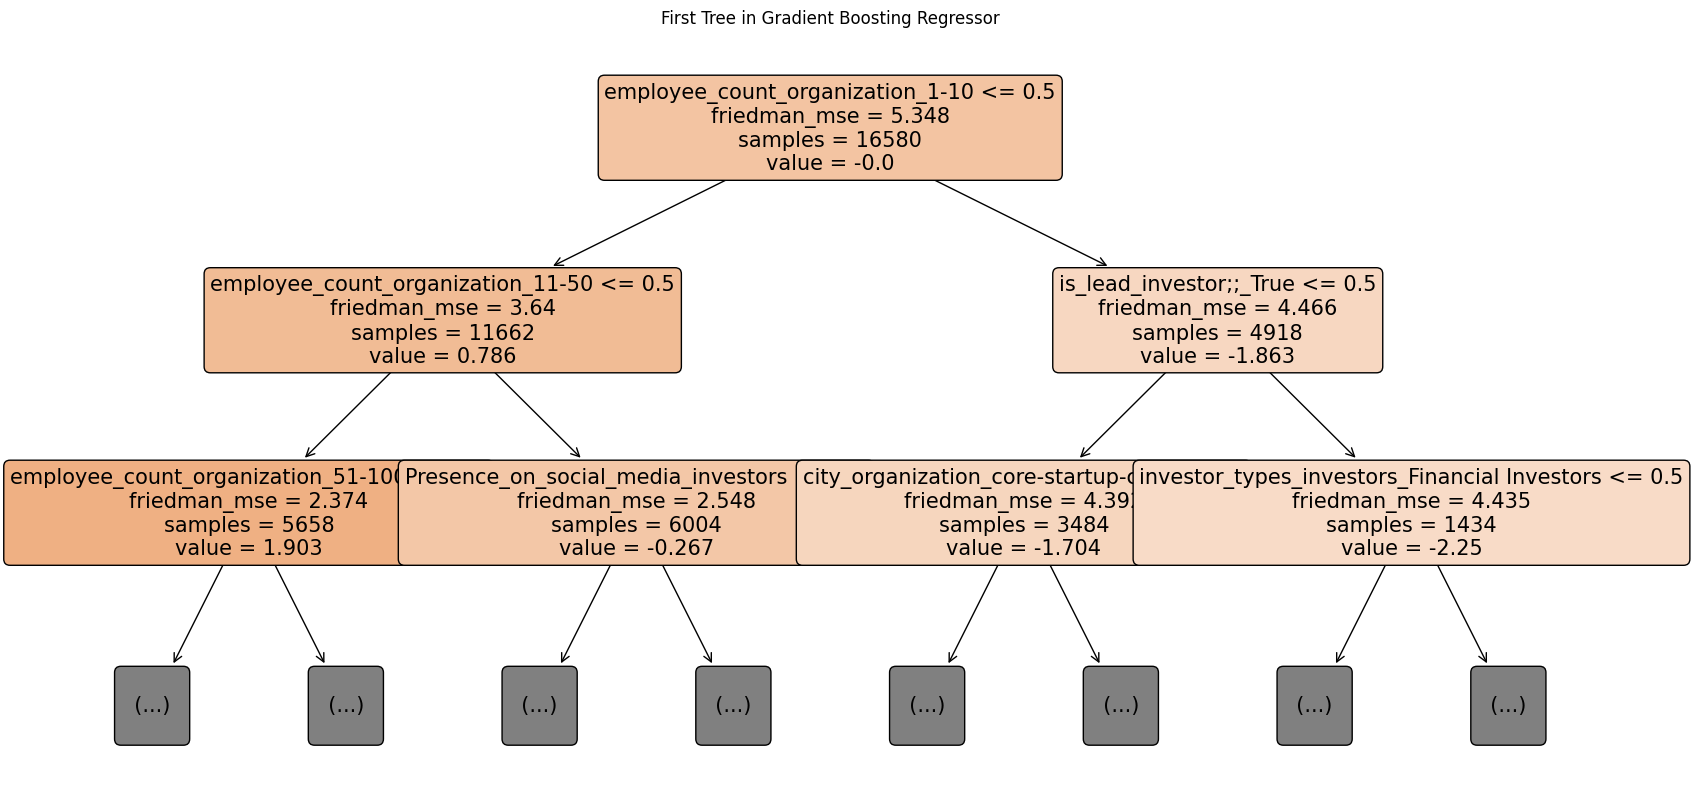

In [210]:
from sklearn import tree
# Extraction of the first tree in the Gradient Boosting Regressor model
first_tree = gbr.estimators_[0, 0]

# Converting X_train.columns to a list for feature names
feature_names_list = list(X_train.columns)

# Plotting the tree with a depth limit of 2
plt.figure(figsize=(20, 10))
tree.plot_tree(
    first_tree,
    feature_names=feature_names_list,
    filled=True,
    rounded=True,
    fontsize=15,
    max_depth=2
)
plt.title('First Tree in Gradient Boosting Regressor')
plt.savefig('gbr_first_tree_opt.png', dpi=300)
plt.show()


In [211]:

# Defining geographical variables
geo_features = [col for col in X_train.columns if 'city' in col.lower() or 'country_code' in col.lower()]

# Tracking root nodes and all nodes
root_features = []
all_features = []

for tree in gbr.estimators_[:, 0]:  # For each tree (first tree for each iteration)
    tree_features = tree.tree_.feature
    for feature_index in tree_features:
        if feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
            all_features.append(X_train.columns[feature_index])
    root_feature_index = tree.tree_.feature[0]  # Root node feature index
    if root_feature_index != -2:  # Ensuring it's a valid feature (not a leaf)
        root_features.append(X_train.columns[root_feature_index])

# Counting occurrences of root nodes
root_feature_counts = Counter(root_features)

# Counting occurrences of all nodes
all_feature_counts = Counter(all_features)

# Calculating total numbers
total_root_nodes = len(root_features)
total_geo_root_nodes = sum(1 for feature in root_features if feature in geo_features)

total_nodes = len(all_features)
total_geo_nodes = sum(1 for feature in all_features if feature in geo_features)

# Counting how many of the root or all nodes contain 'city' or 'country_code'
geo_city_nodes = sum(1 for feature in all_features if 'city' in feature.lower())
geo_country_code_nodes = sum(1 for feature in all_features if 'country_code' in feature.lower())

geo_city_root_nodes = sum(1 for feature in root_features if 'city' in feature.lower())
geo_country_code_root_nodes = sum(1 for feature in root_features if 'country_code' in feature.lower())

# Extracting the top 20 most common root nodes
top_20_root_features = root_feature_counts.most_common(20)

# Creating DataFrames for better visualization
top_20_root_features_df = pd.DataFrame(top_20_root_features, columns=['Feature', 'Count'])

# Displaying results
print("Top 20 most common root nodes:")
print(top_20_root_features_df)

print(f"\nTotal number of root nodes: {total_root_nodes}")
print(f"Number of geographical root nodes: {total_geo_root_nodes}")
print(f"Number of root nodes containing 'city': {geo_city_root_nodes}")
print(f"Number of root nodes containing 'country_code': {geo_country_code_root_nodes}")

print(f"\nTotal number of nodes: {total_nodes}")
print(f"Number of geographical nodes: {total_geo_nodes}")
print(f"Number of nodes containing 'city': {geo_city_nodes}")
print(f"Number of nodes containing 'country_code': {geo_country_code_nodes}")

# Saving the results to CSV
top_20_root_features_df.to_csv('top_20_root_features_with_geo.csv', index=False)

# Summary results
summary_results = {
    'Metric': [
        'Total Root Nodes', 
        'Geographical Root Nodes', 
        'Root Nodes Containing "City"', 
        'Root Nodes Containing "Country Code"',
        'Total Nodes', 
        'Geographical Nodes', 
        'Nodes Containing "City"', 
        'Nodes Containing "Country Code"'
    ],
    'Value': [
        total_root_nodes, 
        total_geo_root_nodes, 
        geo_city_root_nodes, 
        geo_country_code_root_nodes,
        total_nodes, 
        total_geo_nodes, 
        geo_city_nodes, 
        geo_country_code_nodes
    ]
}
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('summary_node_analysis_with_city_country.csv', index=False)

print("\nSummary results saved to 'summary_node_analysis_with_city_country.csv'")


Top 20 most common root nodes:
                                          Feature  Count
0                 num_funding_rounds_organization     69
1                          investor_count_funding     62
2                      investment_count_investors     50
3                     total_funding_usd_investors     43
4              Presence_on_social_media_investors     32
5            employee_count_organization_501-1000     23
6                        investment_type_series_c     22
7           Presence_on_social_media_organization     21
8                            investment_type_seed     20
9               employee_count_organization_11-50     20
10          employee_count_organization_1001-5000     18
11               employee_count_organization_1-10     17
12      last_funding_on_organization_decade_2020+     17
13          founded_on_investors_decade_1970-1980     17
14  last_funding_on_organization_decade_2010-2020     15
15                       investment_type_series_b     15


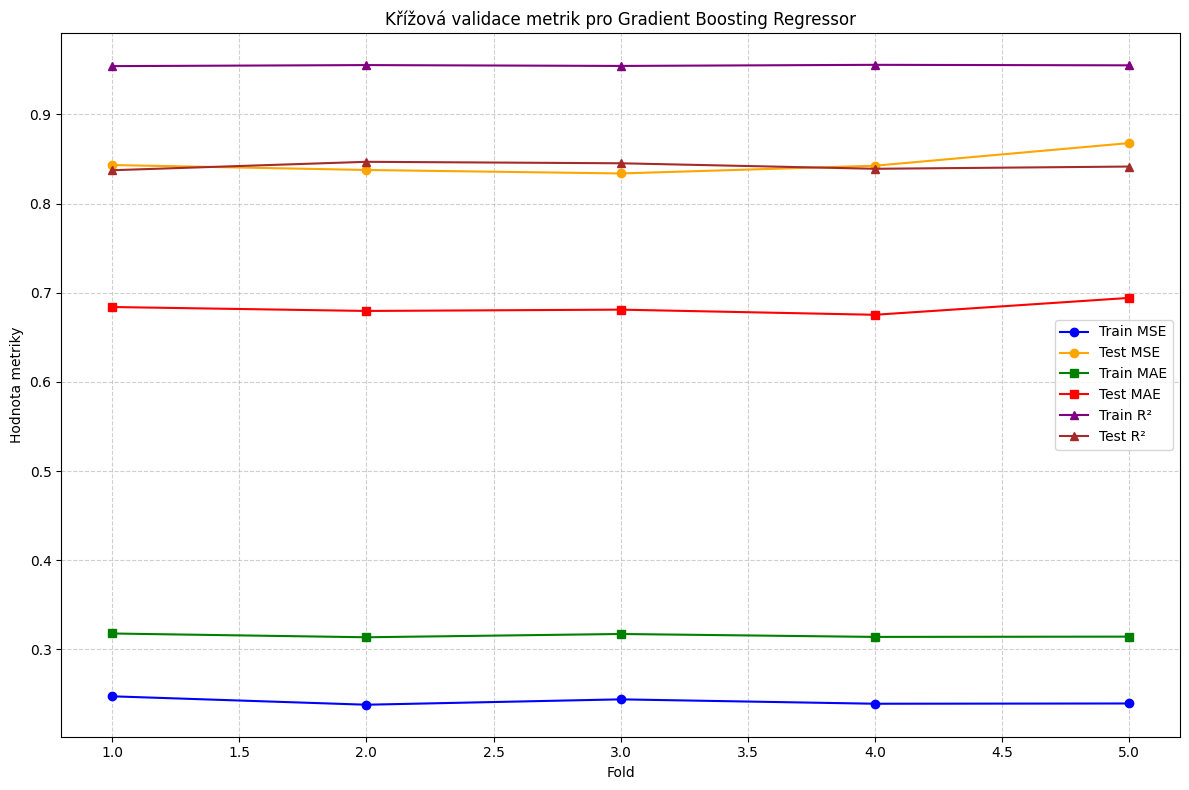

[CV] END learning_rate=0.04, max_depth=7, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.2s
[CV] END learning_rate=0.1, max_depth=7, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=  12.3s
[CV] END learning_rate=0.2, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.0s
[CV] END learning_rate=0.1, max_depth=7, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=  12.8s
[CV] END learning_rate=0.04, max_depth=7, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   4.7s
[CV] END learning_rate=0.01, max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=600; total time=   9.4s
[CV] END learning_rate=0.2

In [212]:
# Defining custom scoring metrics for cross-validation
scoring = {
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

# Performing 5-fold cross-validation on the Gradient Boosting Regressor
cv_results = cross_validate(
    gbr, X_train, y_train, 
    cv=5, scoring=scoring, return_train_score=True, n_jobs=-1
)

# Extracting individual metric values for each fold (negated to get actual MSE/MAE values)
train_mse = -cv_results['train_MSE']
test_mse = -cv_results['test_MSE']

train_mae = -cv_results['train_MAE']
test_mae = -cv_results['test_MAE']

train_r2 = cv_results['train_R2']
test_r2 = cv_results['test_R2']

# Creating a line plot to visualize metric variation across folds
plt.figure(figsize=(12, 8))

# Line plot for Mean Squared Error (MSE)
plt.plot(range(1, 6), train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(range(1, 6), test_mse, marker='o', label='Test MSE', color='orange')

# Line plot for Mean Absolute Error (MAE)
plt.plot(range(1, 6), train_mae, marker='s', label='Train MAE', color='green')
plt.plot(range(1, 6), test_mae, marker='s', label='Test MAE', color='red')

# Line plot for R² score
plt.plot(range(1, 6), train_r2, marker='^', label='Train R²', color='purple')
plt.plot(range(1, 6), test_r2, marker='^', label='Test R²', color='brown')

# Customizing the appearance of the chart
plt.xlabel('Fold')
plt.ylabel('Metric Value')
plt.title('Cross-Validation Metrics for Gradient Boosting Regressor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Saving the plot
plt.savefig('gbr_cross_validation_line_plot.png', bbox_inches='tight', dpi=300)

# Displaying the plot
plt.show()